# Plots
In this notebook we generate the visualizations for our model applied to different regions

In [1]:
# load packages and data
import numpy as np
import pickle
import math
import time
import sys
module_paths = ['']
for path in module_paths :
    if path not in sys.path:
        sys.path.append(path)
from utils_load_PHloc import datasets_of_interest, injected_datasets_of_interest, levels_of_interest
import matplotlib.pyplot as plt
import pomegranate
import sklearn
import torch
from pomegranate.gmm import GeneralMixtureModel
from pomegranate.distributions import *
from joblib import Parallel, delayed
from sklearn.model_selection import KFold
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import pandas as pd 
from sklearn.utils import resample
from utils_load_PHloc import extract_heatmap_grid
from adjustText import adjust_text

PH_folder = '' 
anatomy = 'knee'
filepath = PH_folder + 'PH_all_{}.pkl'.format(anatomy)
PH_all_datasets = pickle.load(open(filepath, 'rb'))

# threshold value
THR = .5
# generate a new dictionary for truncated datasets
truncated_PH_all_datasets = {}
for i in datasets_of_interest:
    diagram = PH_all_datasets[i]
    truncated_PH_all_datasets[i] = diagram[diagram[:,1] >= diagram[:,0] + THR]
    
names = [injected_datasets_of_interest[i]+"_"+[str(x) for x in datasets_of_interest][i] for i in range(27)]

labels = ['CTRL_0%(1)', 'CTRL_0%(2)', 'CTRL_0%(3)', 'CTRL_0%(4)', 
          'U937_1%(1)', 'U937_1%(2)', 'U937_7%', 'U937_8%', 'U937_10%(1)', 'U937_10%(2)', 'U937_10%(3)', 
          'HL60_23%', 'HL60_25%(1)', 'HL60_25%(2)', 
          'P1_10%', 'P1_40%', 'P1_44%', 'P1_51%', 'P1_60%', 'P1_76%', 
          'P2_59%', 'P2_88%', 'P2_90%', 
          'MNC_53%', 'MNC_67%', 'MNC_75%', 'MNC_86%']

phases_of_interest = [0,0,0,0,
         1,1,1,1,1,1,1,
         1,1,1,
         1,2,2,2,2,2,
         2,2,2,
         2,2,2,2]

name_phase = [labels[i]+" [Phase "+str(phases_of_interest[i])+"]" for i in range(27)]

# Binning parameters
XLIMS = np.array([[-15,0],[-10,10],[0,20]])
YLIMS = np.array([[-8,7],[-5,15],[0,20]])
NB_BINS_PER_SIDE = 100

pds = [truncated_PH_all_datasets[i] for i in datasets_of_interest]

[KeOps] Warning : Cuda libraries were not detected on the system ; using cpu only mode


In [2]:
# function that extract quadrant data according to the name
def extract_quadrant(quadrant_name):
    # quadrant names in the form of ph1_ne etc
    # Step 1: get dimension
    dim = int(quadrant_name[2])
    pds_dim = []
    for i in range(27):
        current_pd = pds[i]
        pds_dim.append(current_pd[current_pd[:,2]==dim,:2])
    # Step 2: extract based on orientation
    out_pds = []
    if quadrant_name[4:]=="ne":
        for i in range(27):
            pd = pds_dim[i]
            x = pd[:,0]
            y = pd[:,1]
            out_pds.append(pd[(x>0)*(y>0),:])
    elif quadrant_name[4:]=="sw":
        for i in range(27):
            pd = pds_dim[i]
            x = pd[:,0]
            y = pd[:,1]
            out_pds.append(pd[(x<0)*(y<0),:])
    elif quadrant_name[4:]=="nw":
        for i in range(27):
            pd = pds_dim[i]
            x = pd[:,0]
            y = pd[:,1]
            out_pds.append(pd[(x<0)*(y>0),:])
    return out_pds

# dictionary for number of components for each phase model
num_component_dict = {"ph1_ne":[5,6,6], "ph0_sw":[4,5,5], "ph1_nw":[3,4,5], "ph1_sw":[5,5,7], "ph2_ne":[4,4,5]}

In [3]:
ph1_ne = extract_quadrant("ph1_ne")
ph0_sw = extract_quadrant("ph0_sw")
ph1_nw = extract_quadrant("ph1_nw")
ph1_sw = extract_quadrant("ph1_sw")
ph2_ne = extract_quadrant("ph2_ne")
print(f"Sizes in ph1_ne: {[x.shape[0] for x in ph1_ne]}")
print(f"Sizes in ph0_sw: {[x.shape[0] for x in ph0_sw]}")
print(f"Sizes in ph1_nw: {[x.shape[0] for x in ph1_nw]}")
print(f"Sizes in ph1_sw: {[x.shape[0] for x in ph1_sw]}")
print(f"Sizes in ph2_ne: {[x.shape[0] for x in ph2_ne]}")

Sizes in ph1_ne: [15254, 10529, 14935, 12883, 7483, 10886, 21364, 15168, 20547, 13022, 13257, 12717, 14110, 14010, 16710, 12066, 14356, 11077, 9768, 8800, 12883, 9324, 6573, 11560, 10577, 10170, 11633]
Sizes in ph0_sw: [13940, 9202, 12838, 11514, 6376, 8818, 15368, 11217, 14819, 9920, 11126, 10393, 9837, 9701, 12462, 8955, 10483, 8453, 8210, 6566, 9302, 6448, 5054, 9622, 7535, 7838, 7846]
Sizes in ph1_nw: [12759, 7935, 10387, 10729, 5259, 8473, 14626, 10495, 14366, 7949, 9096, 8775, 8537, 9854, 11567, 6525, 6855, 4629, 5518, 5104, 4595, 3458, 2801, 8762, 3983, 4270, 3905]
Sizes in ph1_sw: [2629, 1490, 2192, 2524, 902, 1924, 2466, 2386, 2765, 1210, 1637, 1730, 1884, 1424, 2747, 1210, 1371, 1176, 1863, 1101, 1327, 959, 700, 1454, 1009, 1418, 714]
Sizes in ph2_ne: [9904, 6305, 8434, 8314, 3781, 6693, 11687, 8731, 11625, 6367, 7215, 7368, 7667, 7846, 9231, 6114, 6475, 4886, 4977, 4441, 5392, 3629, 2899, 6142, 4088, 4794, 4656]


In [4]:

XLIMS = np.array([[-15,0],[-10,10],[0,20]])
YLIMS = np.array([[-8,7],[-5,15],[0,20]])

xlims_dict = {"ph1_ne": [0,10], "ph0_sw":[-15,0], "ph1_nw":[-10,0], "ph1_sw":[-10,0], "ph2_ne":[0,20]}
ylims_dict = {"ph1_ne": [0,15], "ph0_sw":[-8,0], "ph1_nw":[0,15], "ph1_sw":[-5,0], "ph2_ne":[0,20]}

Train models on given data and plot the Gaussian mixtures


In [10]:
def plot_func(quadrant, save=False):
    # extract data and number of clusters information
    data = extract_quadrant(quadrant)
    n_components = num_component_dict[quadrant]
    xlim = xlims_dict[quadrant]
    ylim = ylims_dict[quadrant]
    # filter data by phase 
    phase_data = []
    phase_data.append(np.vstack([data[i] for i in range(len(data)) if phases_of_interest[i]==0]))
    phase_data.append(np.vstack([data[i] for i in range(len(data)) if phases_of_interest[i]==1]))
    phase_data.append(np.vstack([data[i] for i in range(len(data)) if phases_of_interest[i]==2]))
    # fit models
    models = {}
    for p in range(3):
        model = GeneralMixtureModel.from_samples(
            pomegranate.MultivariateGaussianDistribution,
            n_components=n_components[p],
            X=phase_data[p]
        )
        model.fit(
            X=phase_data[p],
            weights=phase_data[p][:,1]-phase_data[p][:,0], 
            stop_threshold=.001,
            verbose=False # Suppress verbose output during fitting
        )
        models[p] = model
        print(f"phase {str(p)} model complete")
        
        # plot the distributions of the GMMs
    
        # contour plot with labels
        x = np.linspace(xlim[0], xlim[1], 100)
        y = np.linspace(ylim[0], ylim[1], 100)
        xx, yy = np.meshgrid(x, y)
        x_ = np.array(list(zip(xx.flatten(), yy.flatten())))
        
        # Contour Plot
        fig, ax = plt.subplots(figsize=(6, 6), dpi = 300)
        model_values = models[p].probability(x_).reshape(len(x), len(y))
        ax.contour(xx, yy, model_values, origin="upper", cmap="Blues", alpha=0.7)
        # Labeling weights and means
        weights = np.exp(models[p].weights)
        texts = [] 
        for i, distribution in enumerate(models[p].distributions):
            weight = weights[i]
            mean = distribution.parameters[0]

            ax.scatter(mean[0], mean[1], marker='x', color='red', s=100, label=f'Mean {i+1}')
            texts.append(ax.text(mean[0] + 0.1, mean[1] + 0.1,
                     f'W: {weight:.2f}\nM: ({mean[0]:.2f}, {mean[1]:.2f})',
                     fontsize=16))
        adjust_text(texts, arrowprops=dict(arrowstyle='-', color='red', lw=0.5)) 
        plt.tight_layout()
        if save:
            plt.savefig(f"R3_new_diagrams/{quadrant}_phase_{str(p)}_model_GMM_wlabel.png")
        plt.show()
        
        # Heat map
        plt.figure(figsize=(6, 6), dpi=300)
        sample = models[p].sample(5000)
        weights = sample[:, 1] - sample[:, 0]
        sample = sample[weights > 0, :]
        weights = weights[weights > 0]

        # Define xlim and ylim for the heatmap based on your provided example
        nb_bins_per_side = 100

        img = extract_heatmap_grid(sample, weights=weights, sigma=0.25,
                                   xlim=xlim, ylim=ylim, nb_bins_per_side=nb_bins_per_side,
                                   option="sklearn")
        plt.imshow(img, extent=[xlim[0], xlim[1], ylim[0], ylim[1]], cmap='magma')
        plt.contour(img, levels=4, extent=[xlim[0], xlim[1], ylim[0], ylim[1]],
                    origin='upper', cmap='inferno_r')
        if save:
            plt.savefig(f"R3_new_diagrams/{quadrant}_phase_{str(p)}_model_GMM_heatmap_new_labels_new_number_clusters.png")
        plt.show()

phase 0 model complete


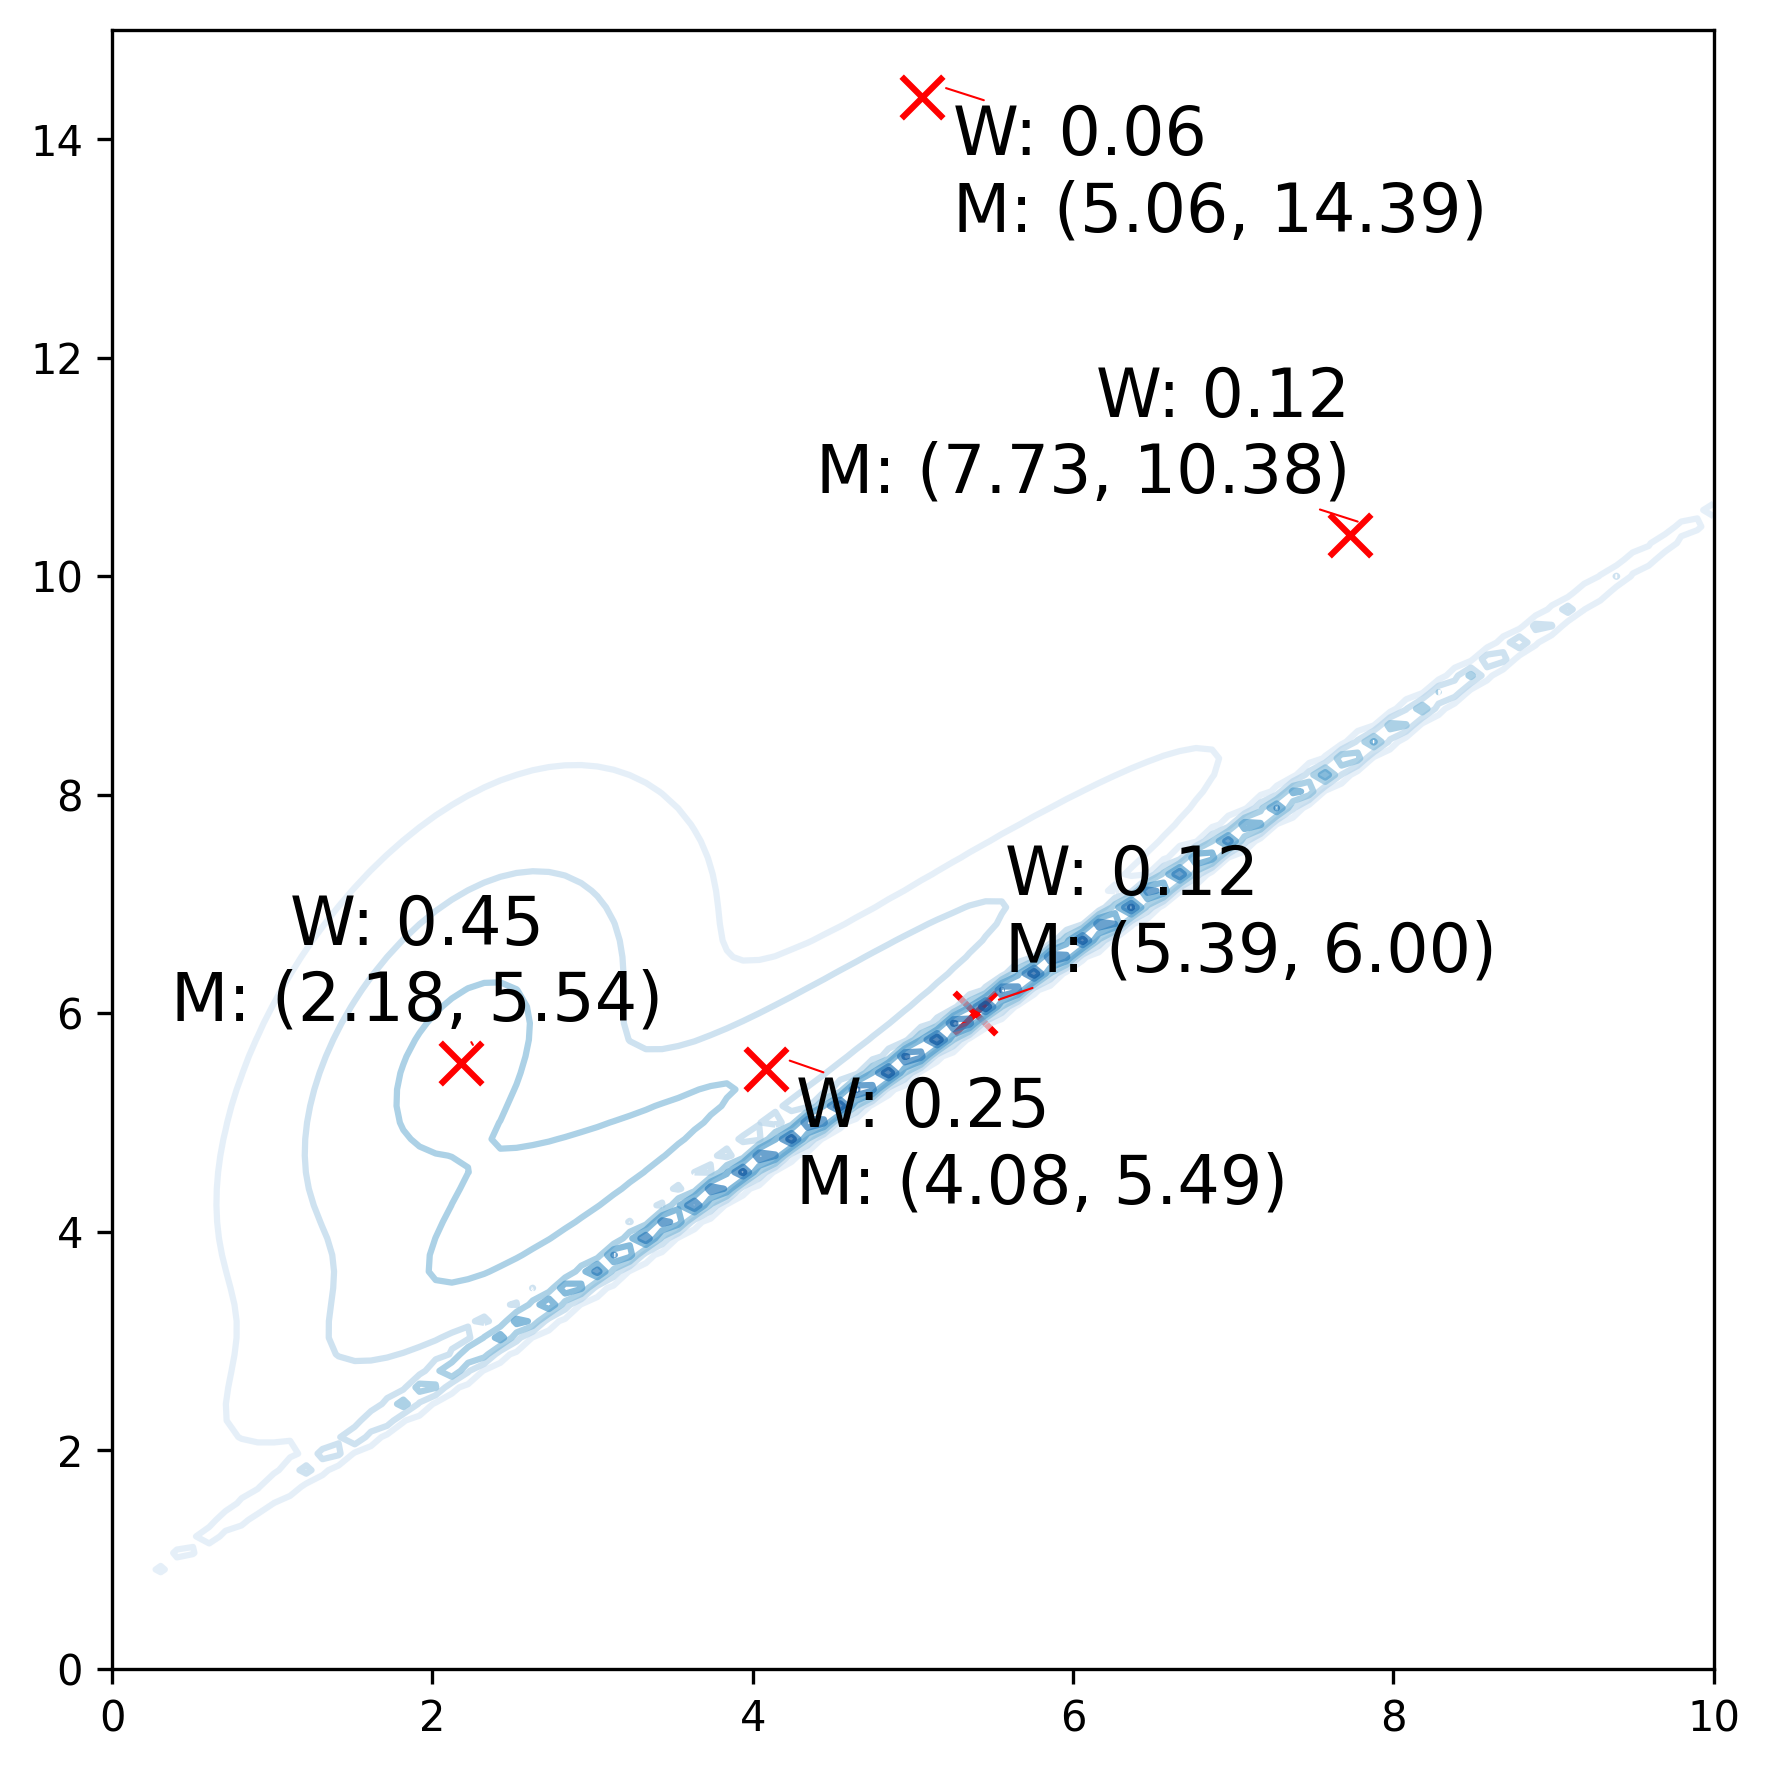

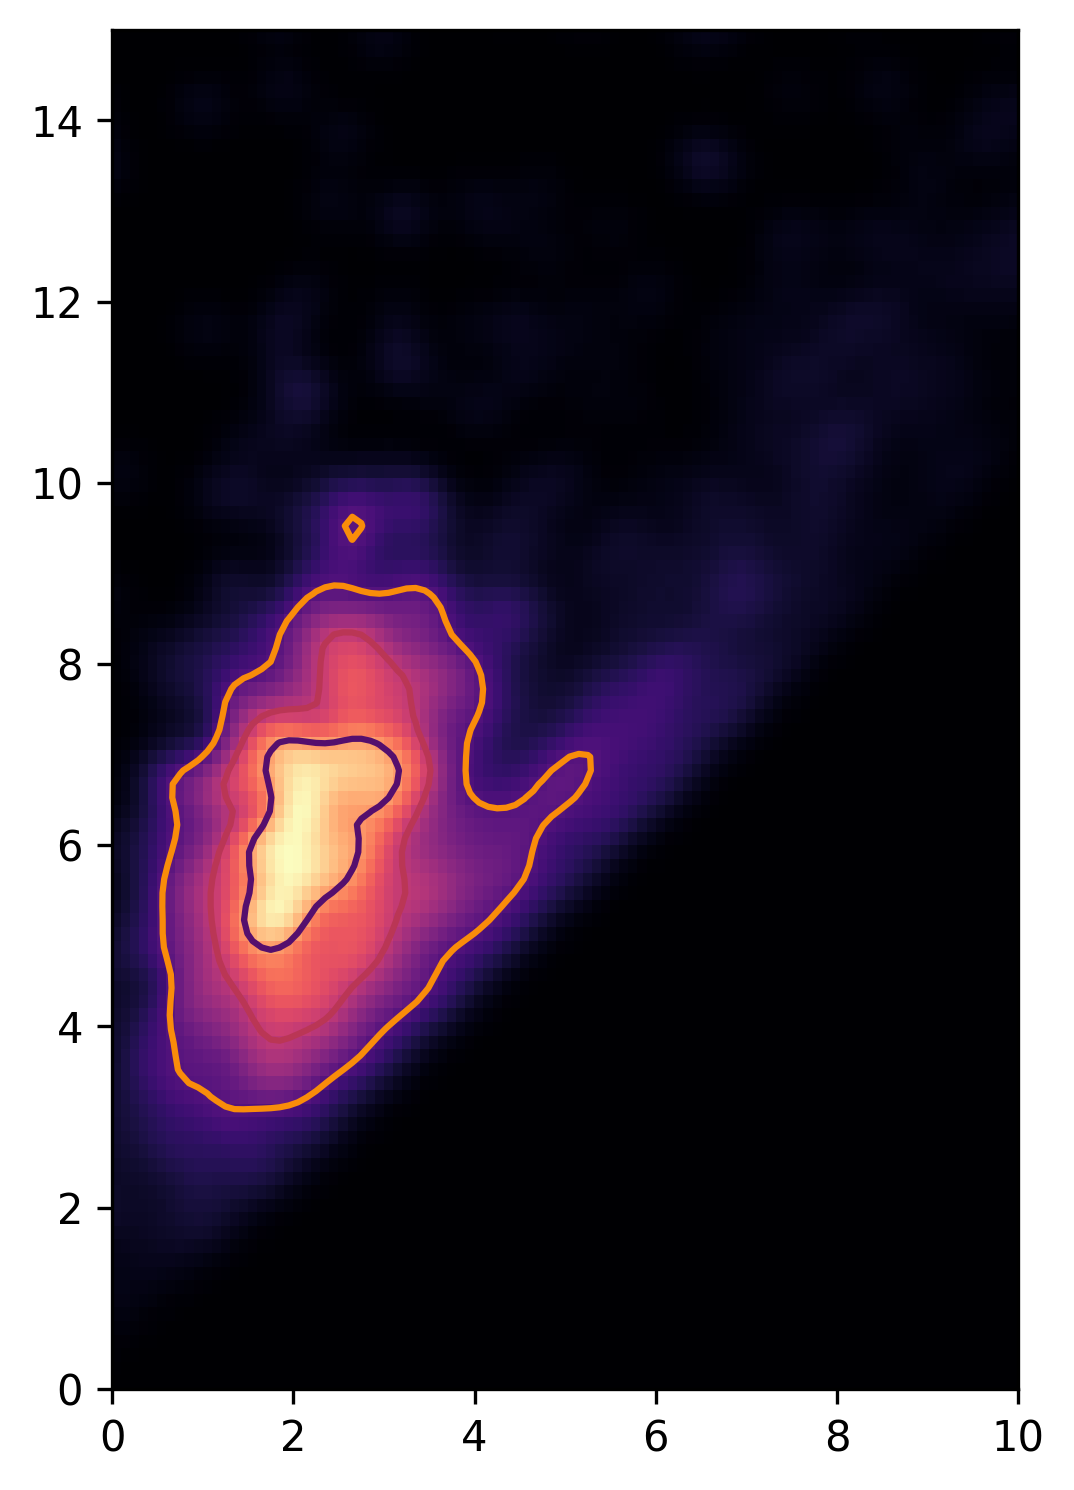

phase 1 model complete


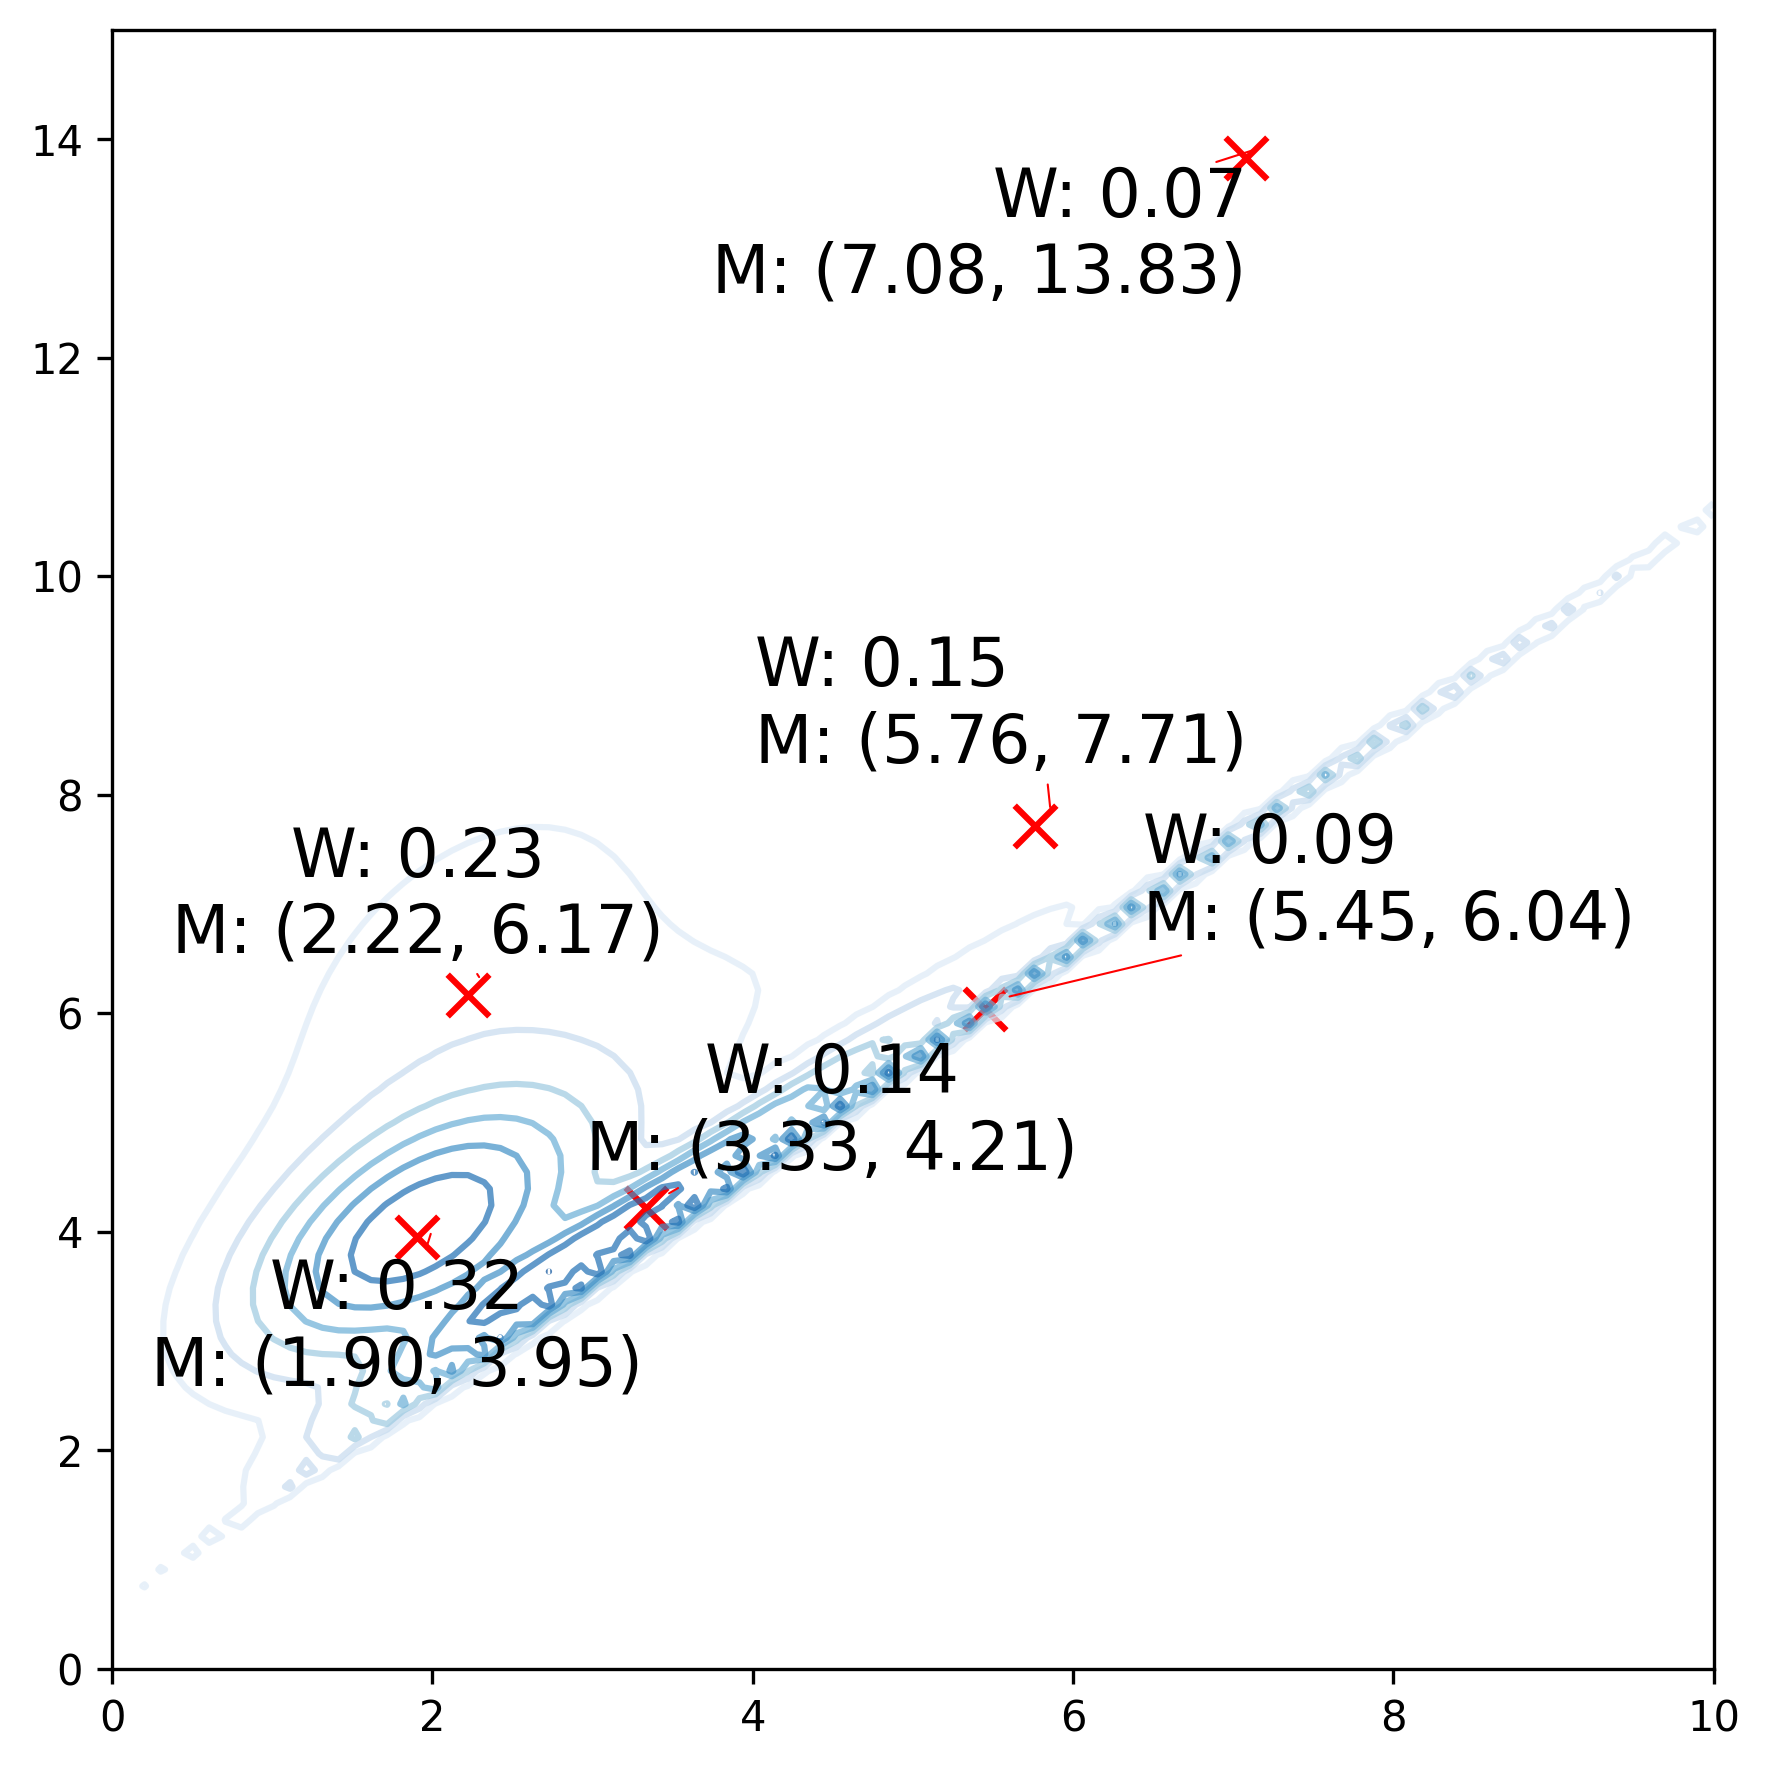

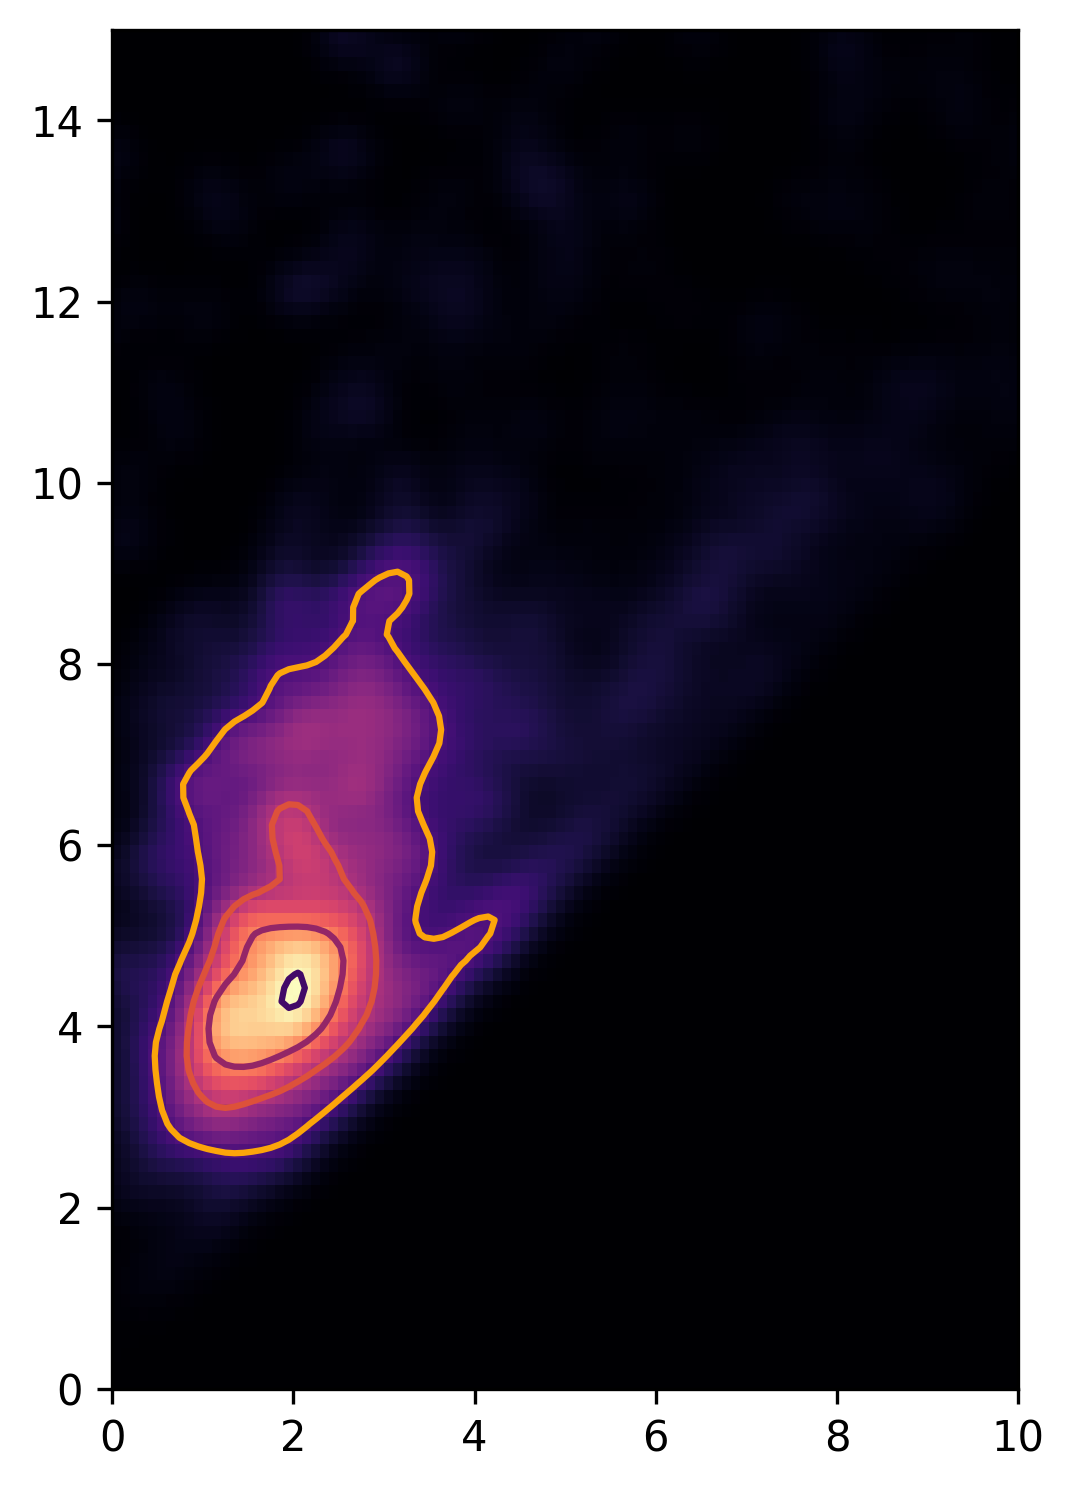

phase 2 model complete


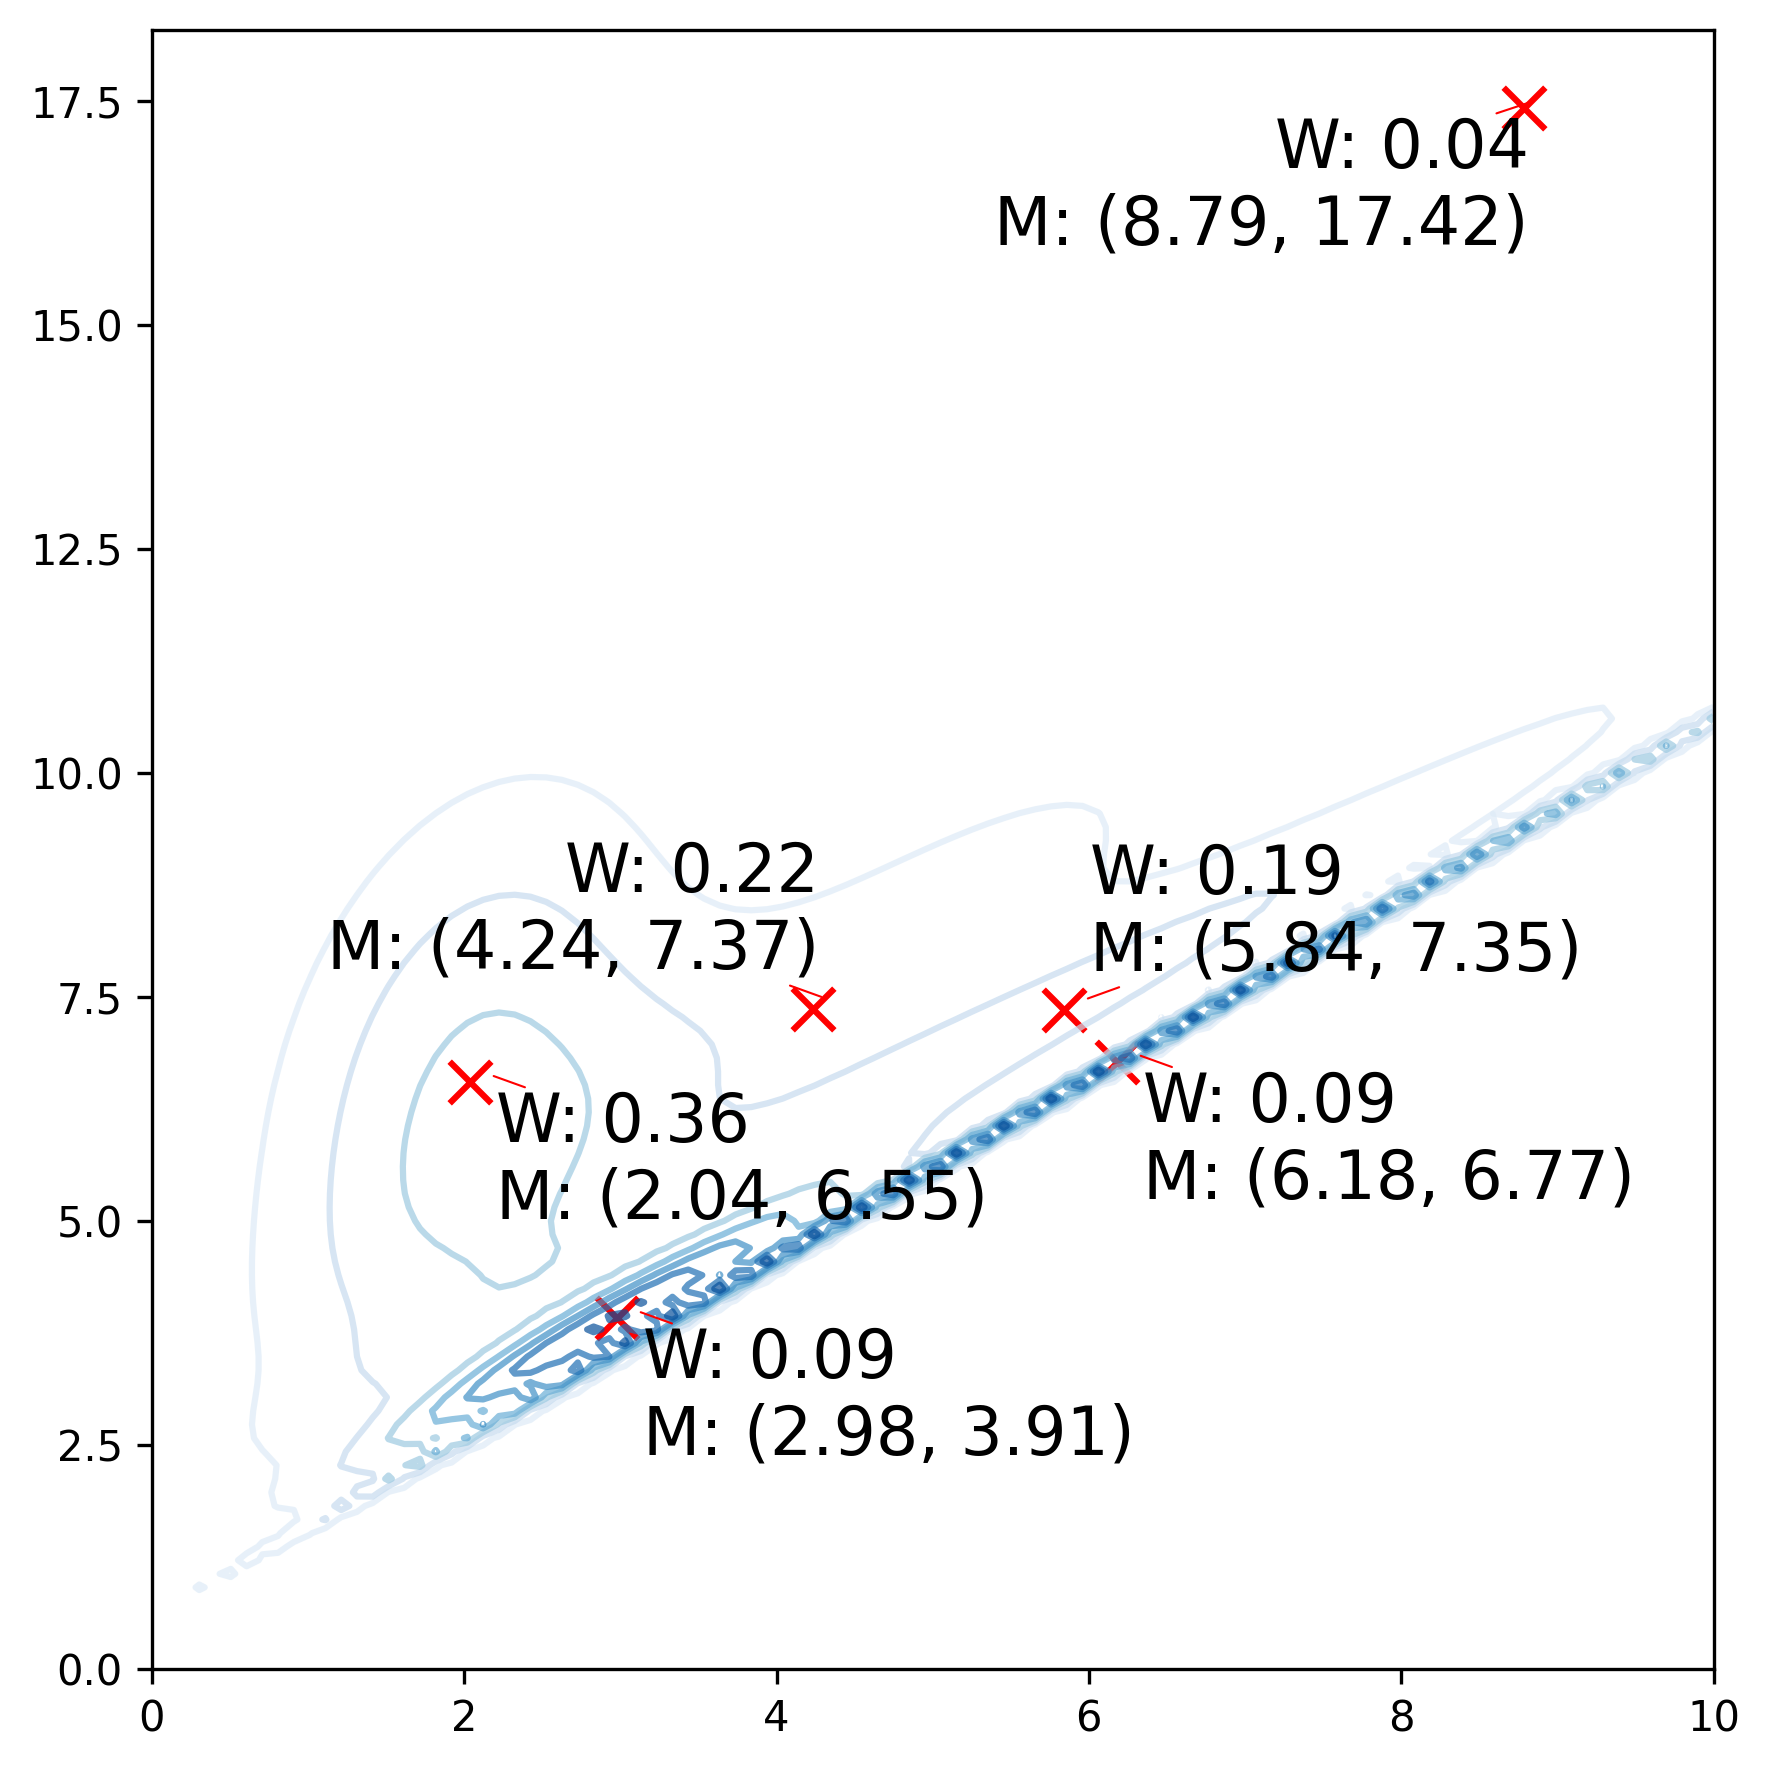

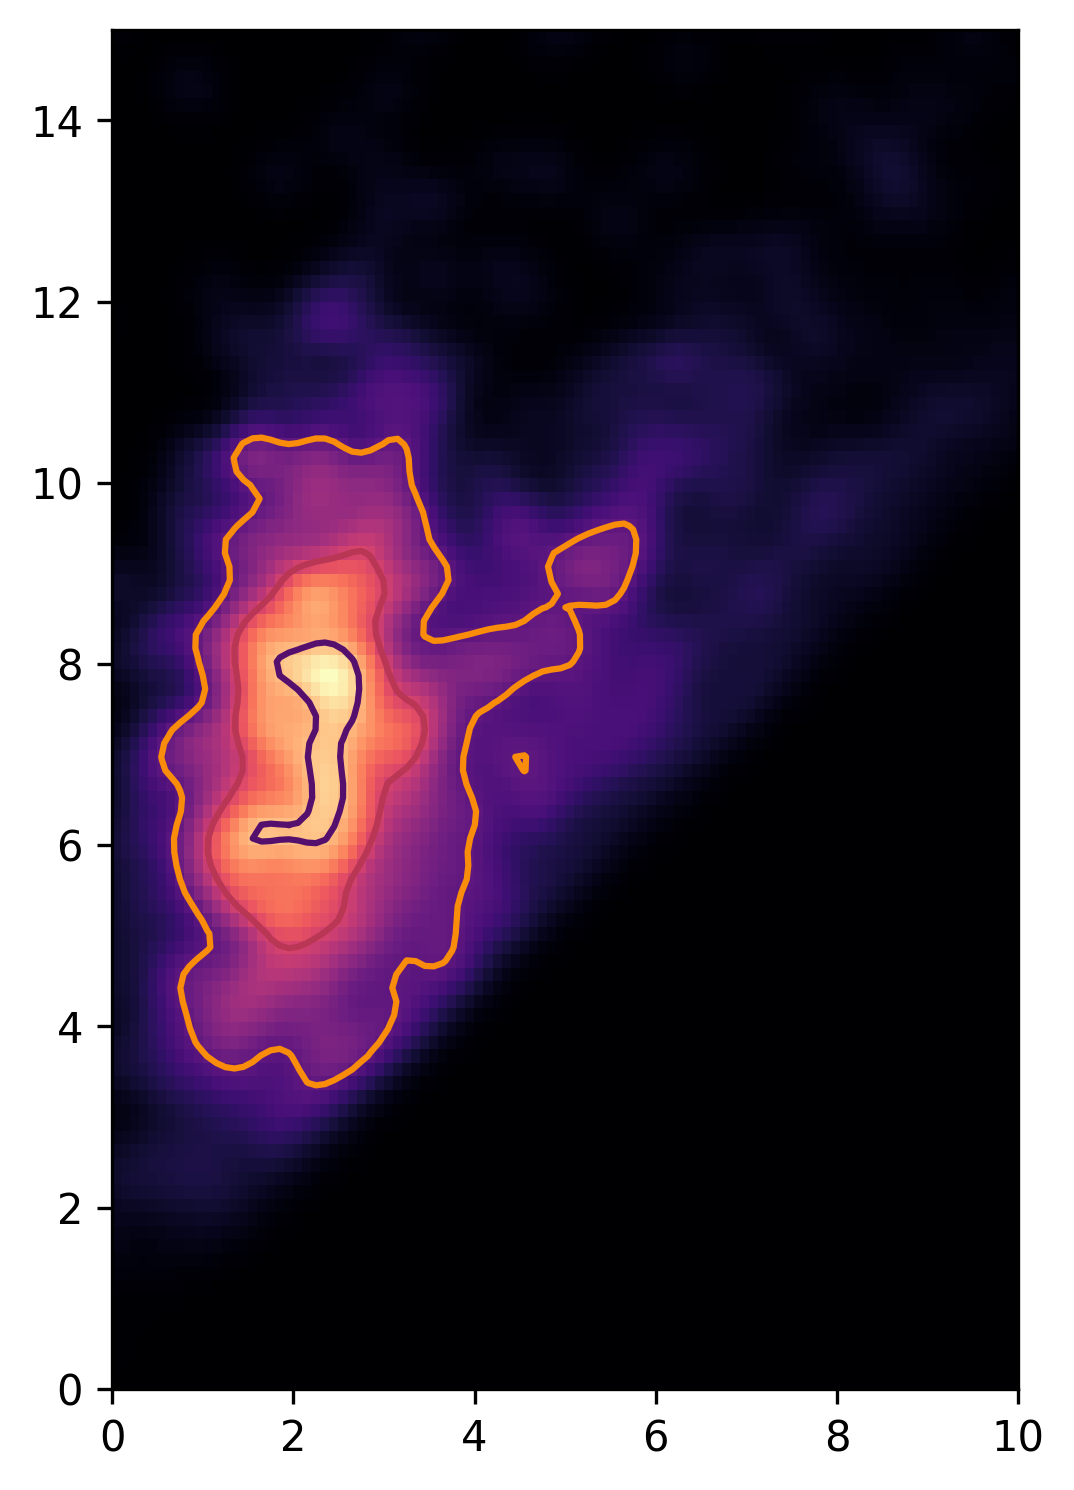

In [11]:
plot_func("ph1_ne", save=True)

phase 0 model complete


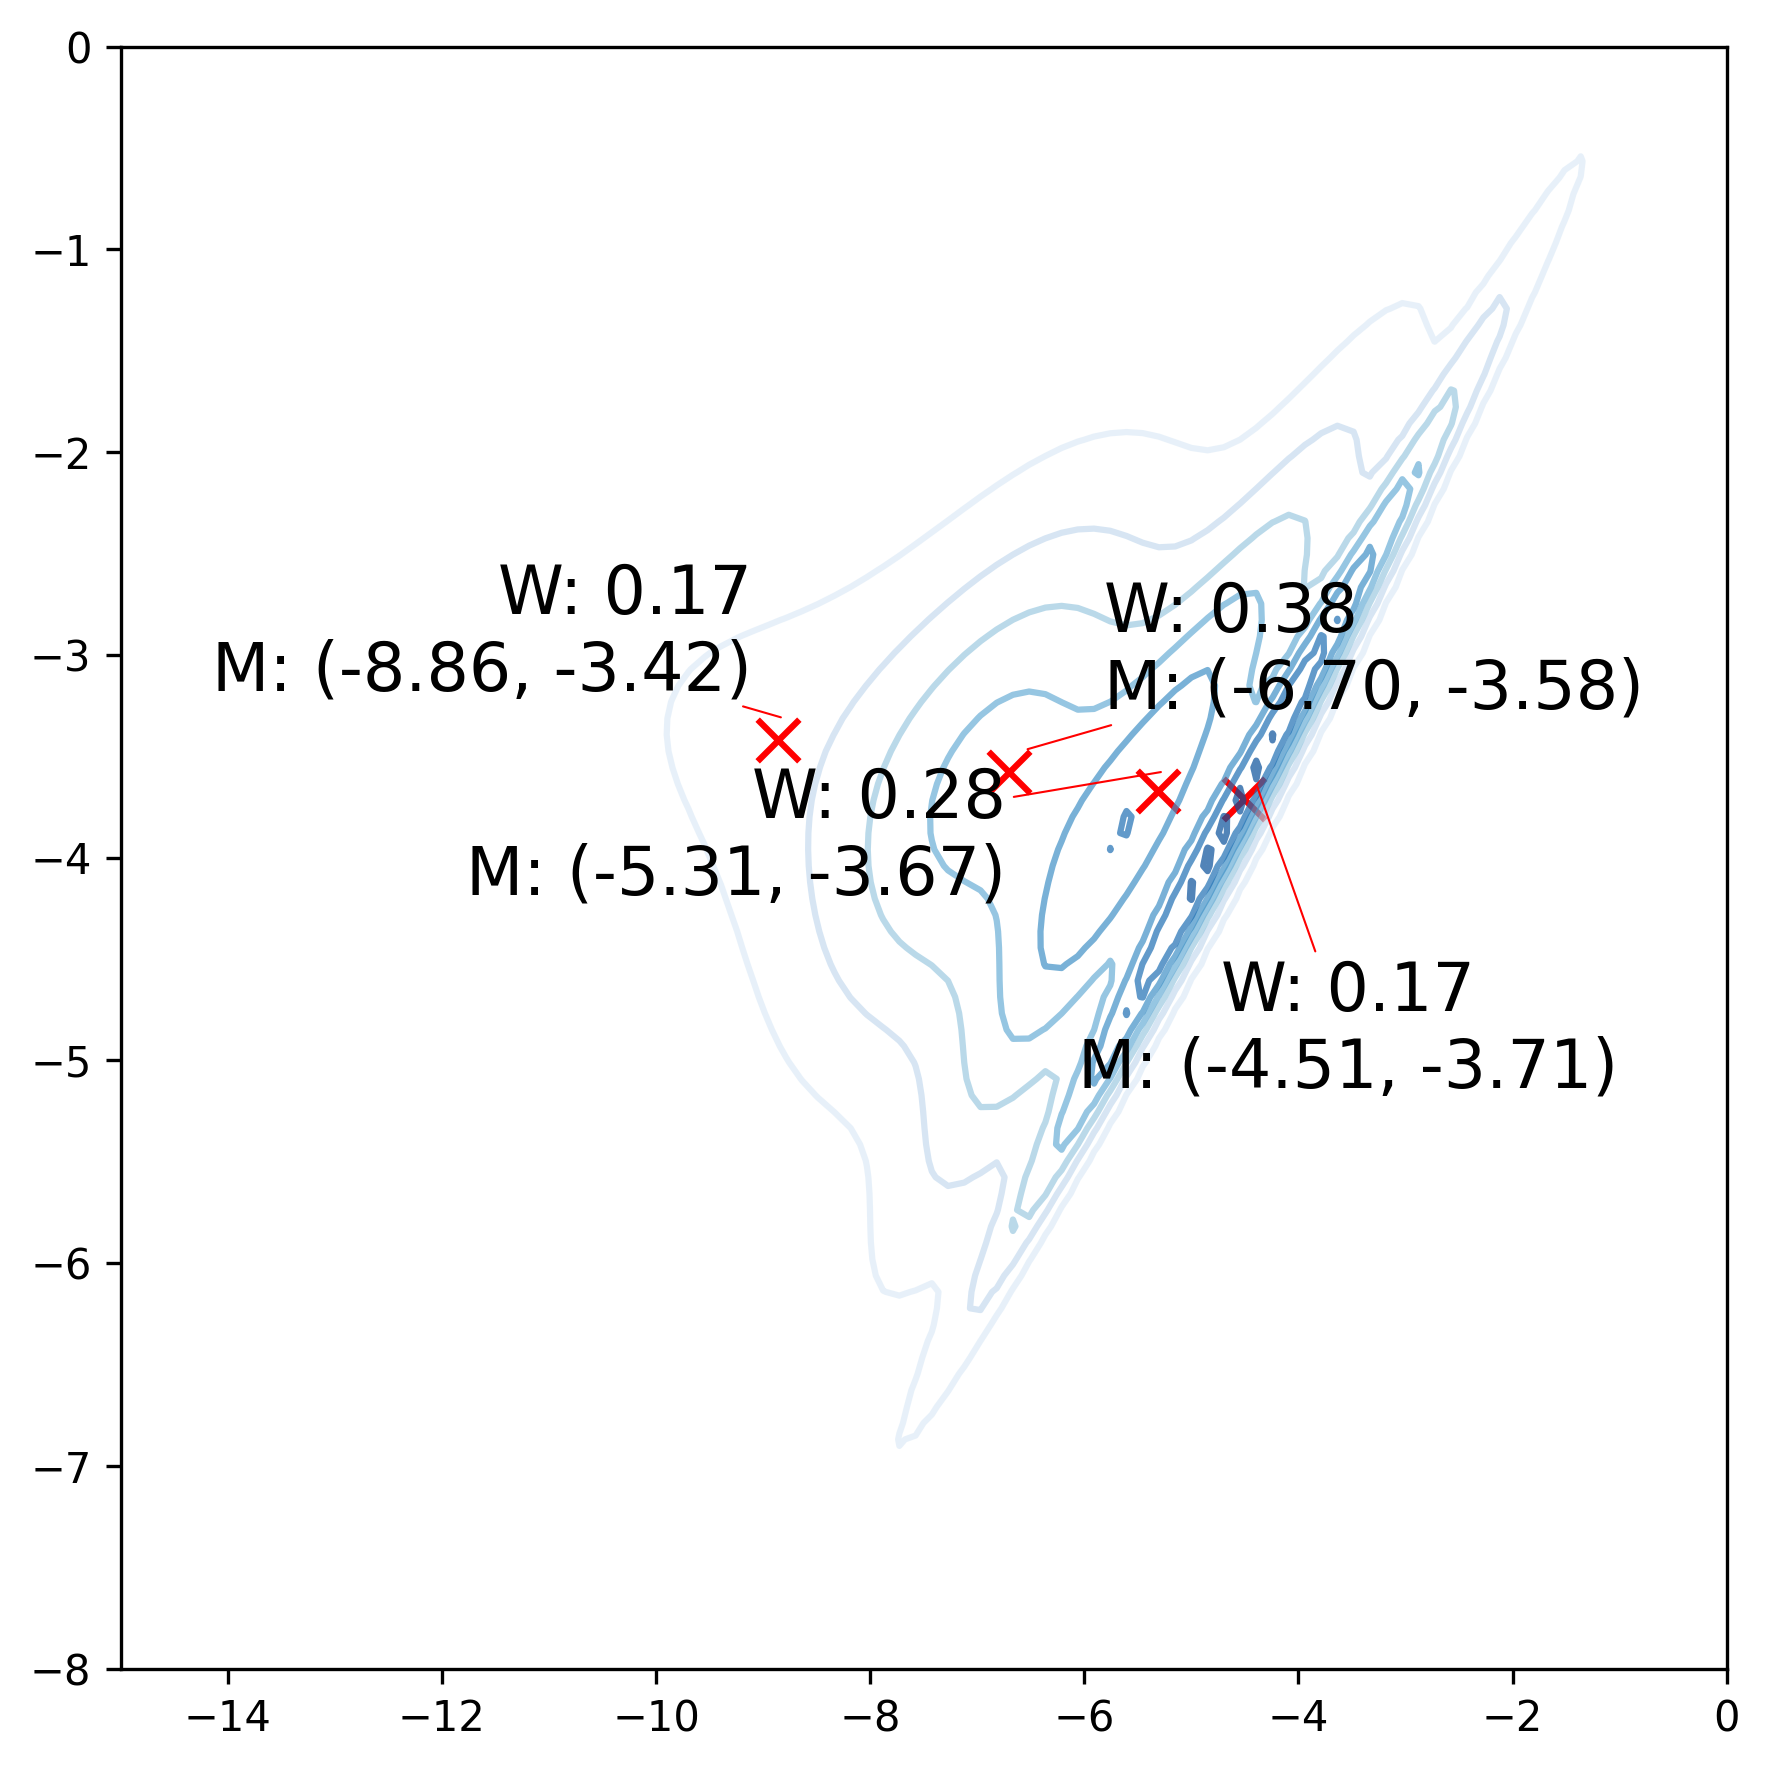

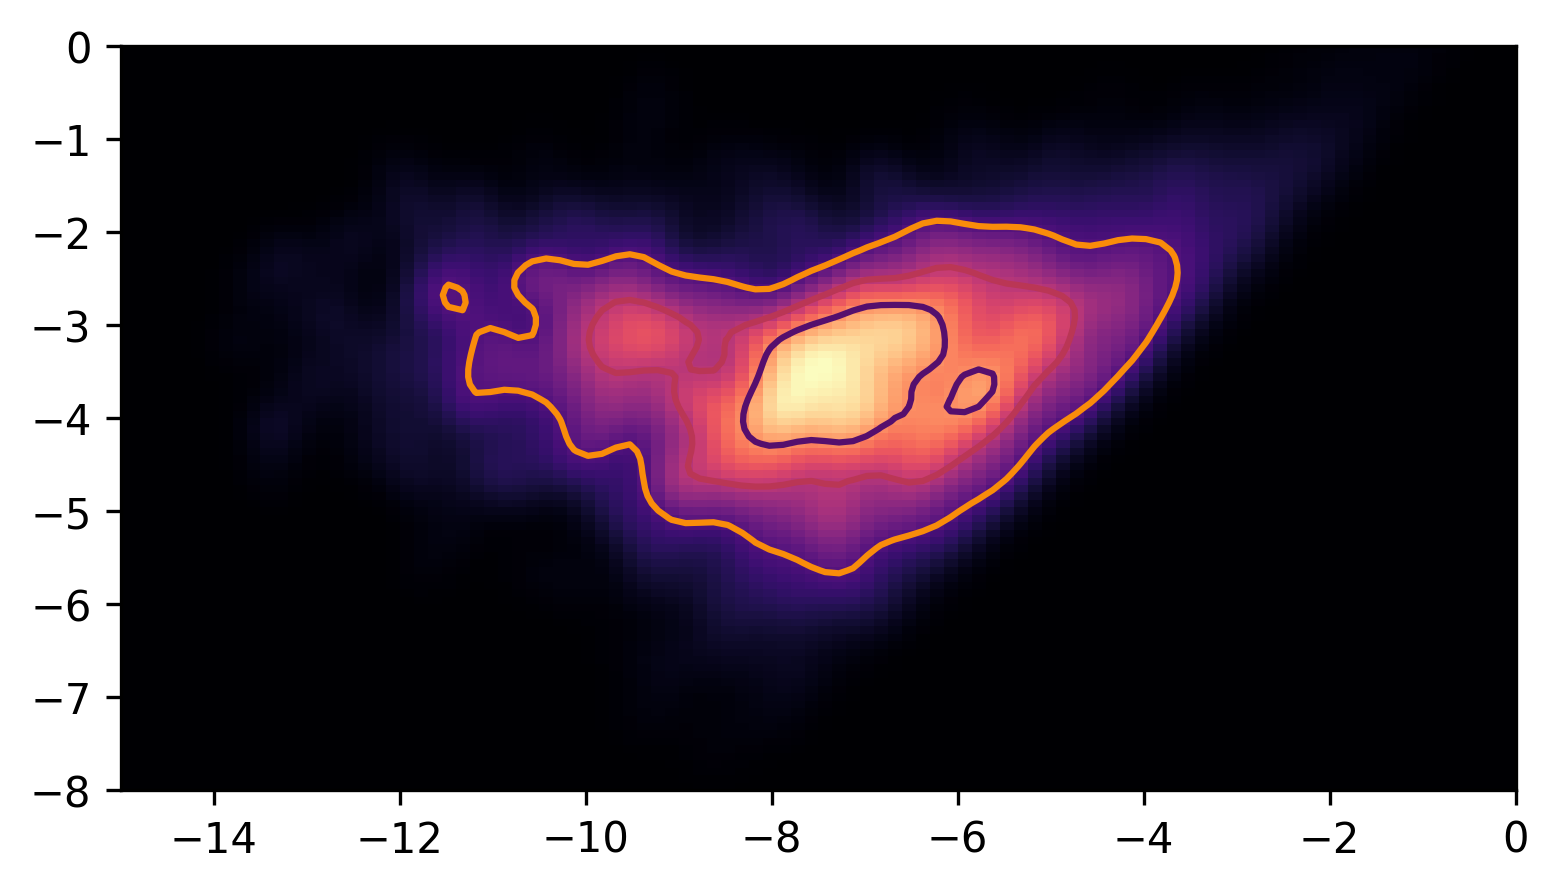

phase 1 model complete


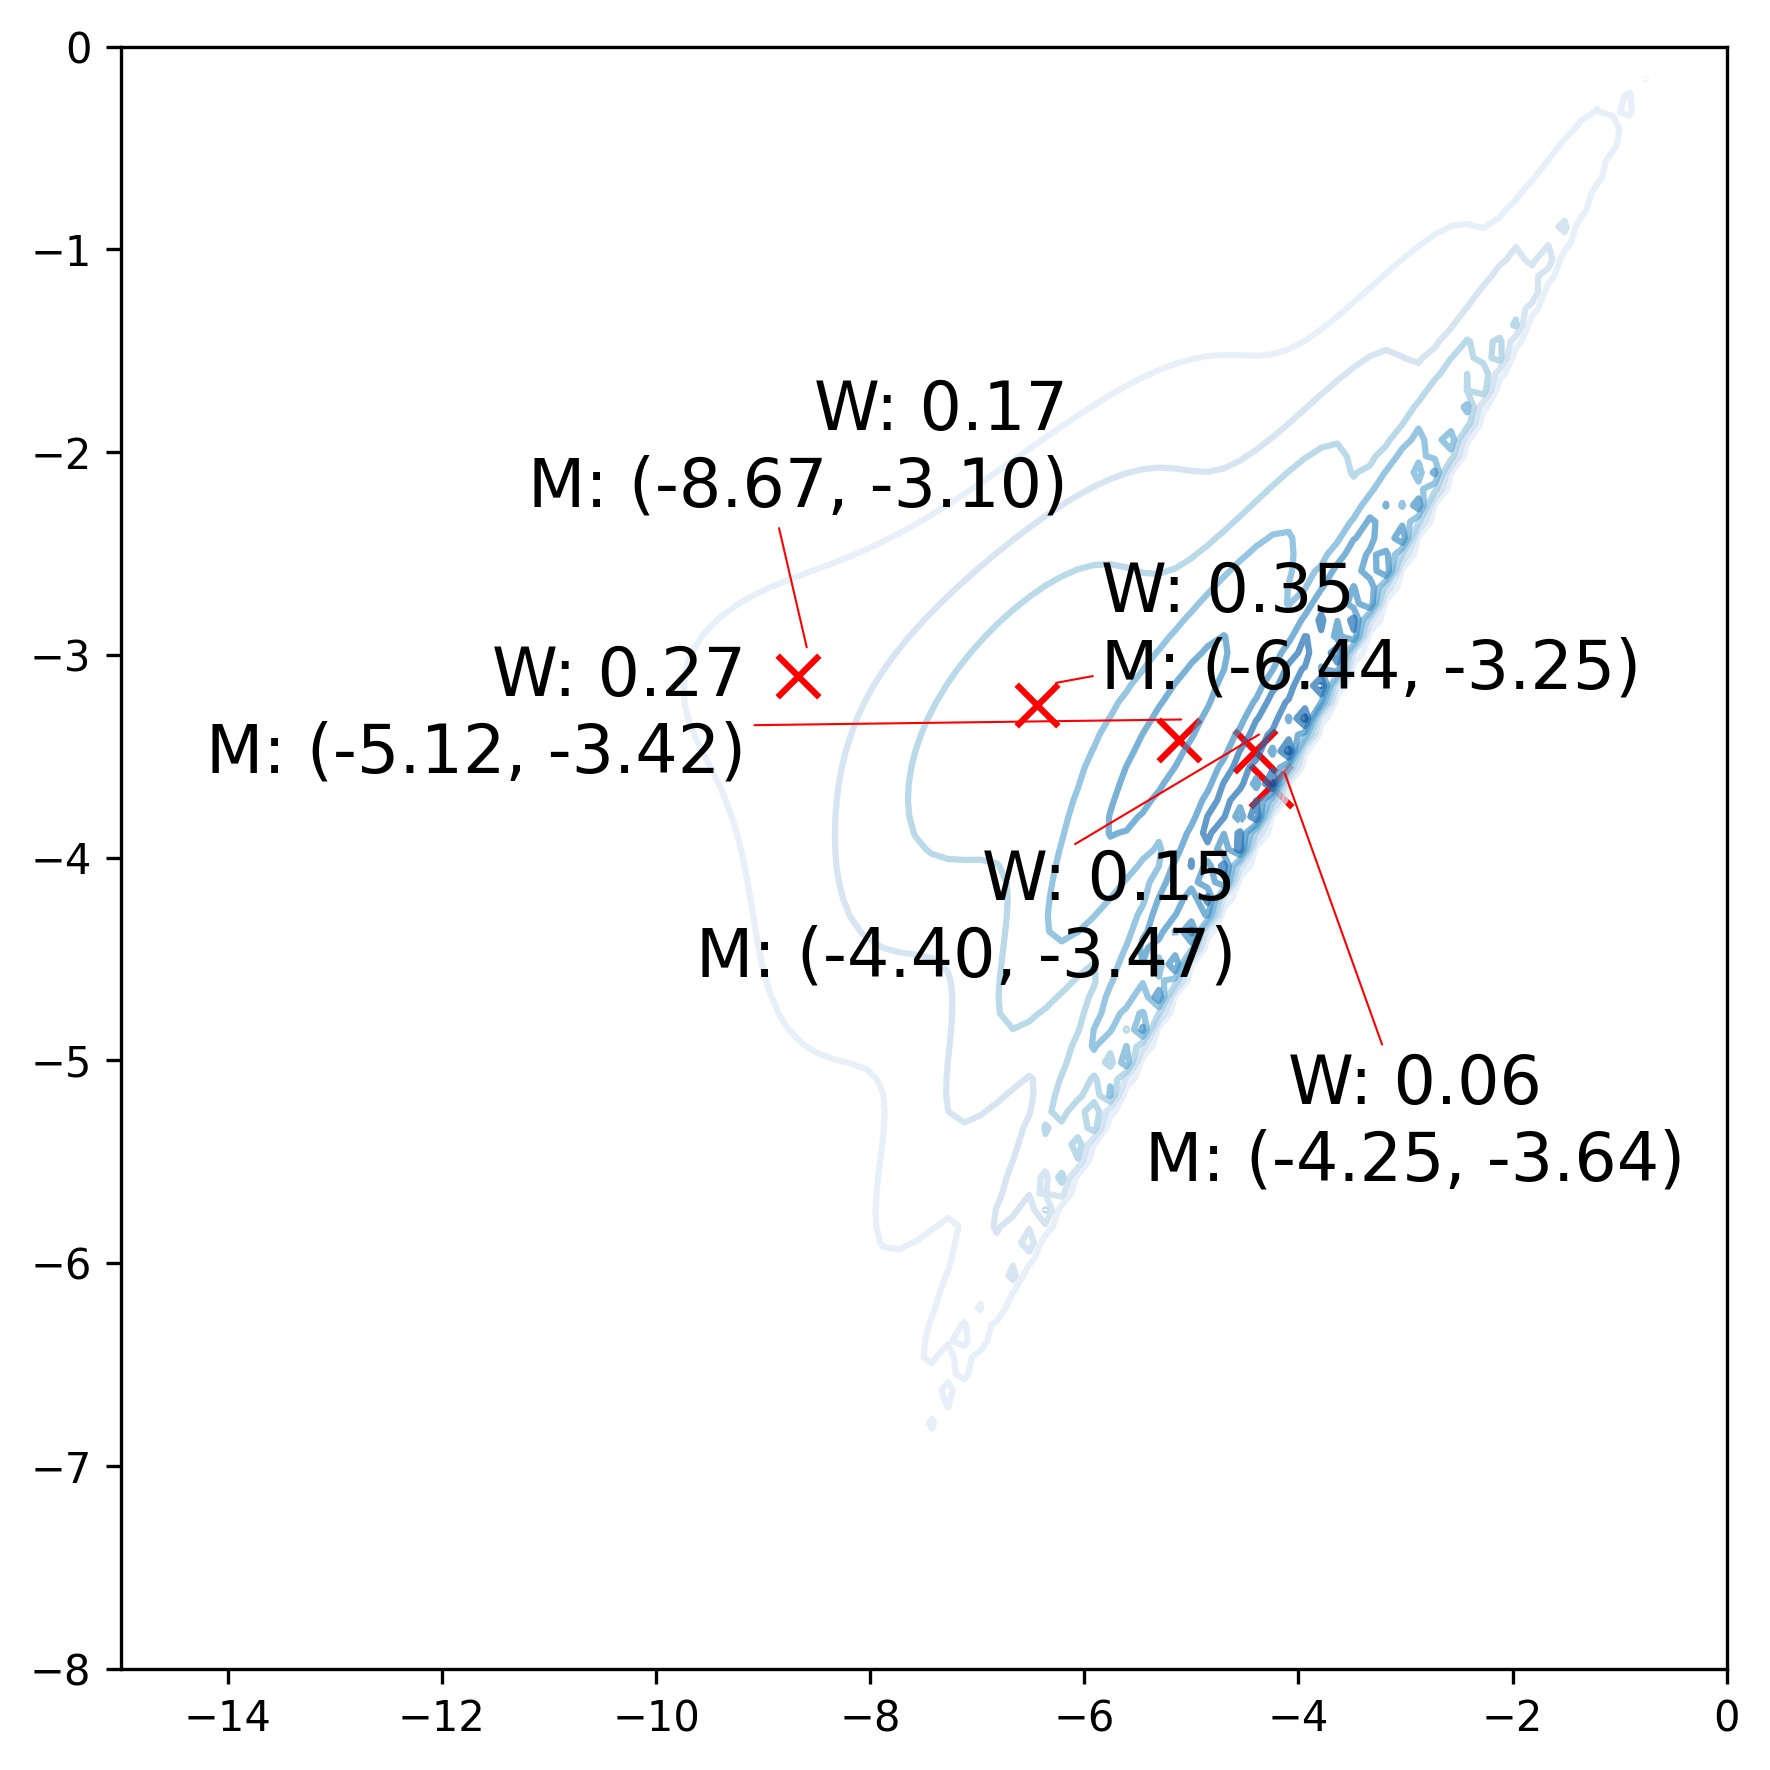

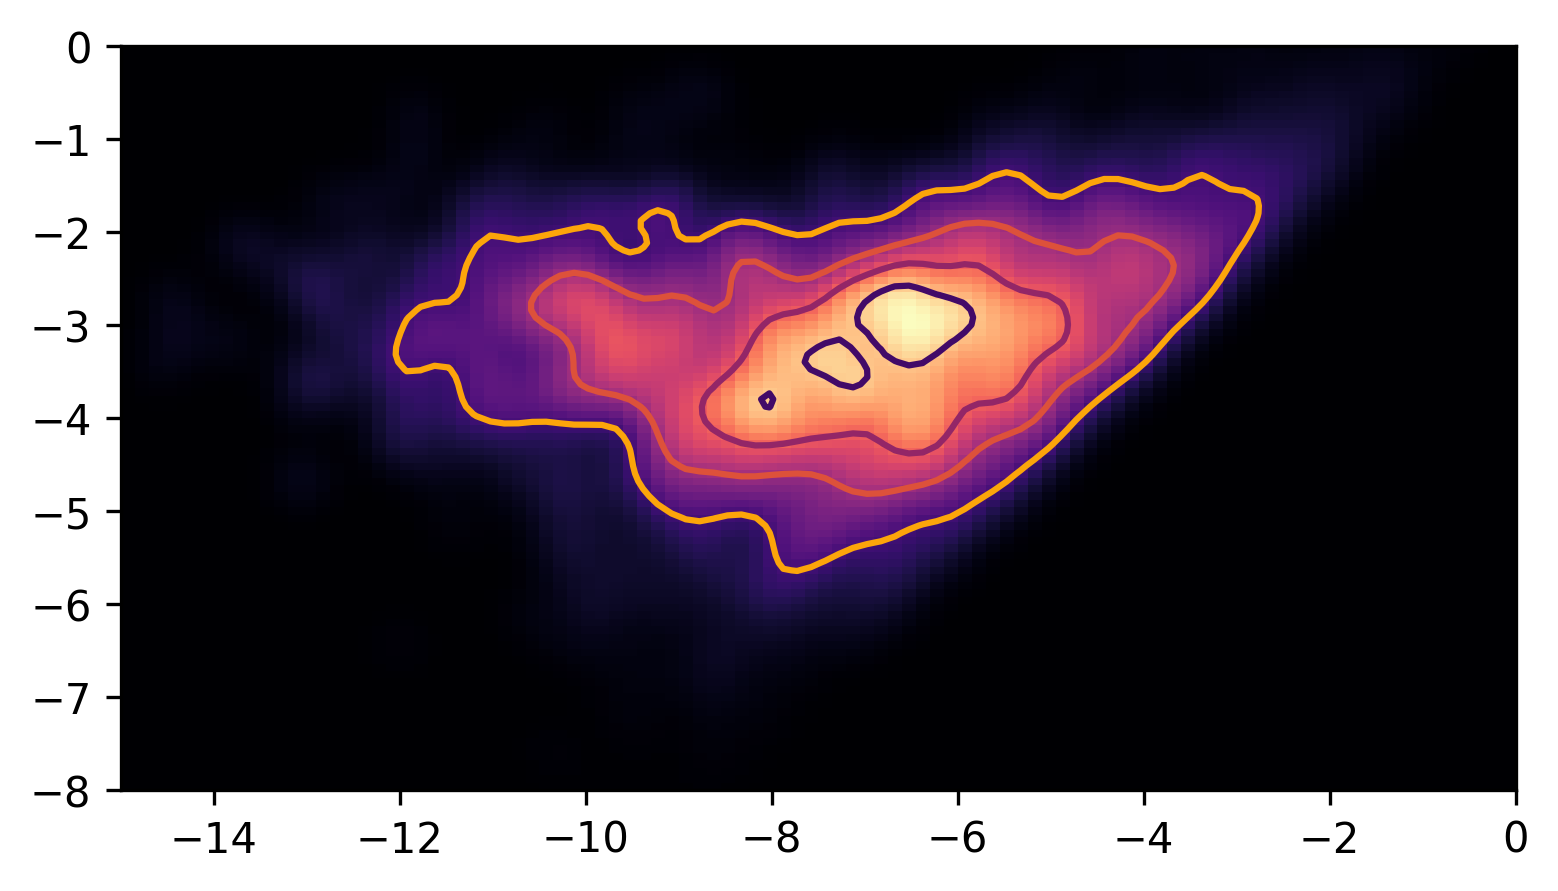

phase 2 model complete


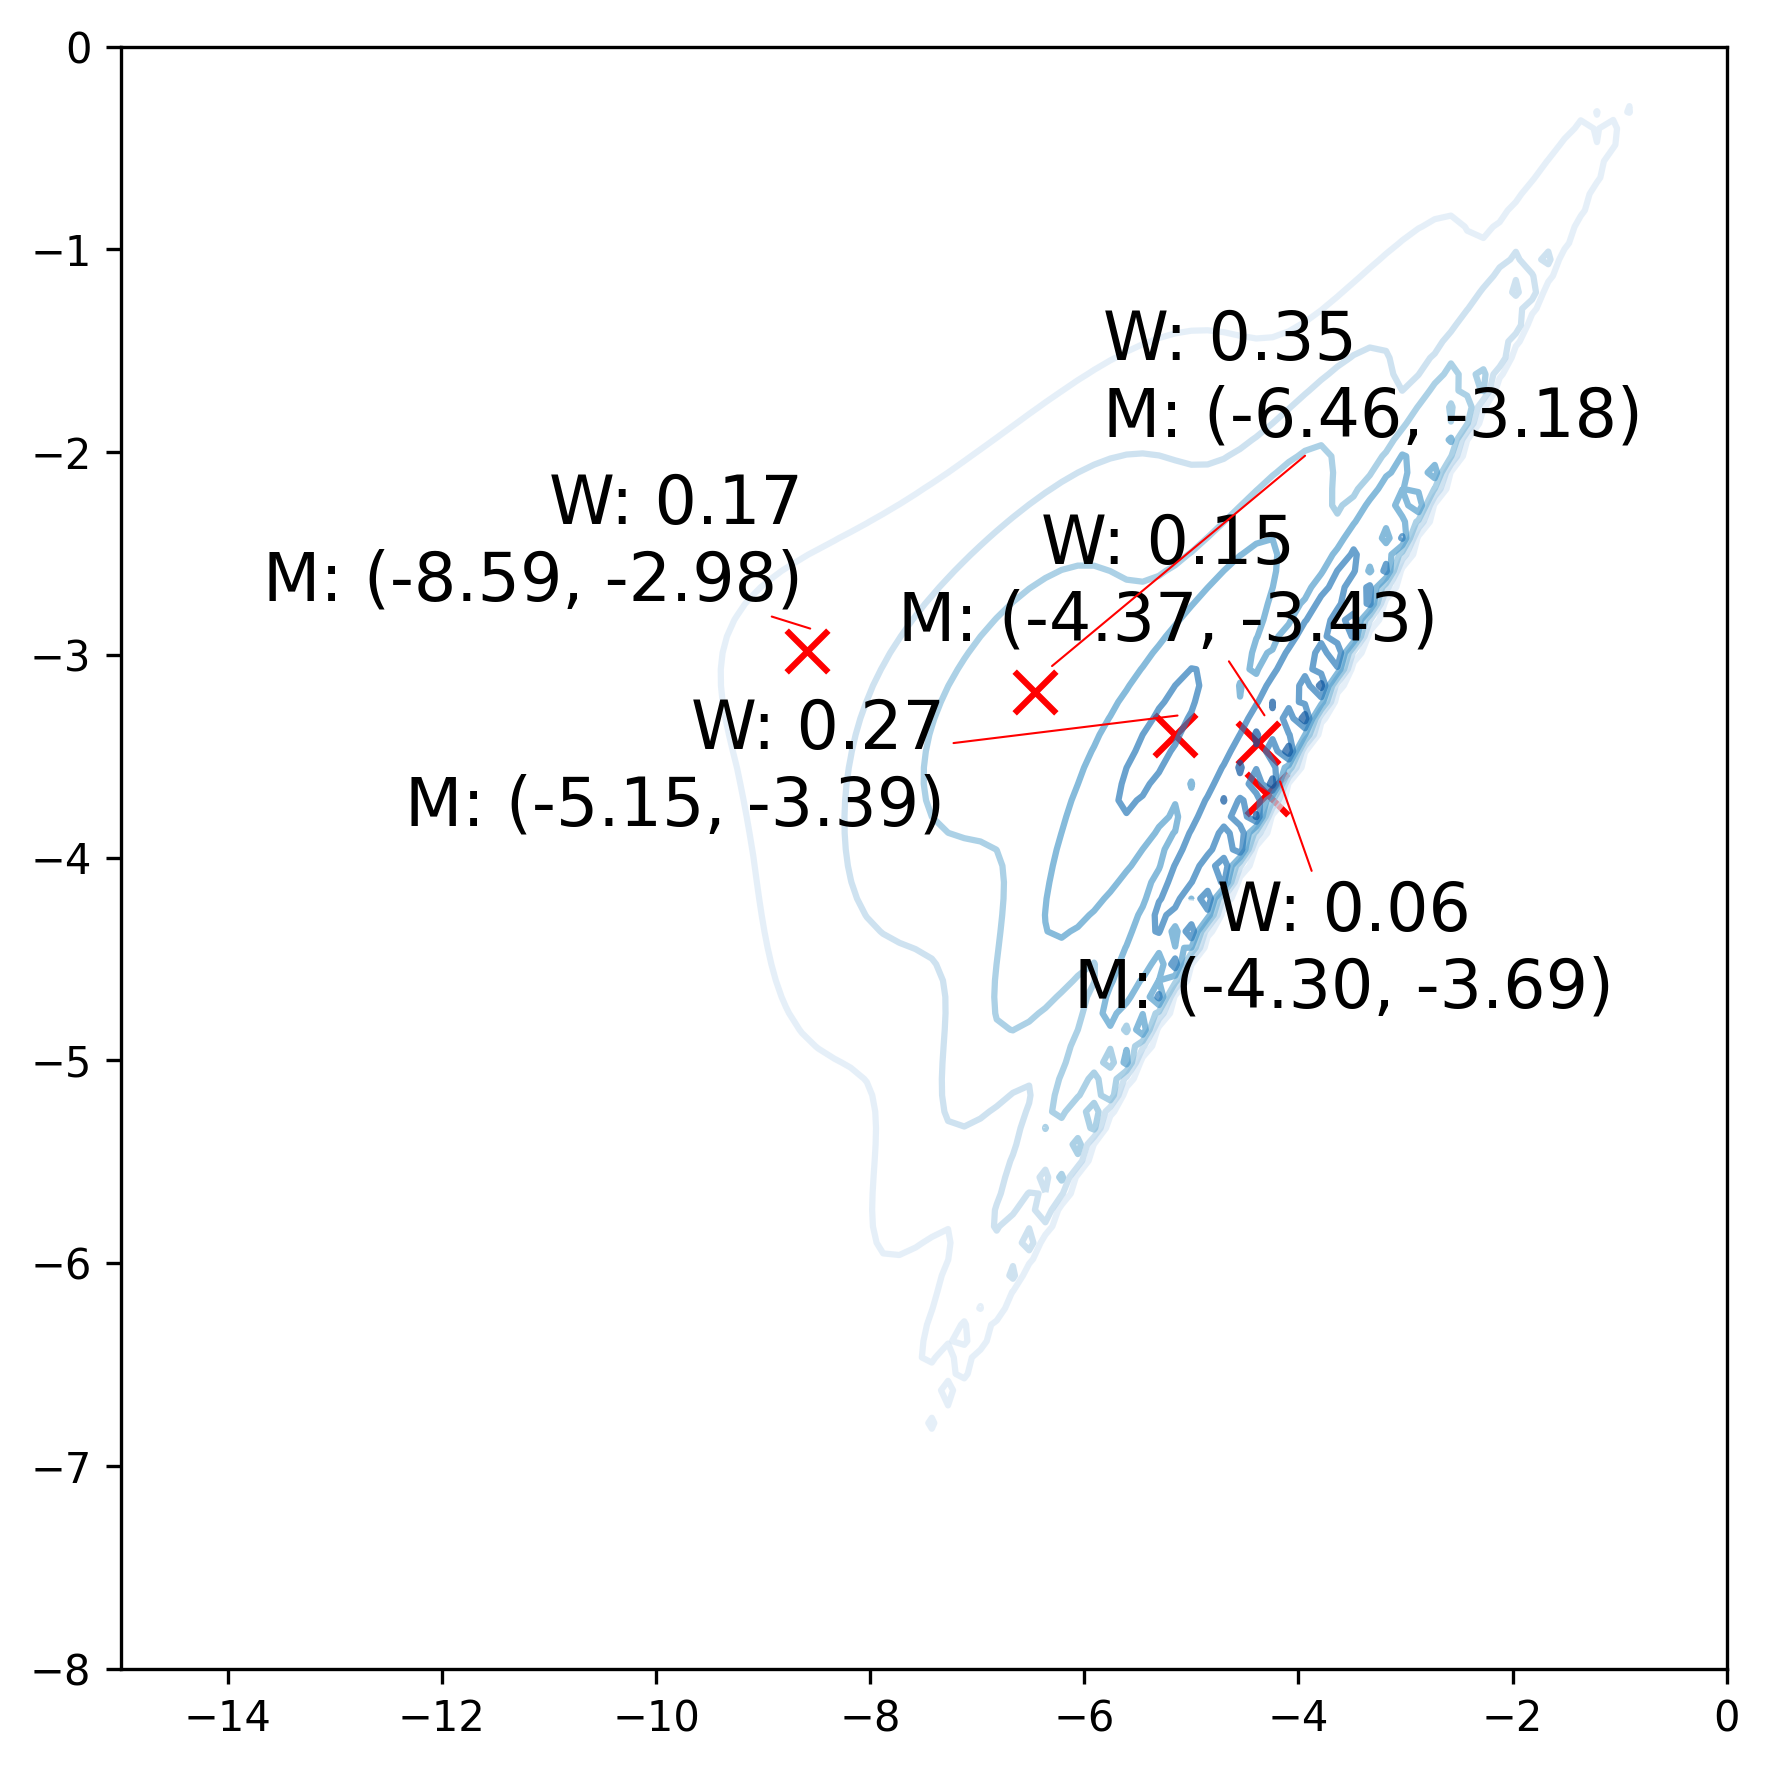

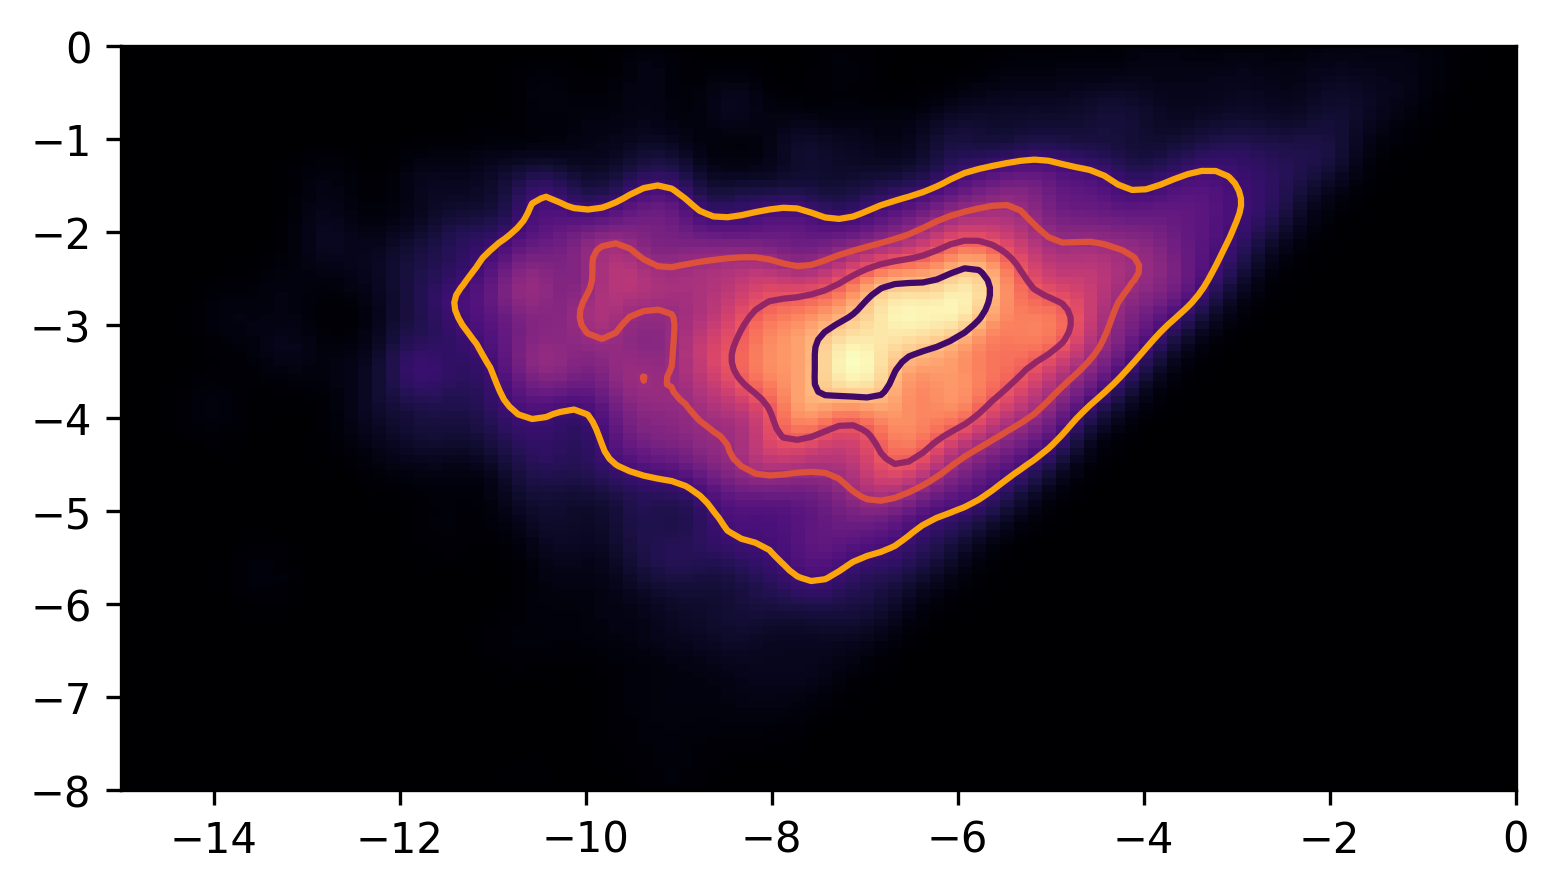

In [12]:
plot_func("ph0_sw", save=True)

phase 0 model complete


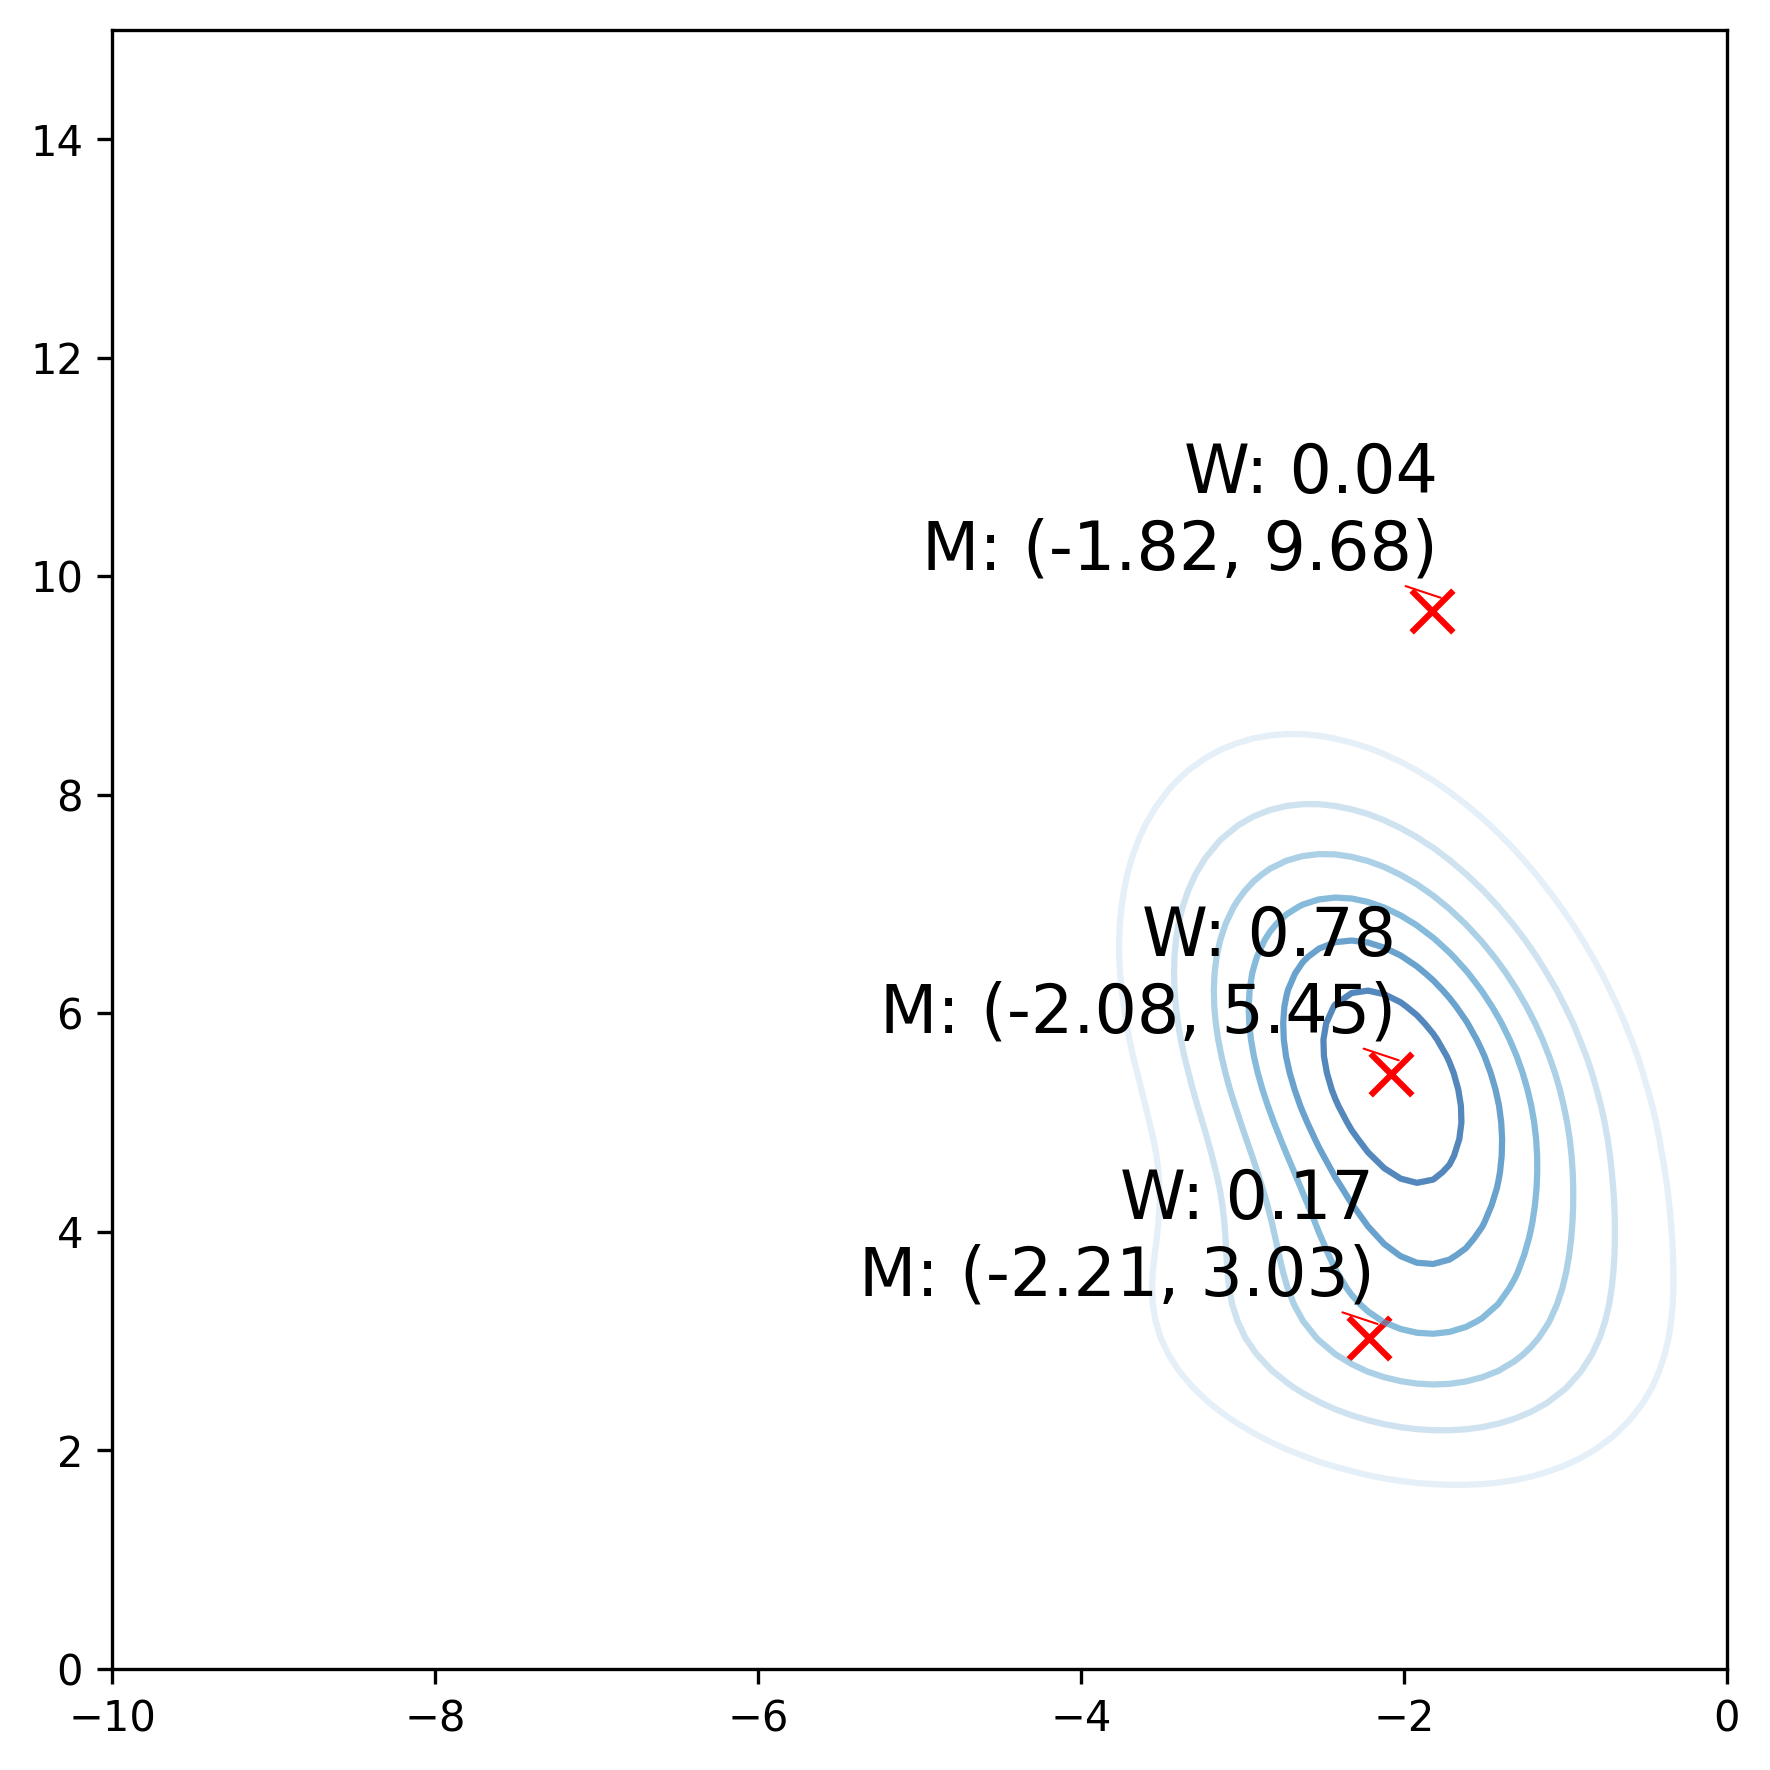

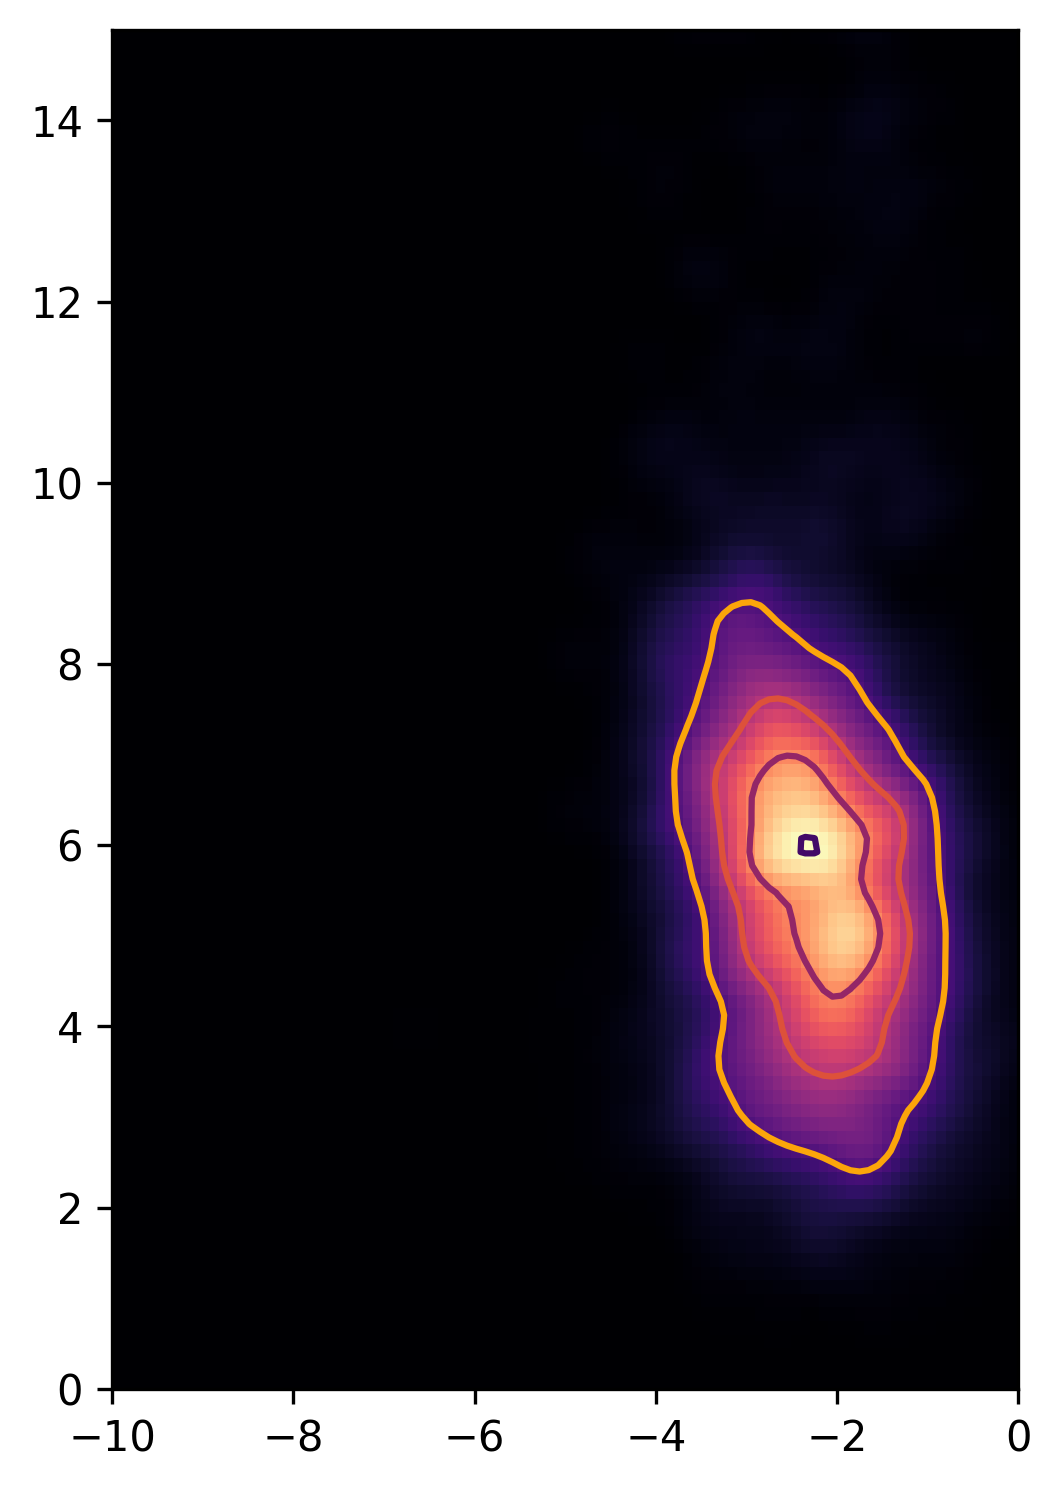

phase 1 model complete


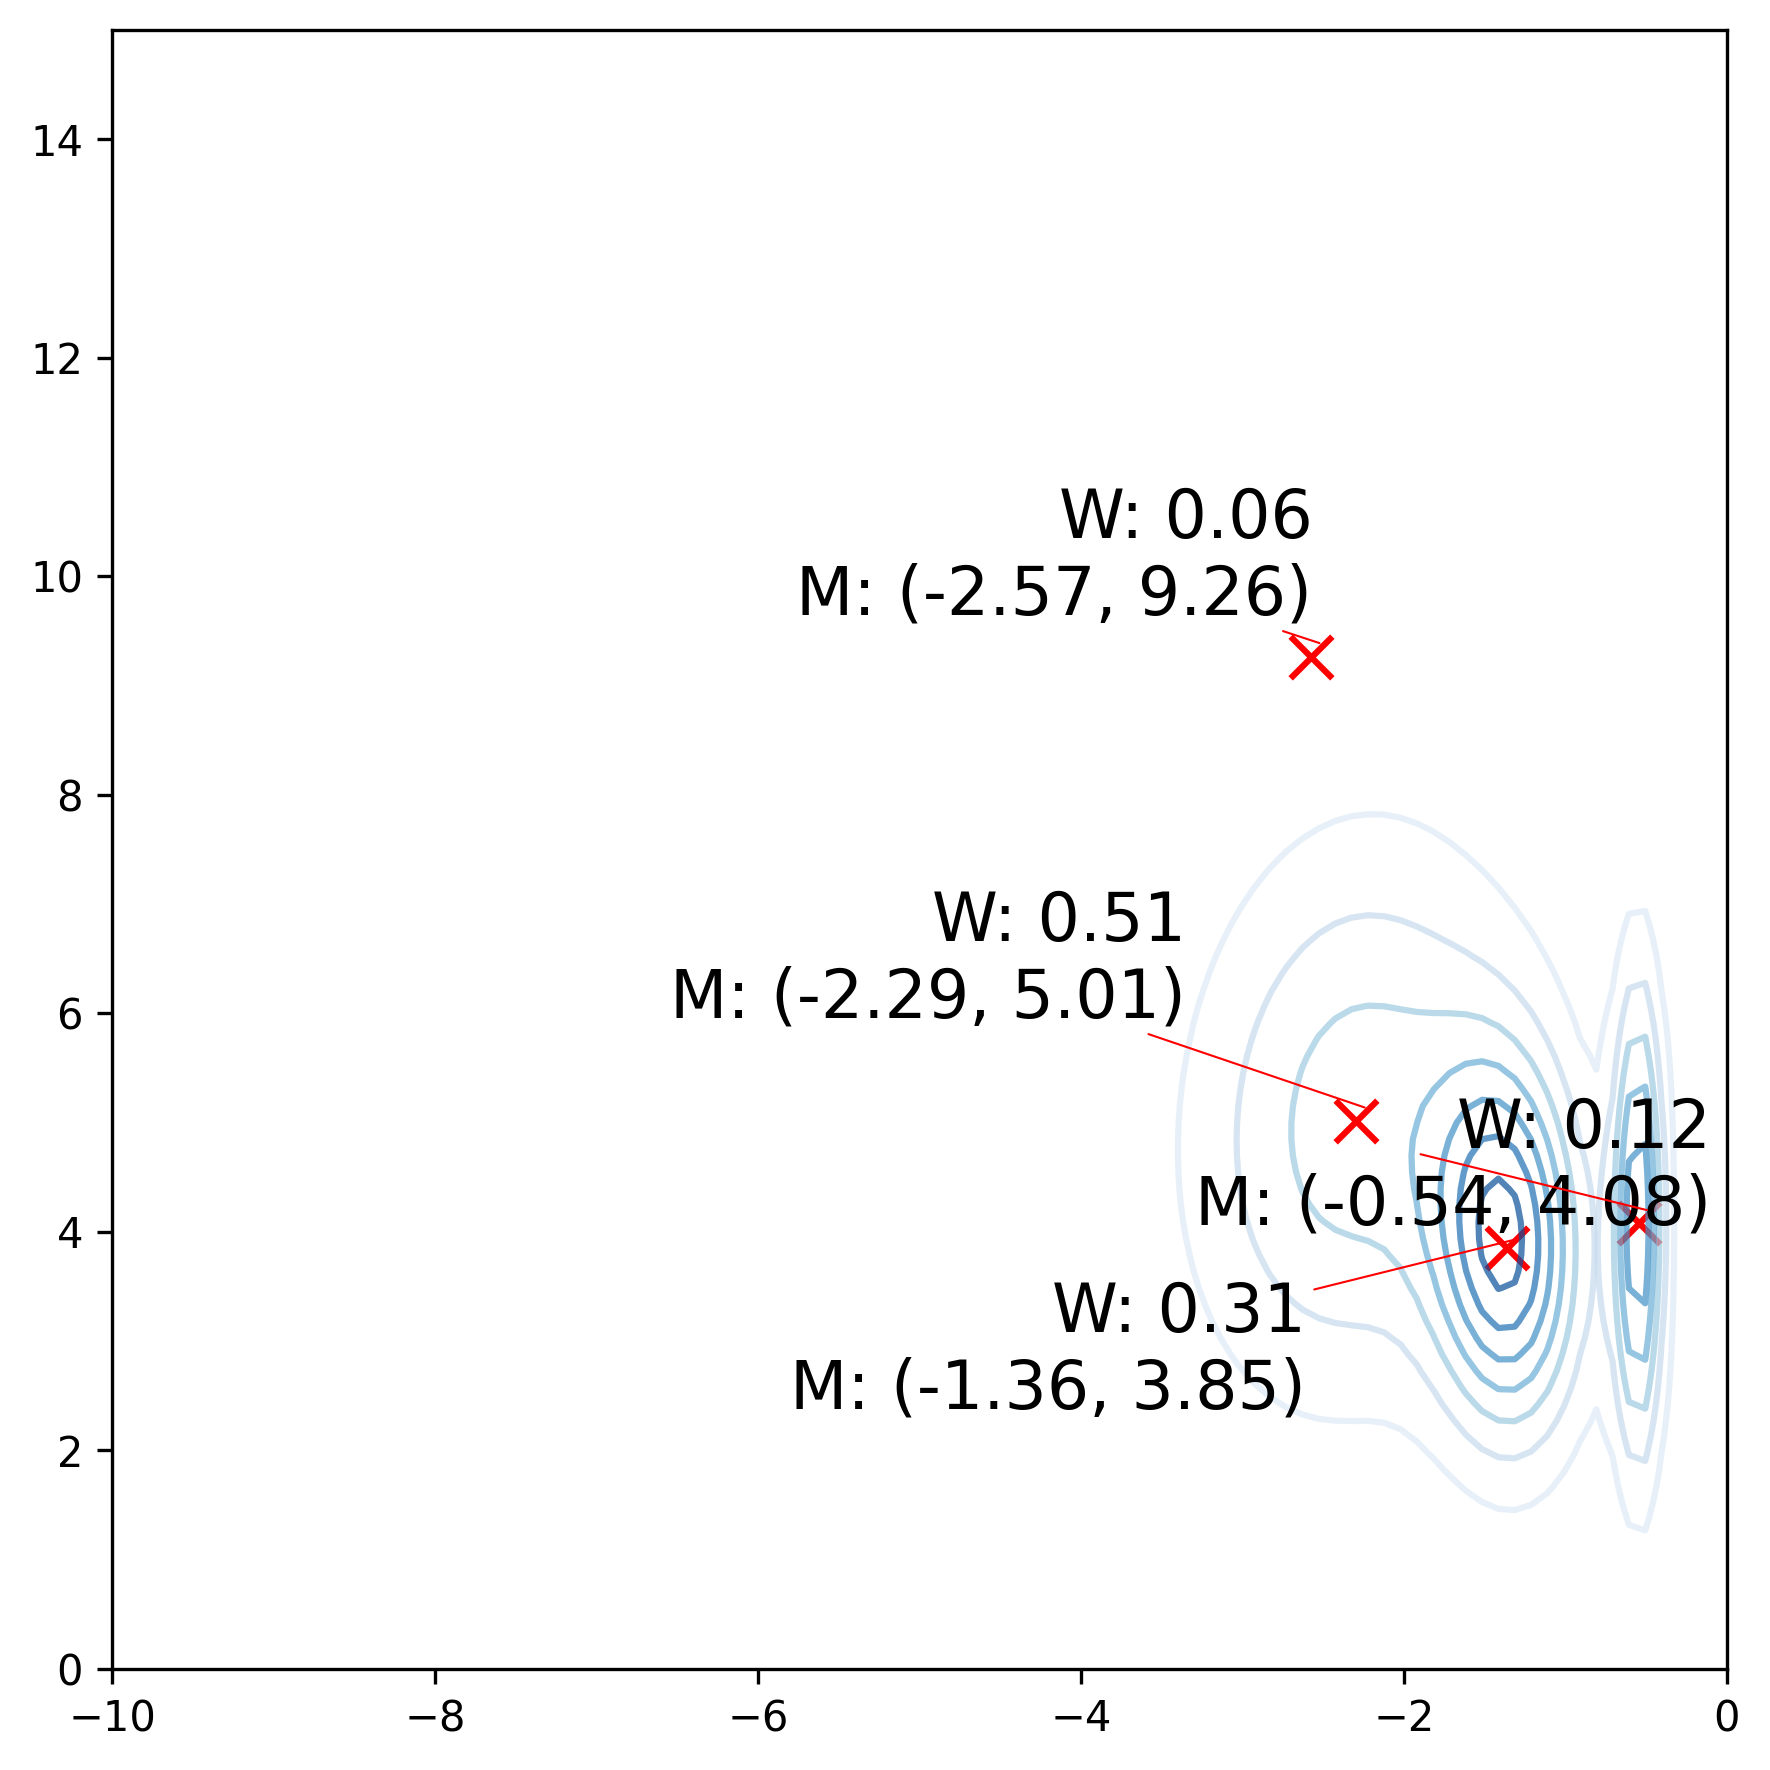

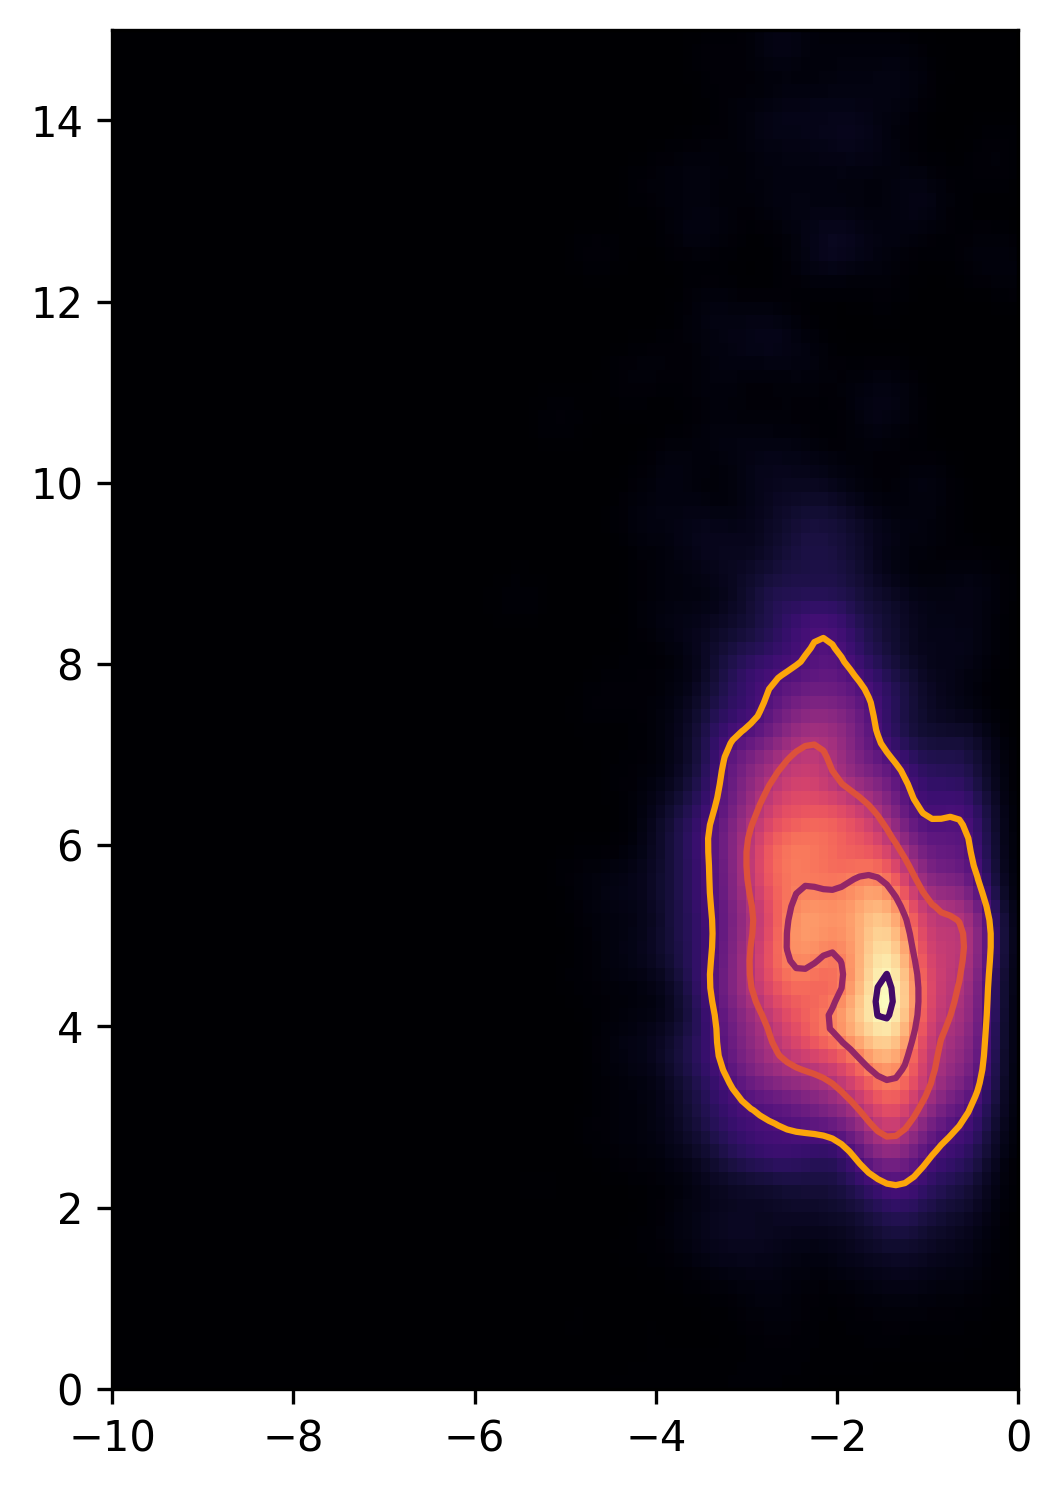

phase 2 model complete


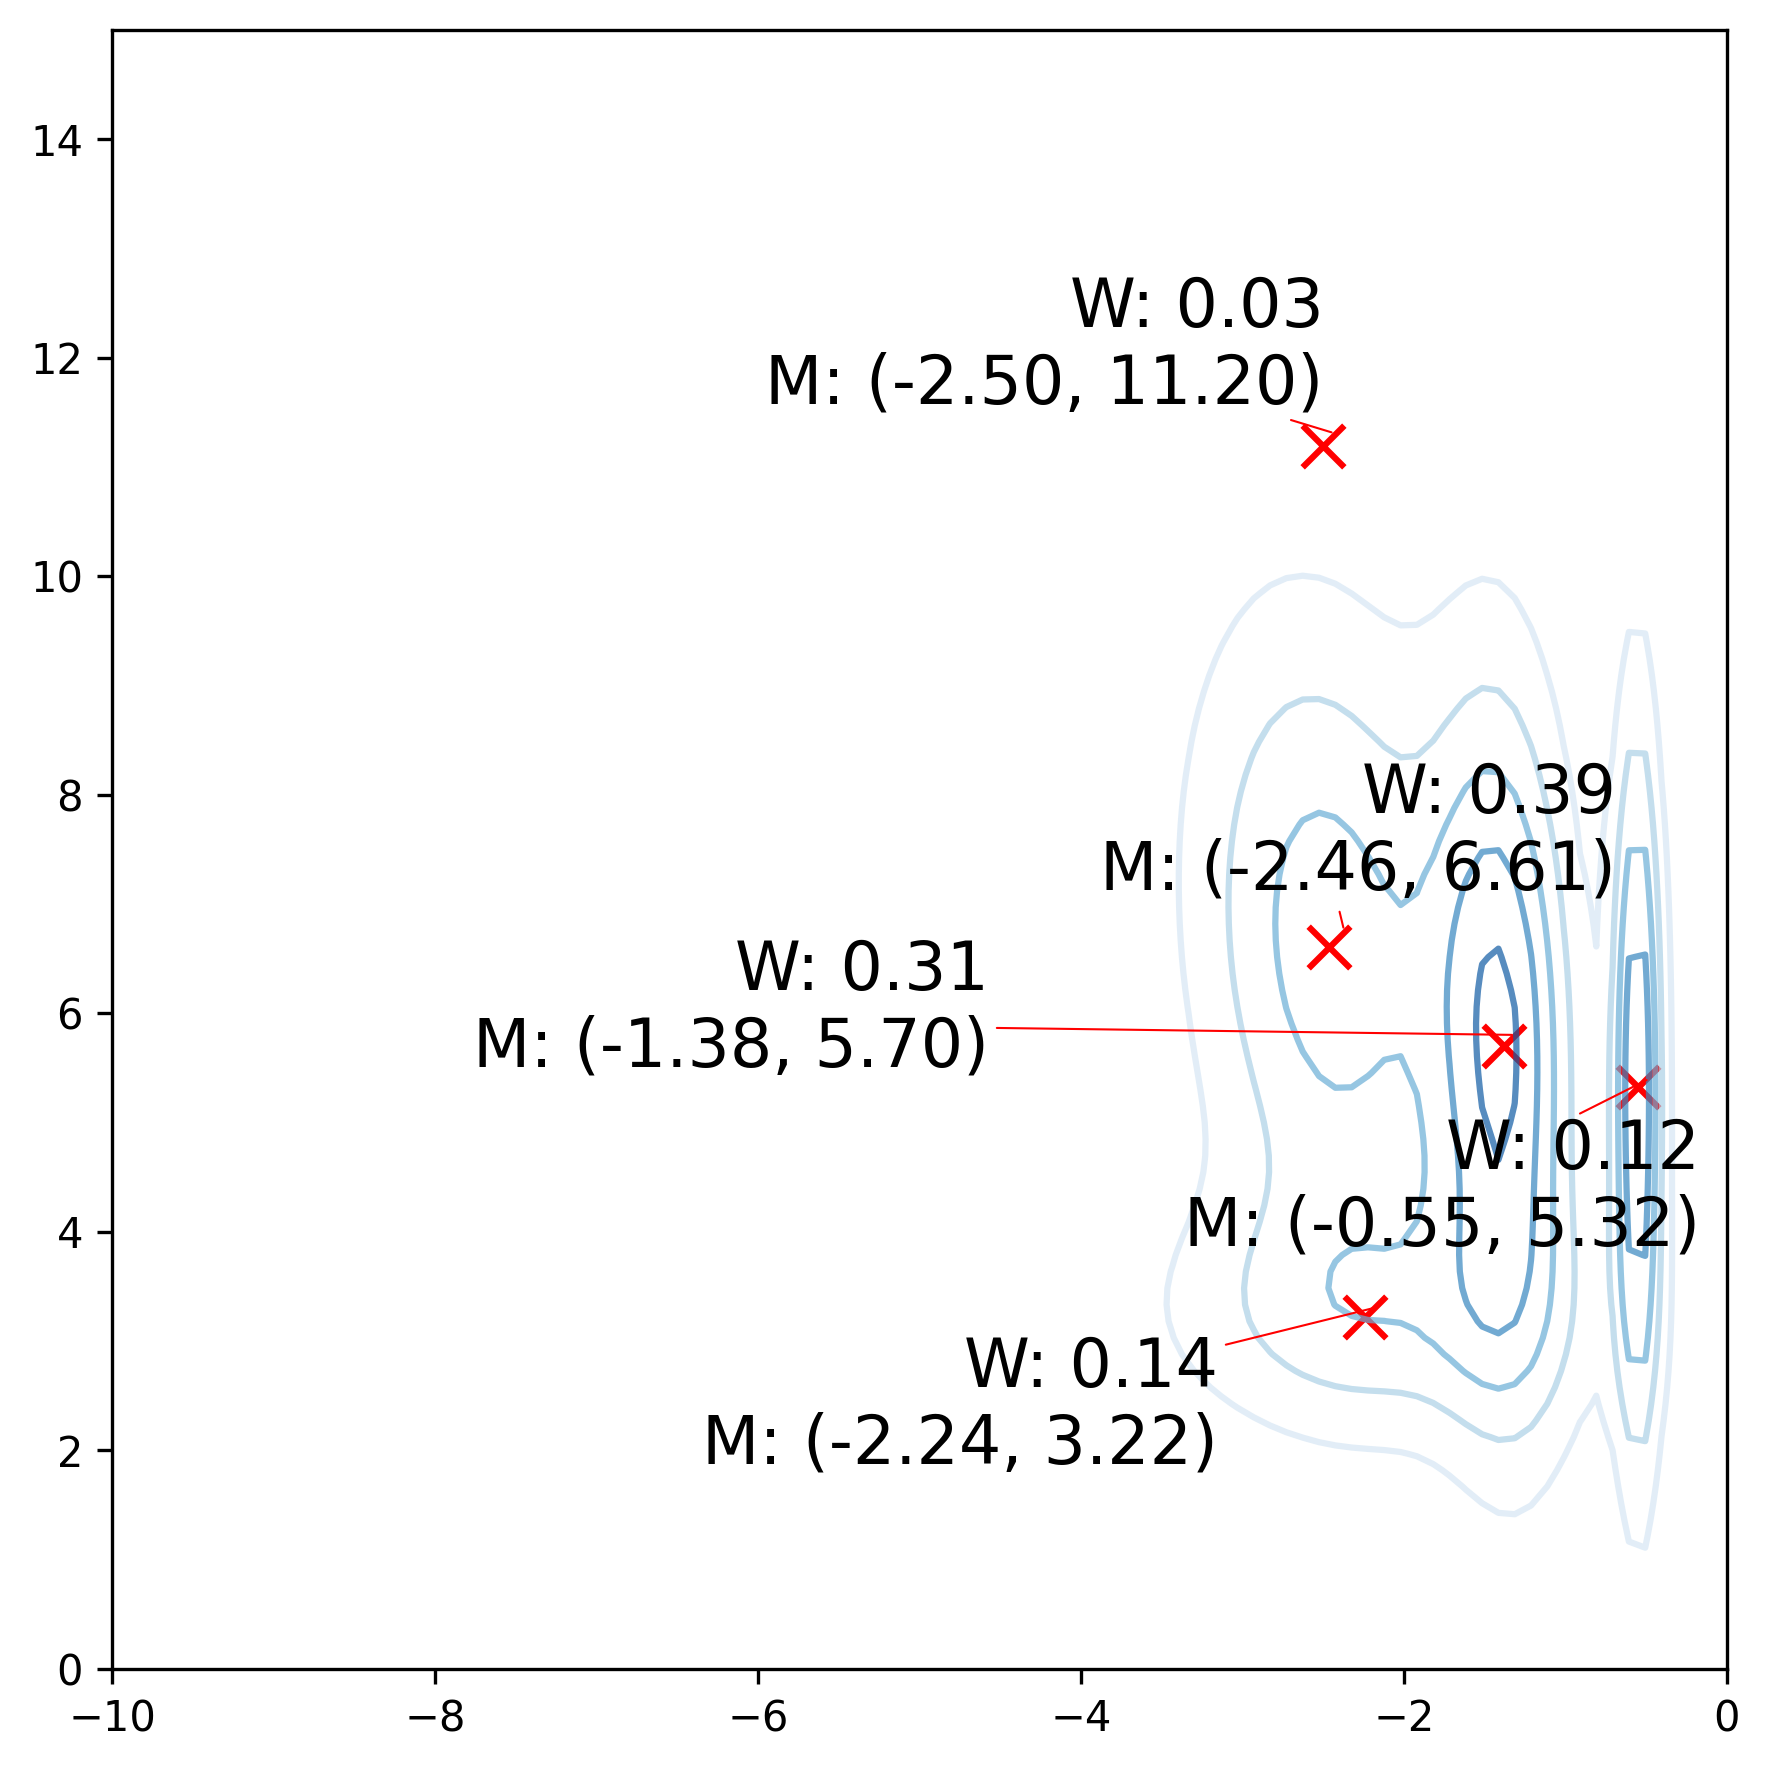

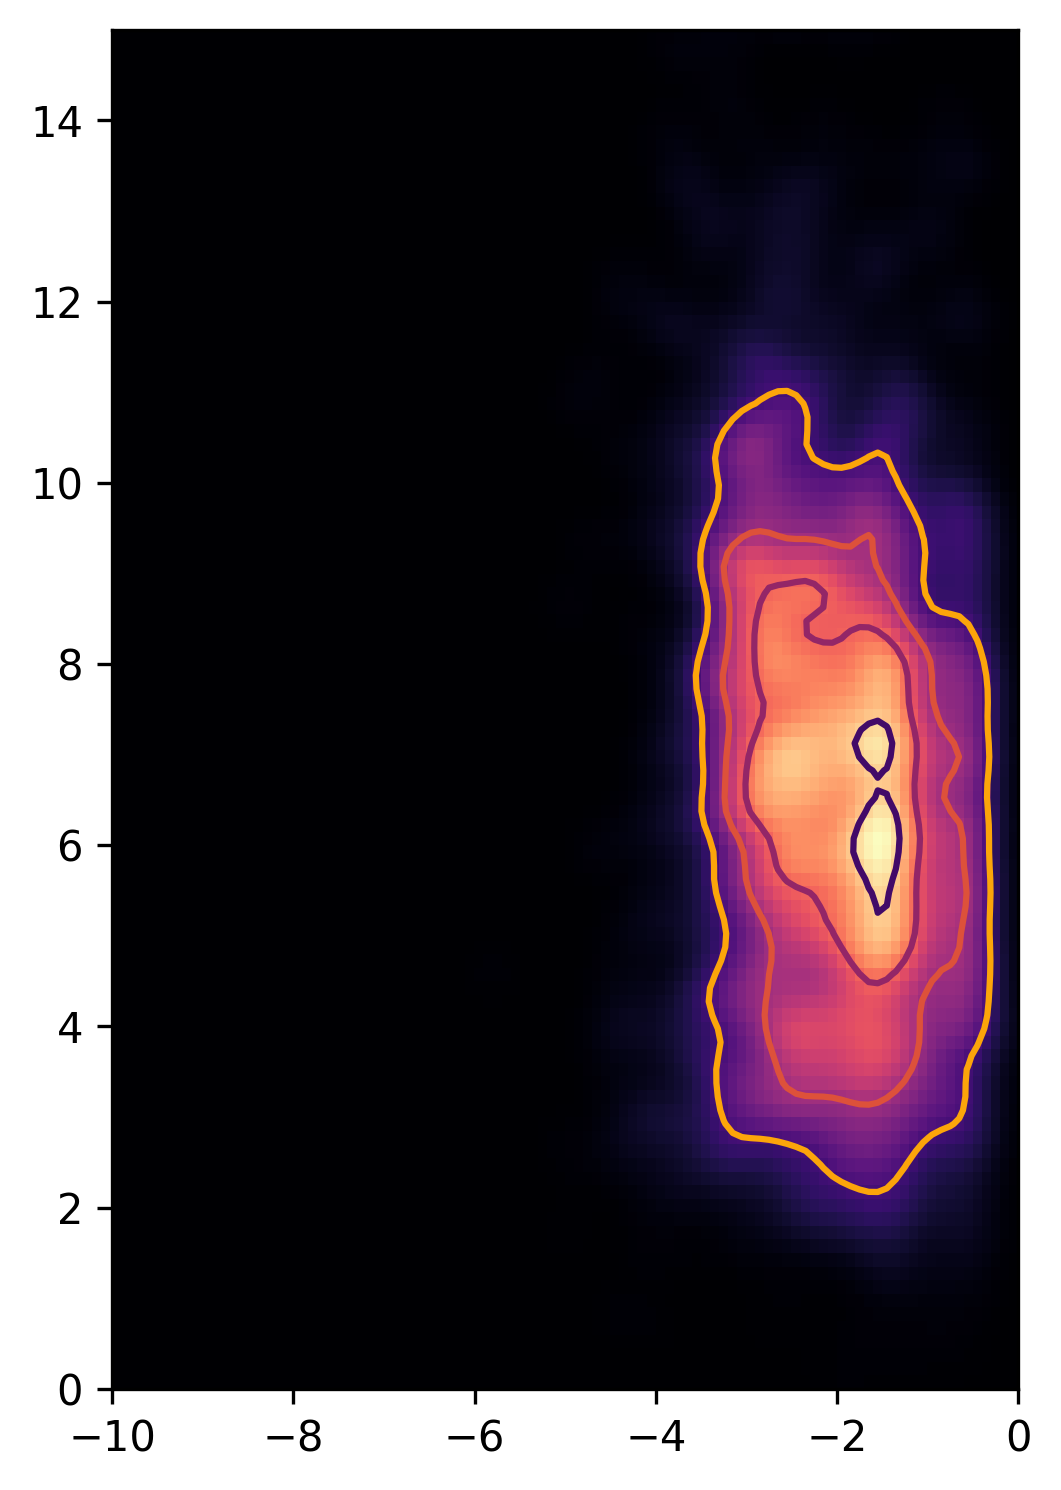

In [13]:
plot_func("ph1_nw", save=True)

phase 0 model complete


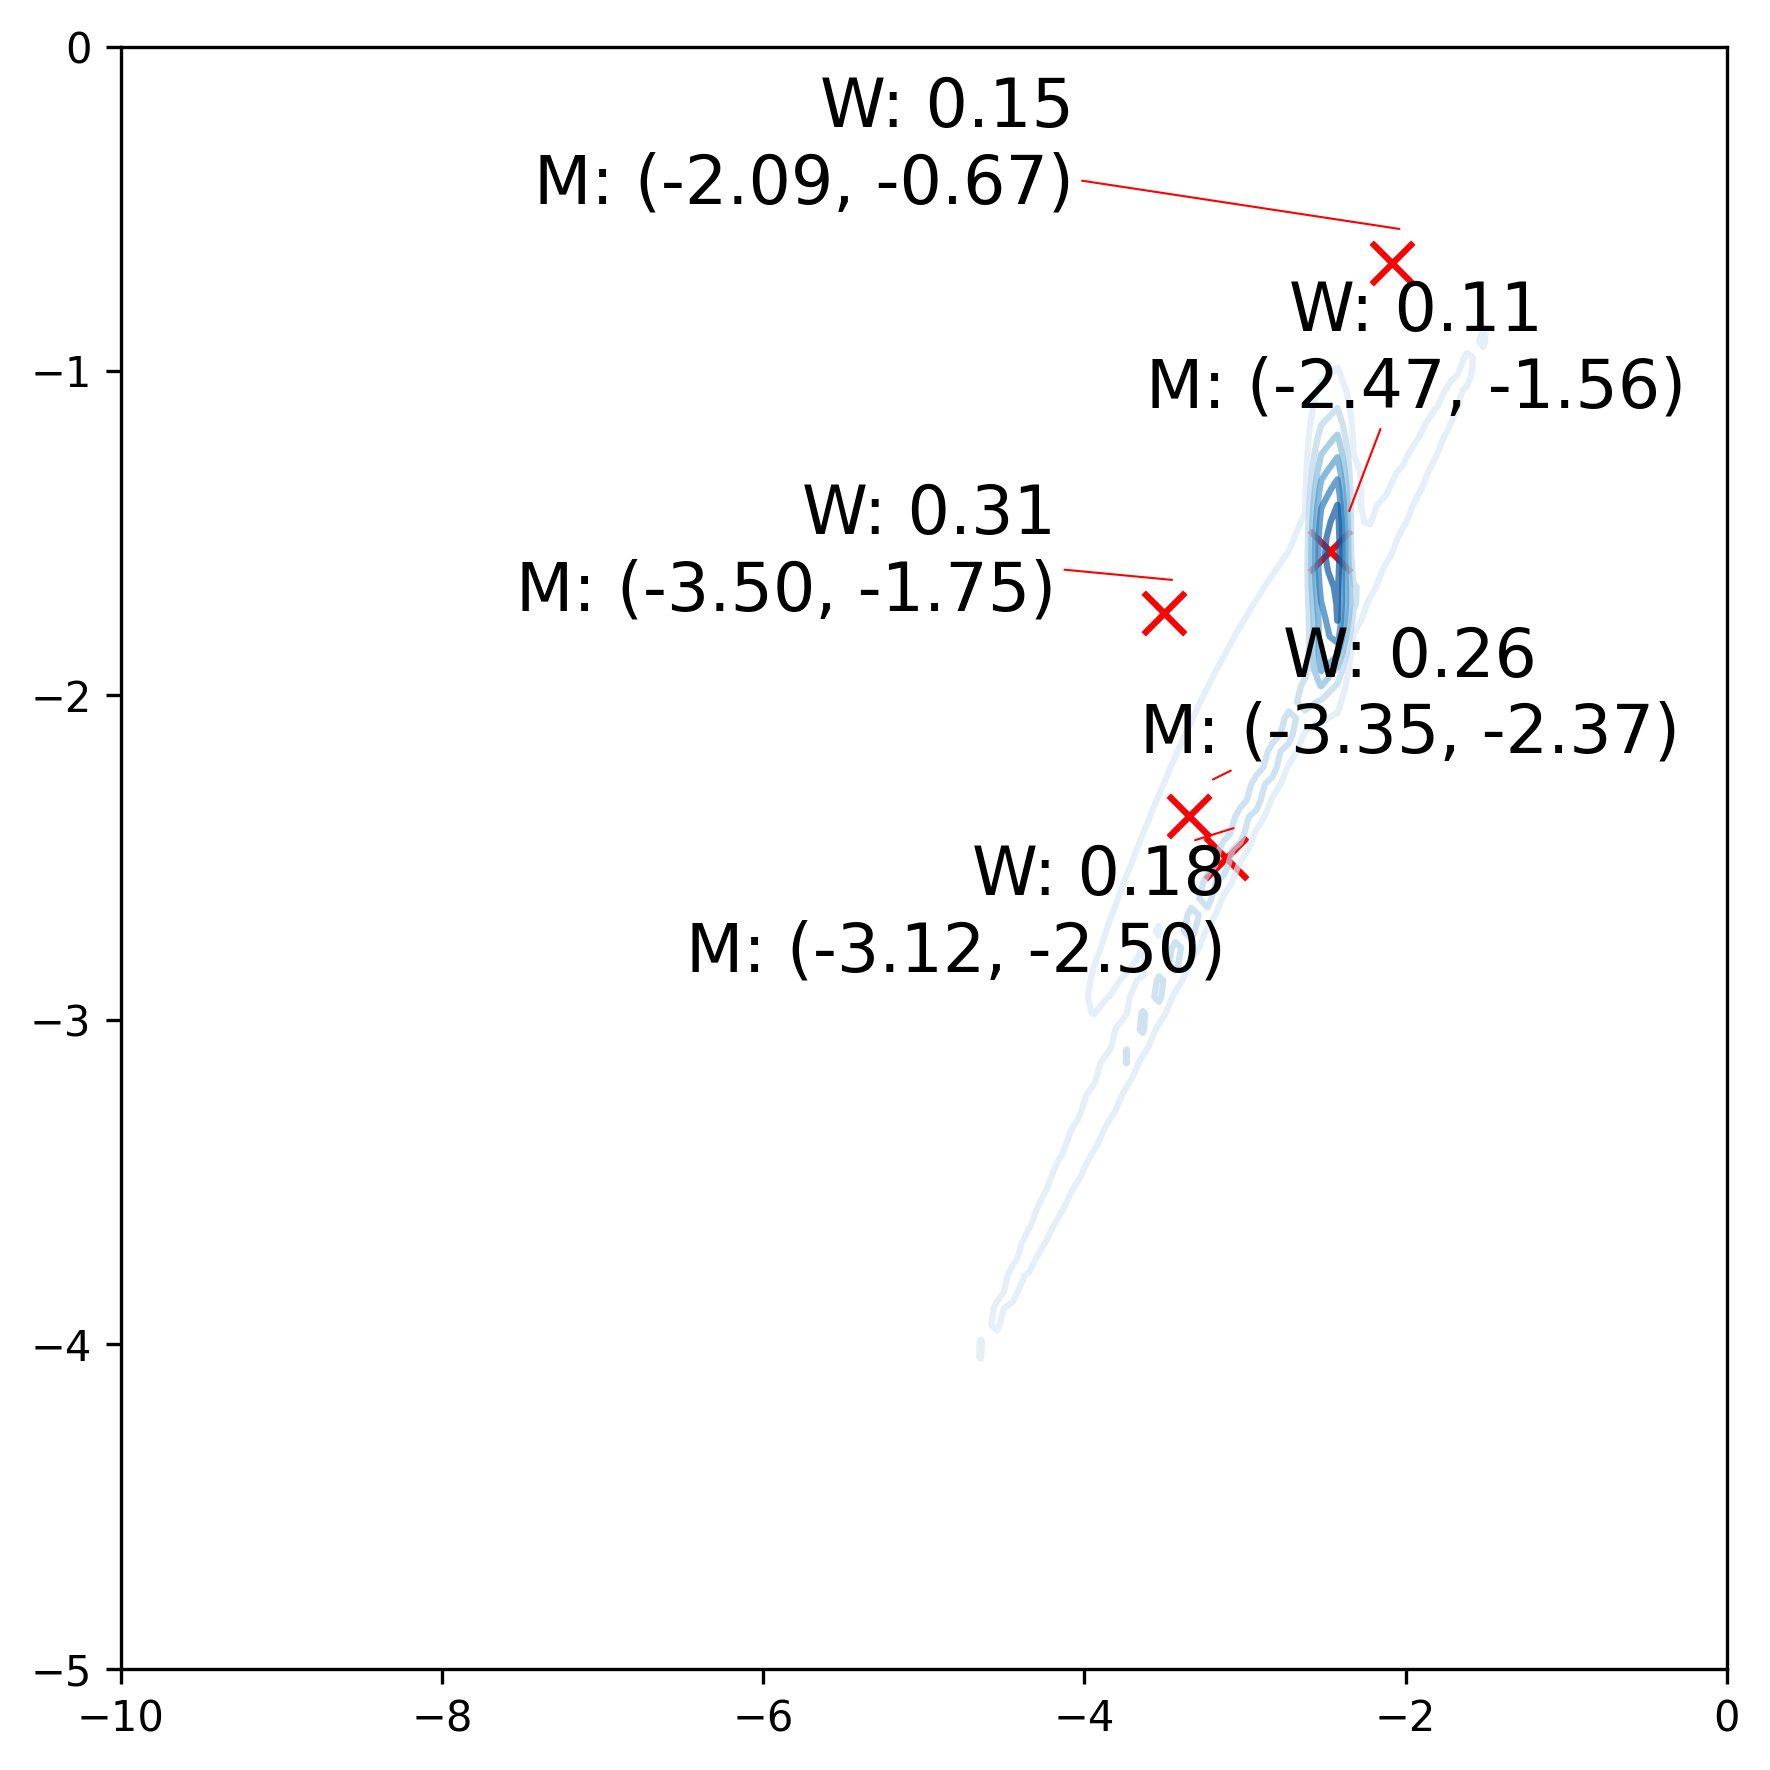

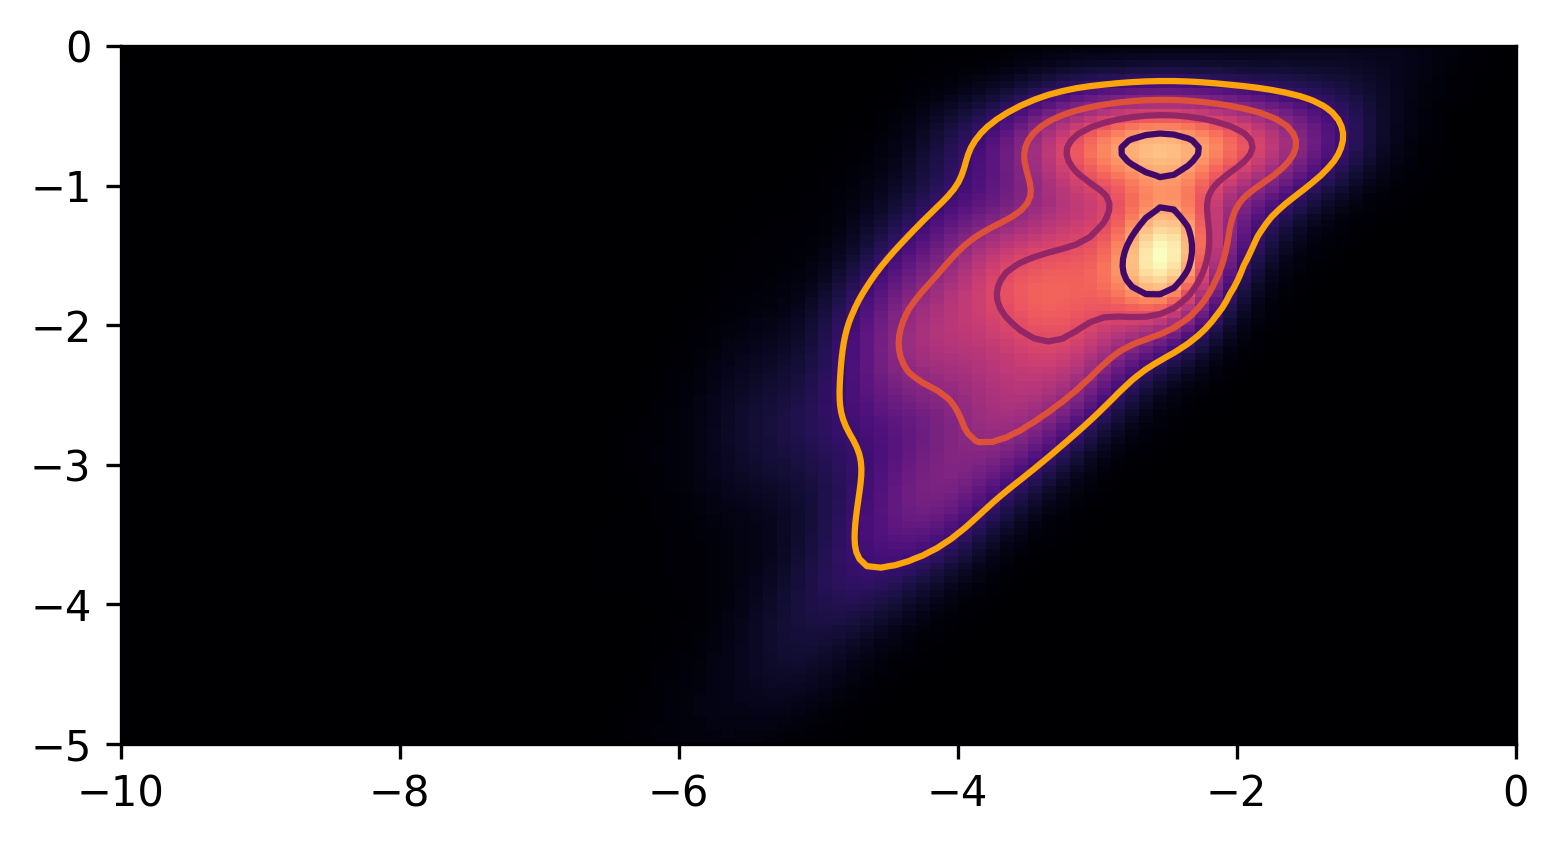

phase 1 model complete


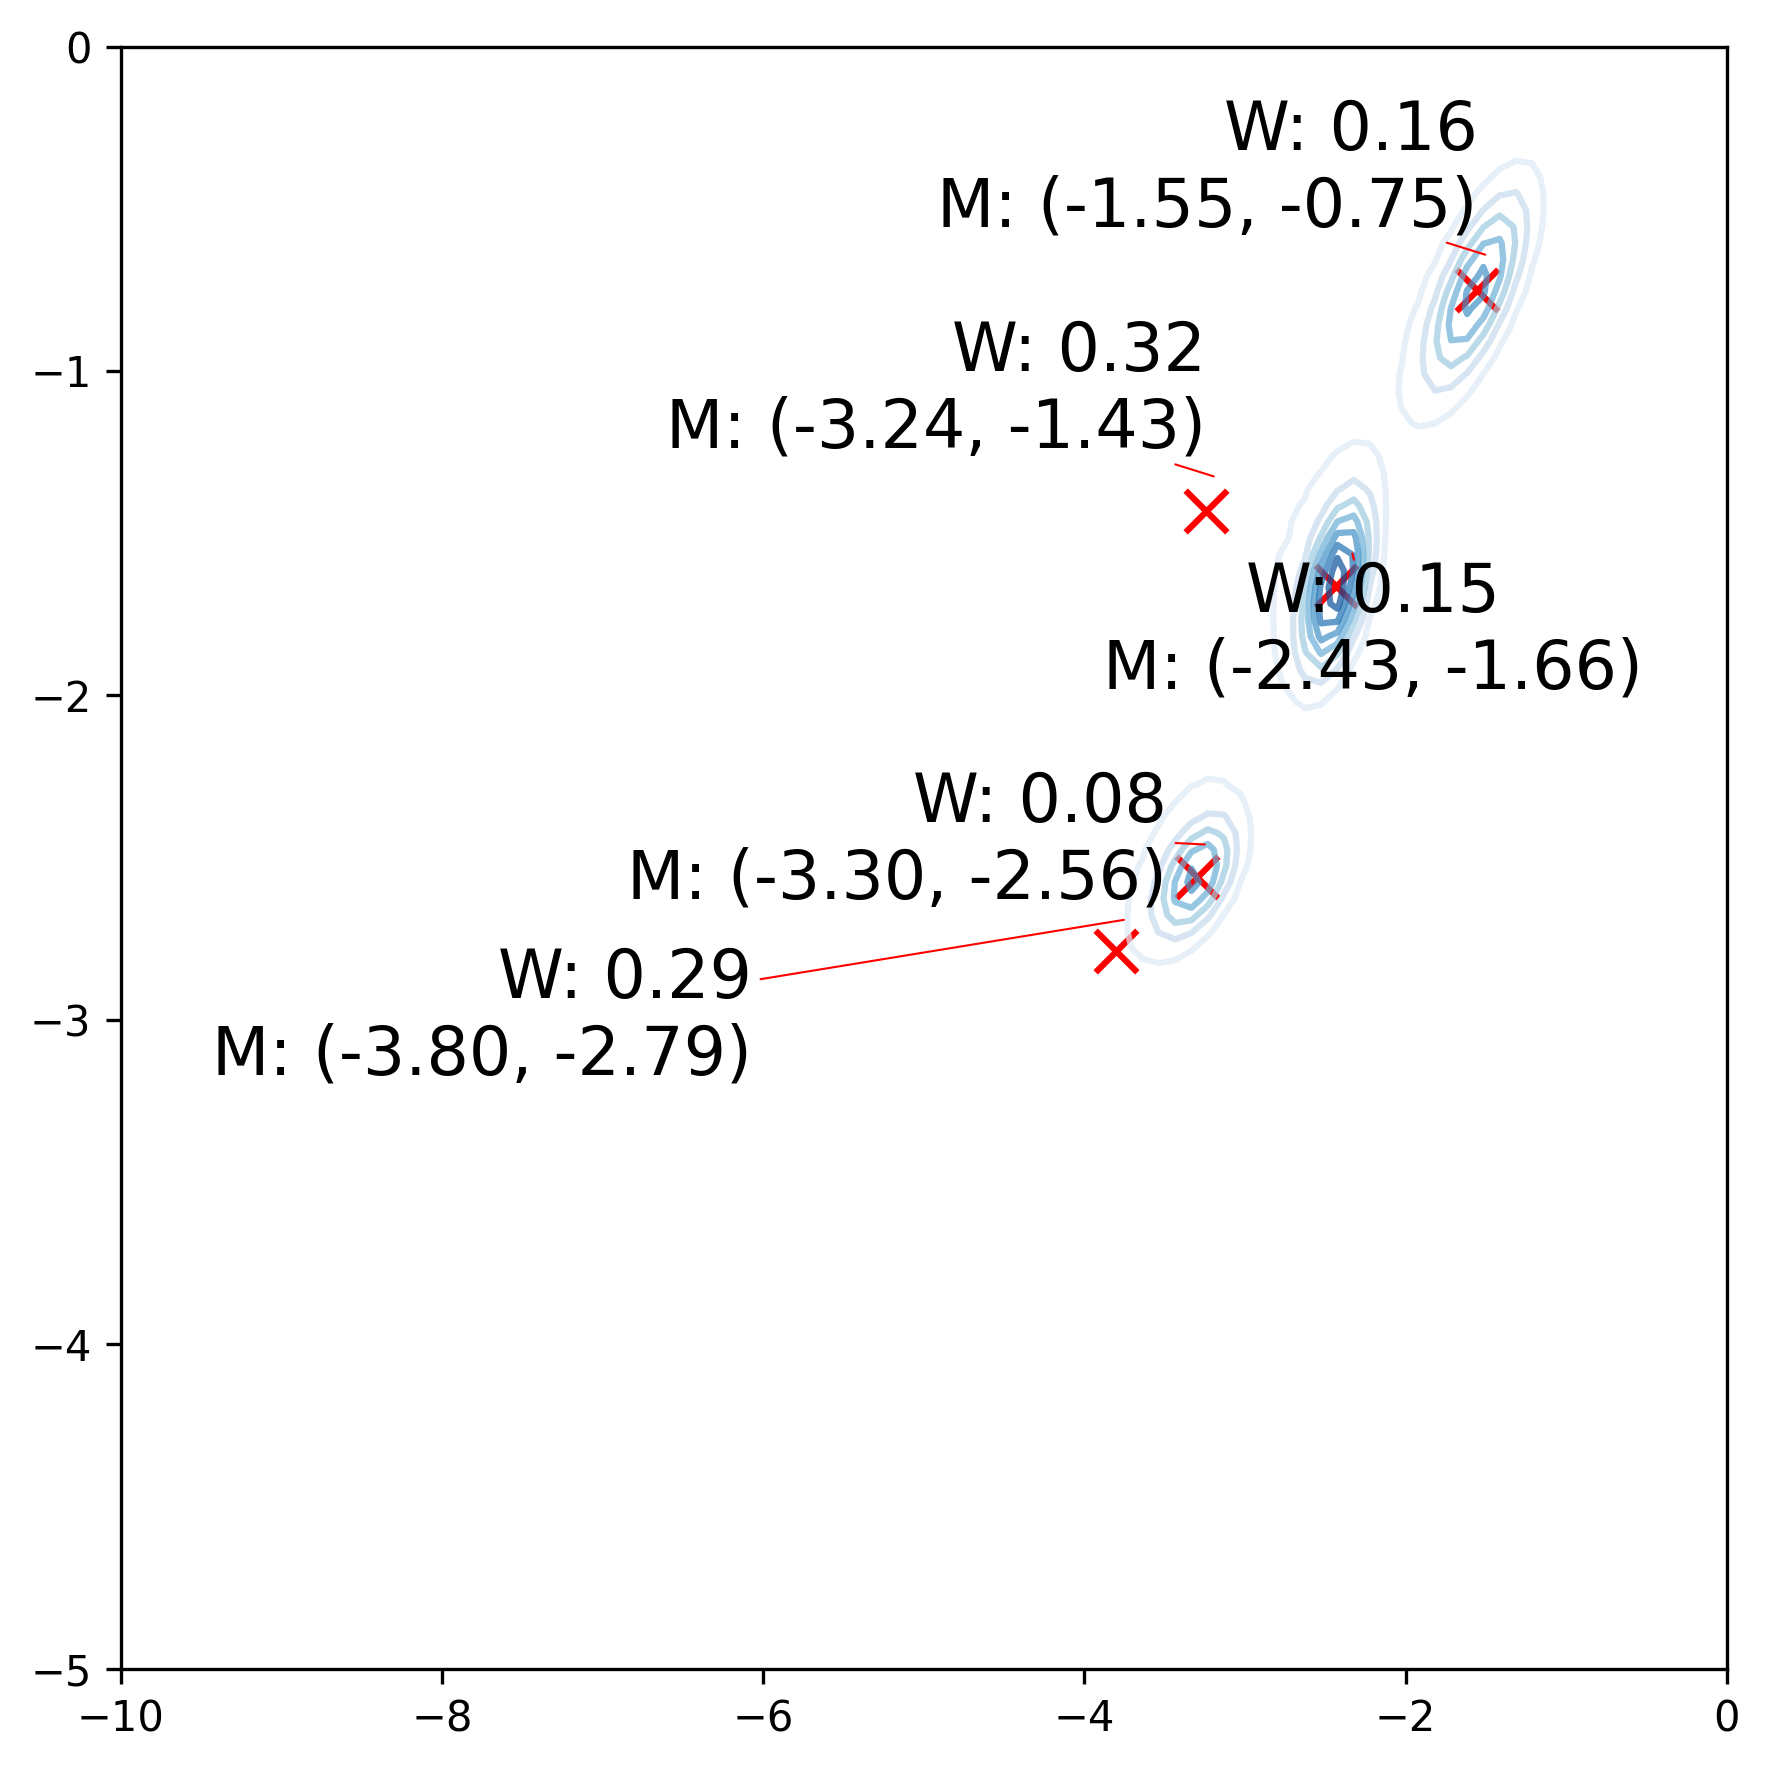

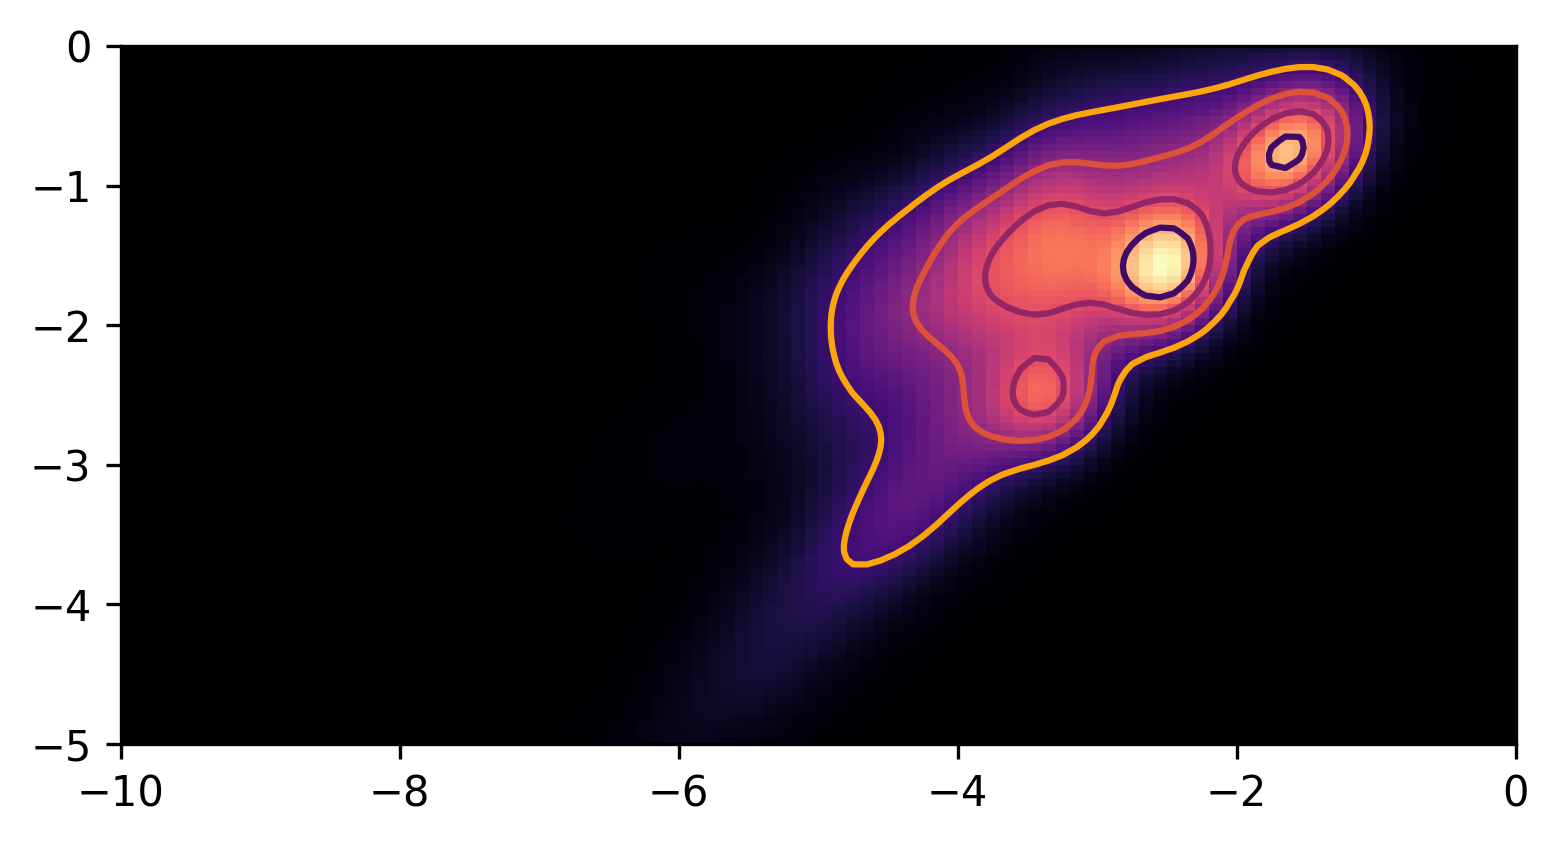

phase 2 model complete


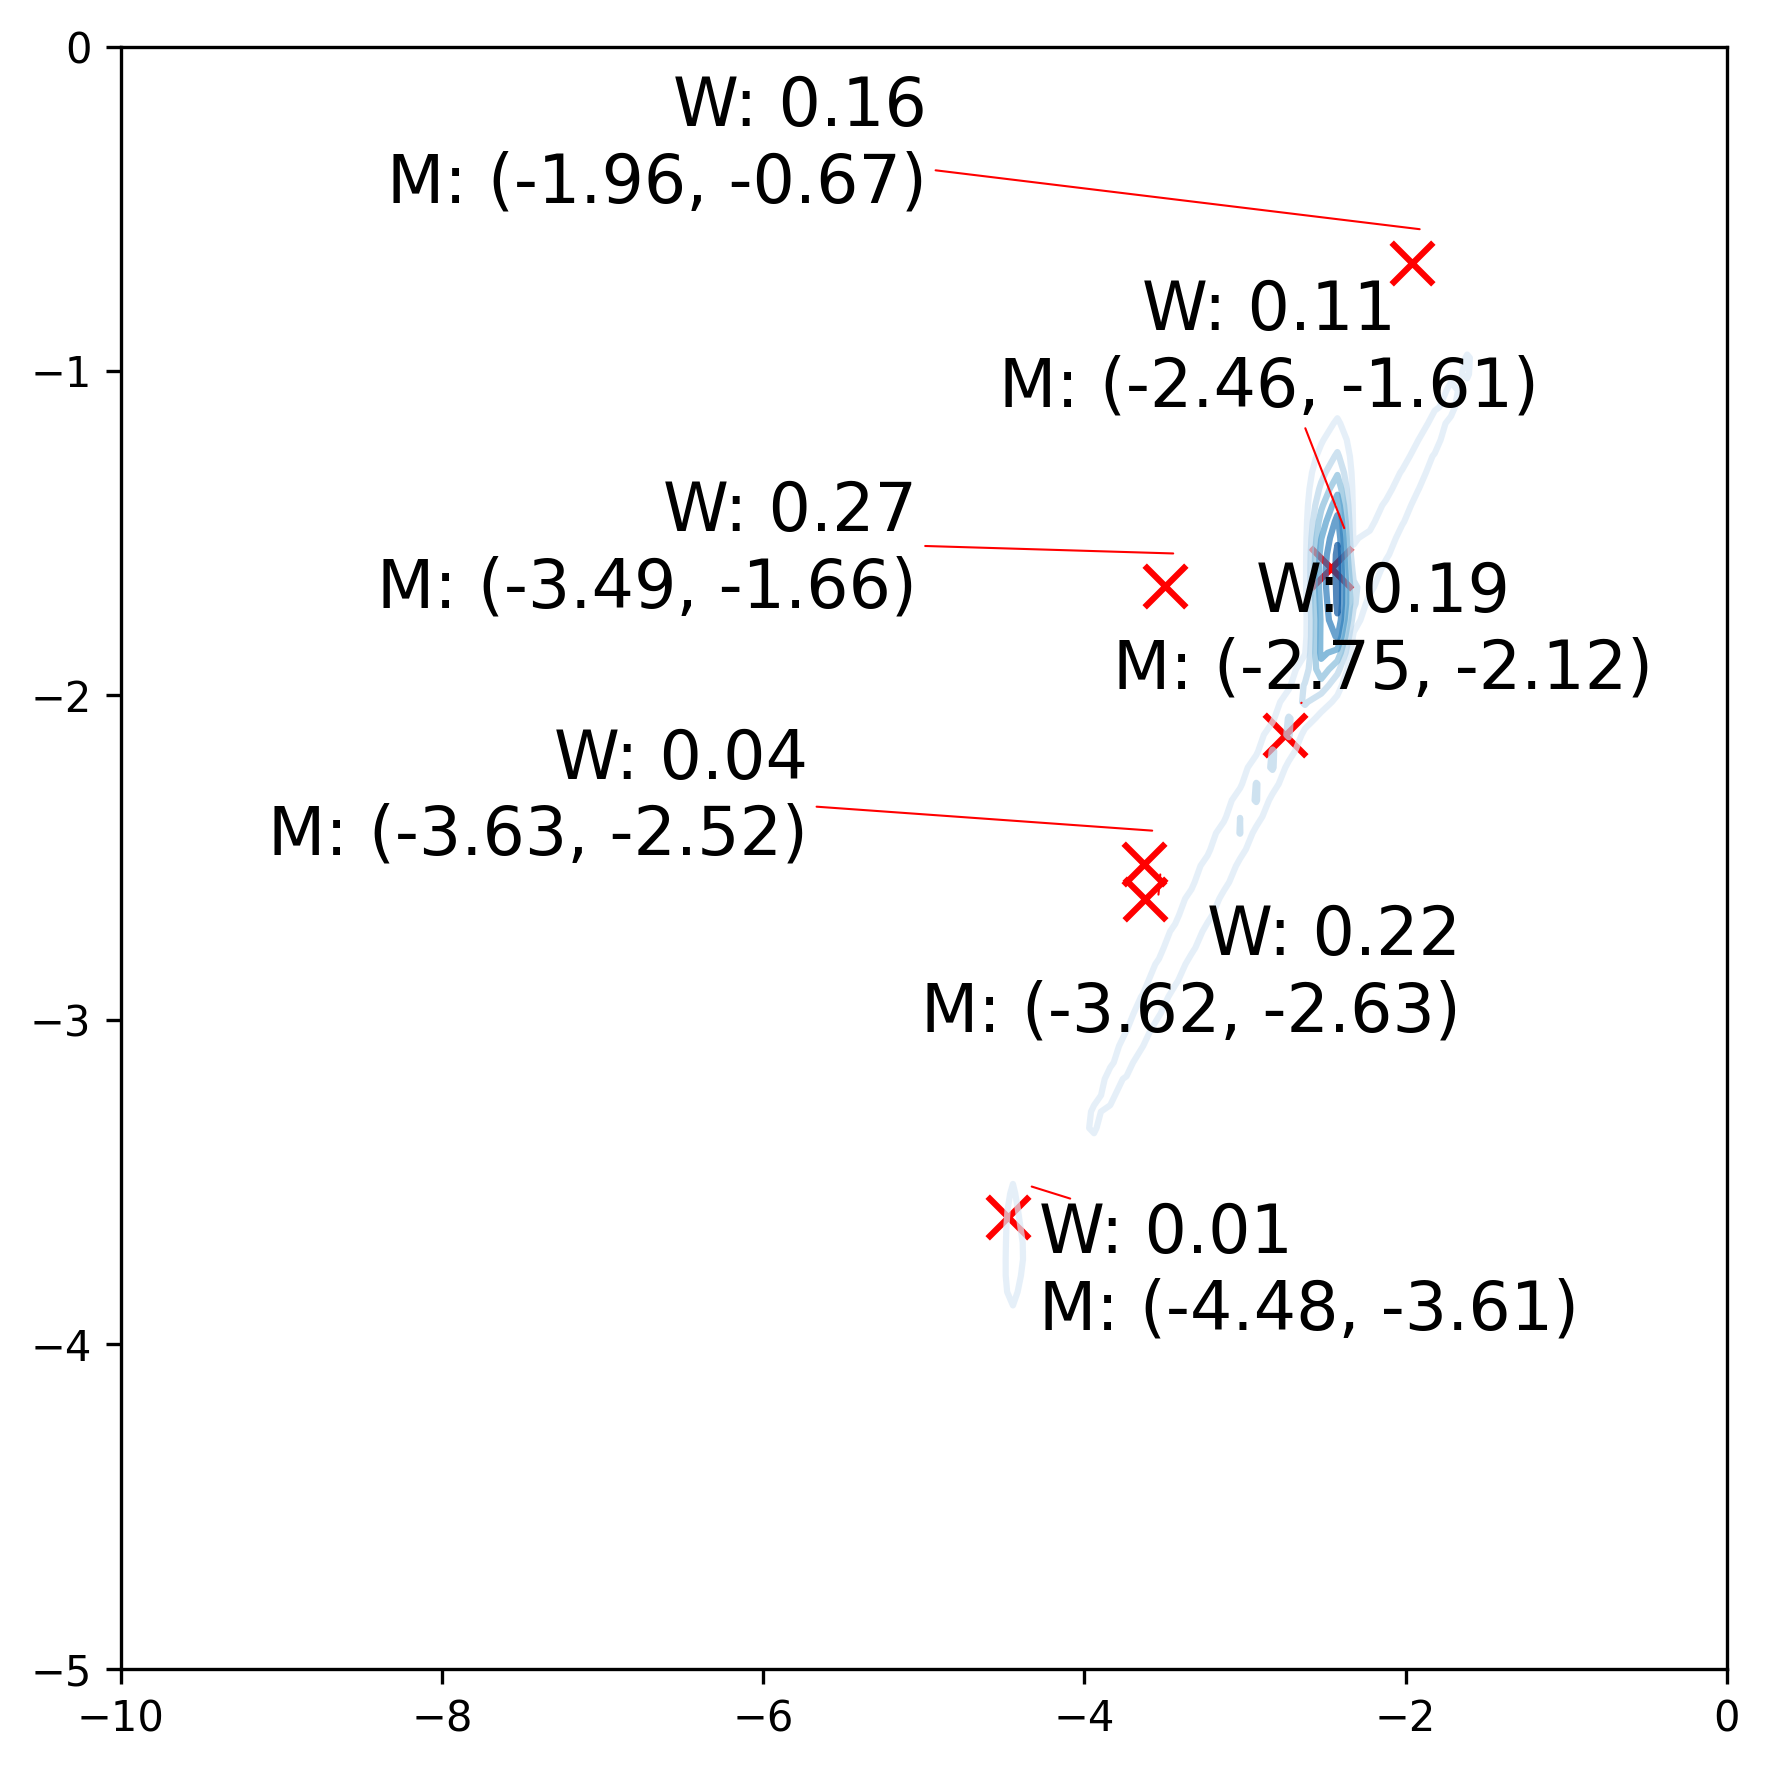

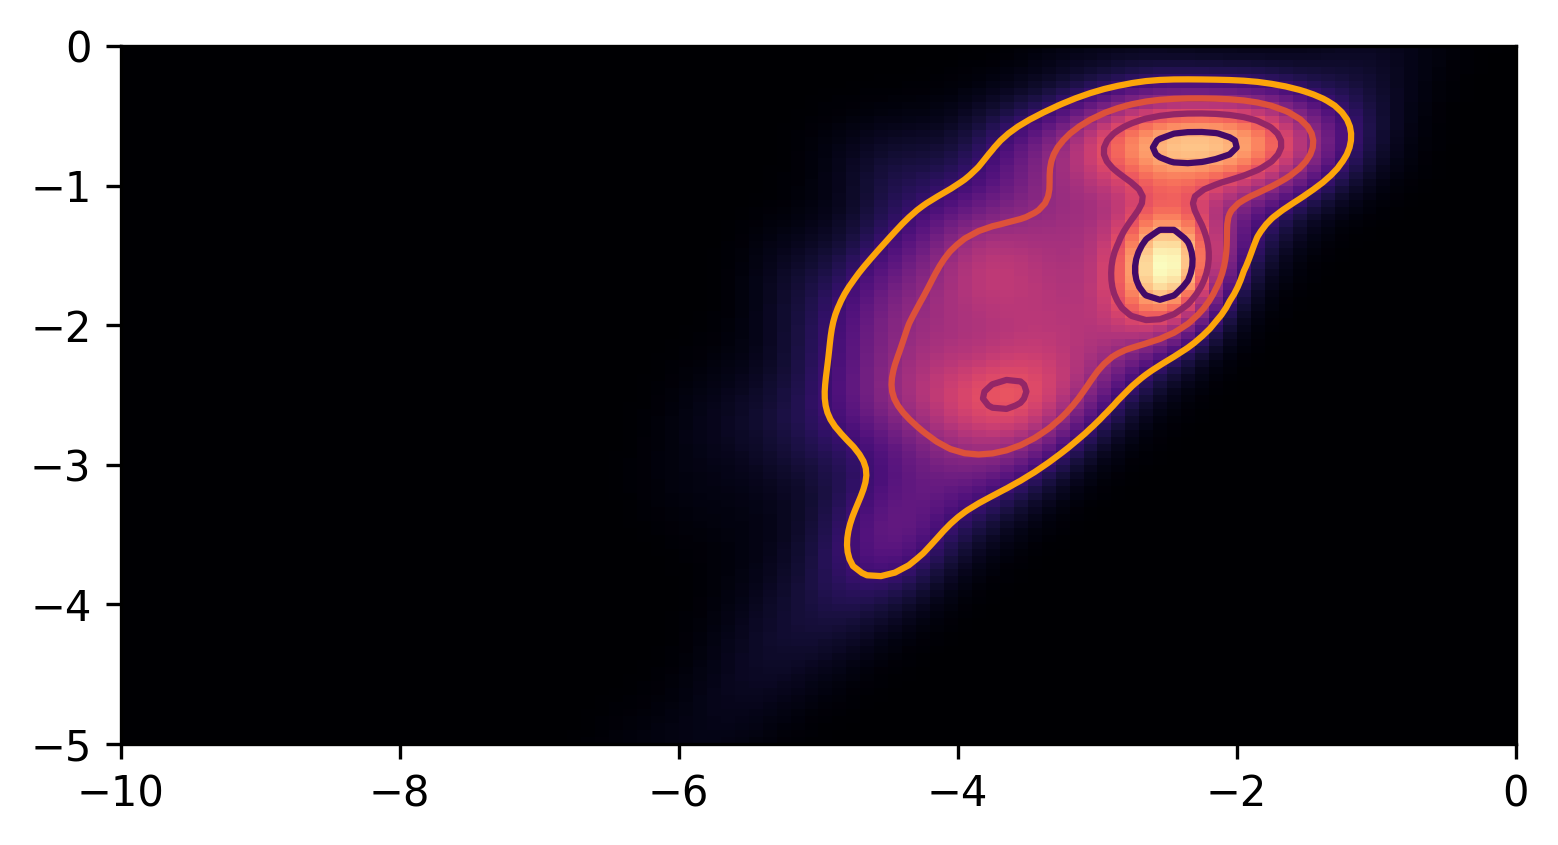

In [14]:
plot_func("ph1_sw", save=True)

phase 0 model complete


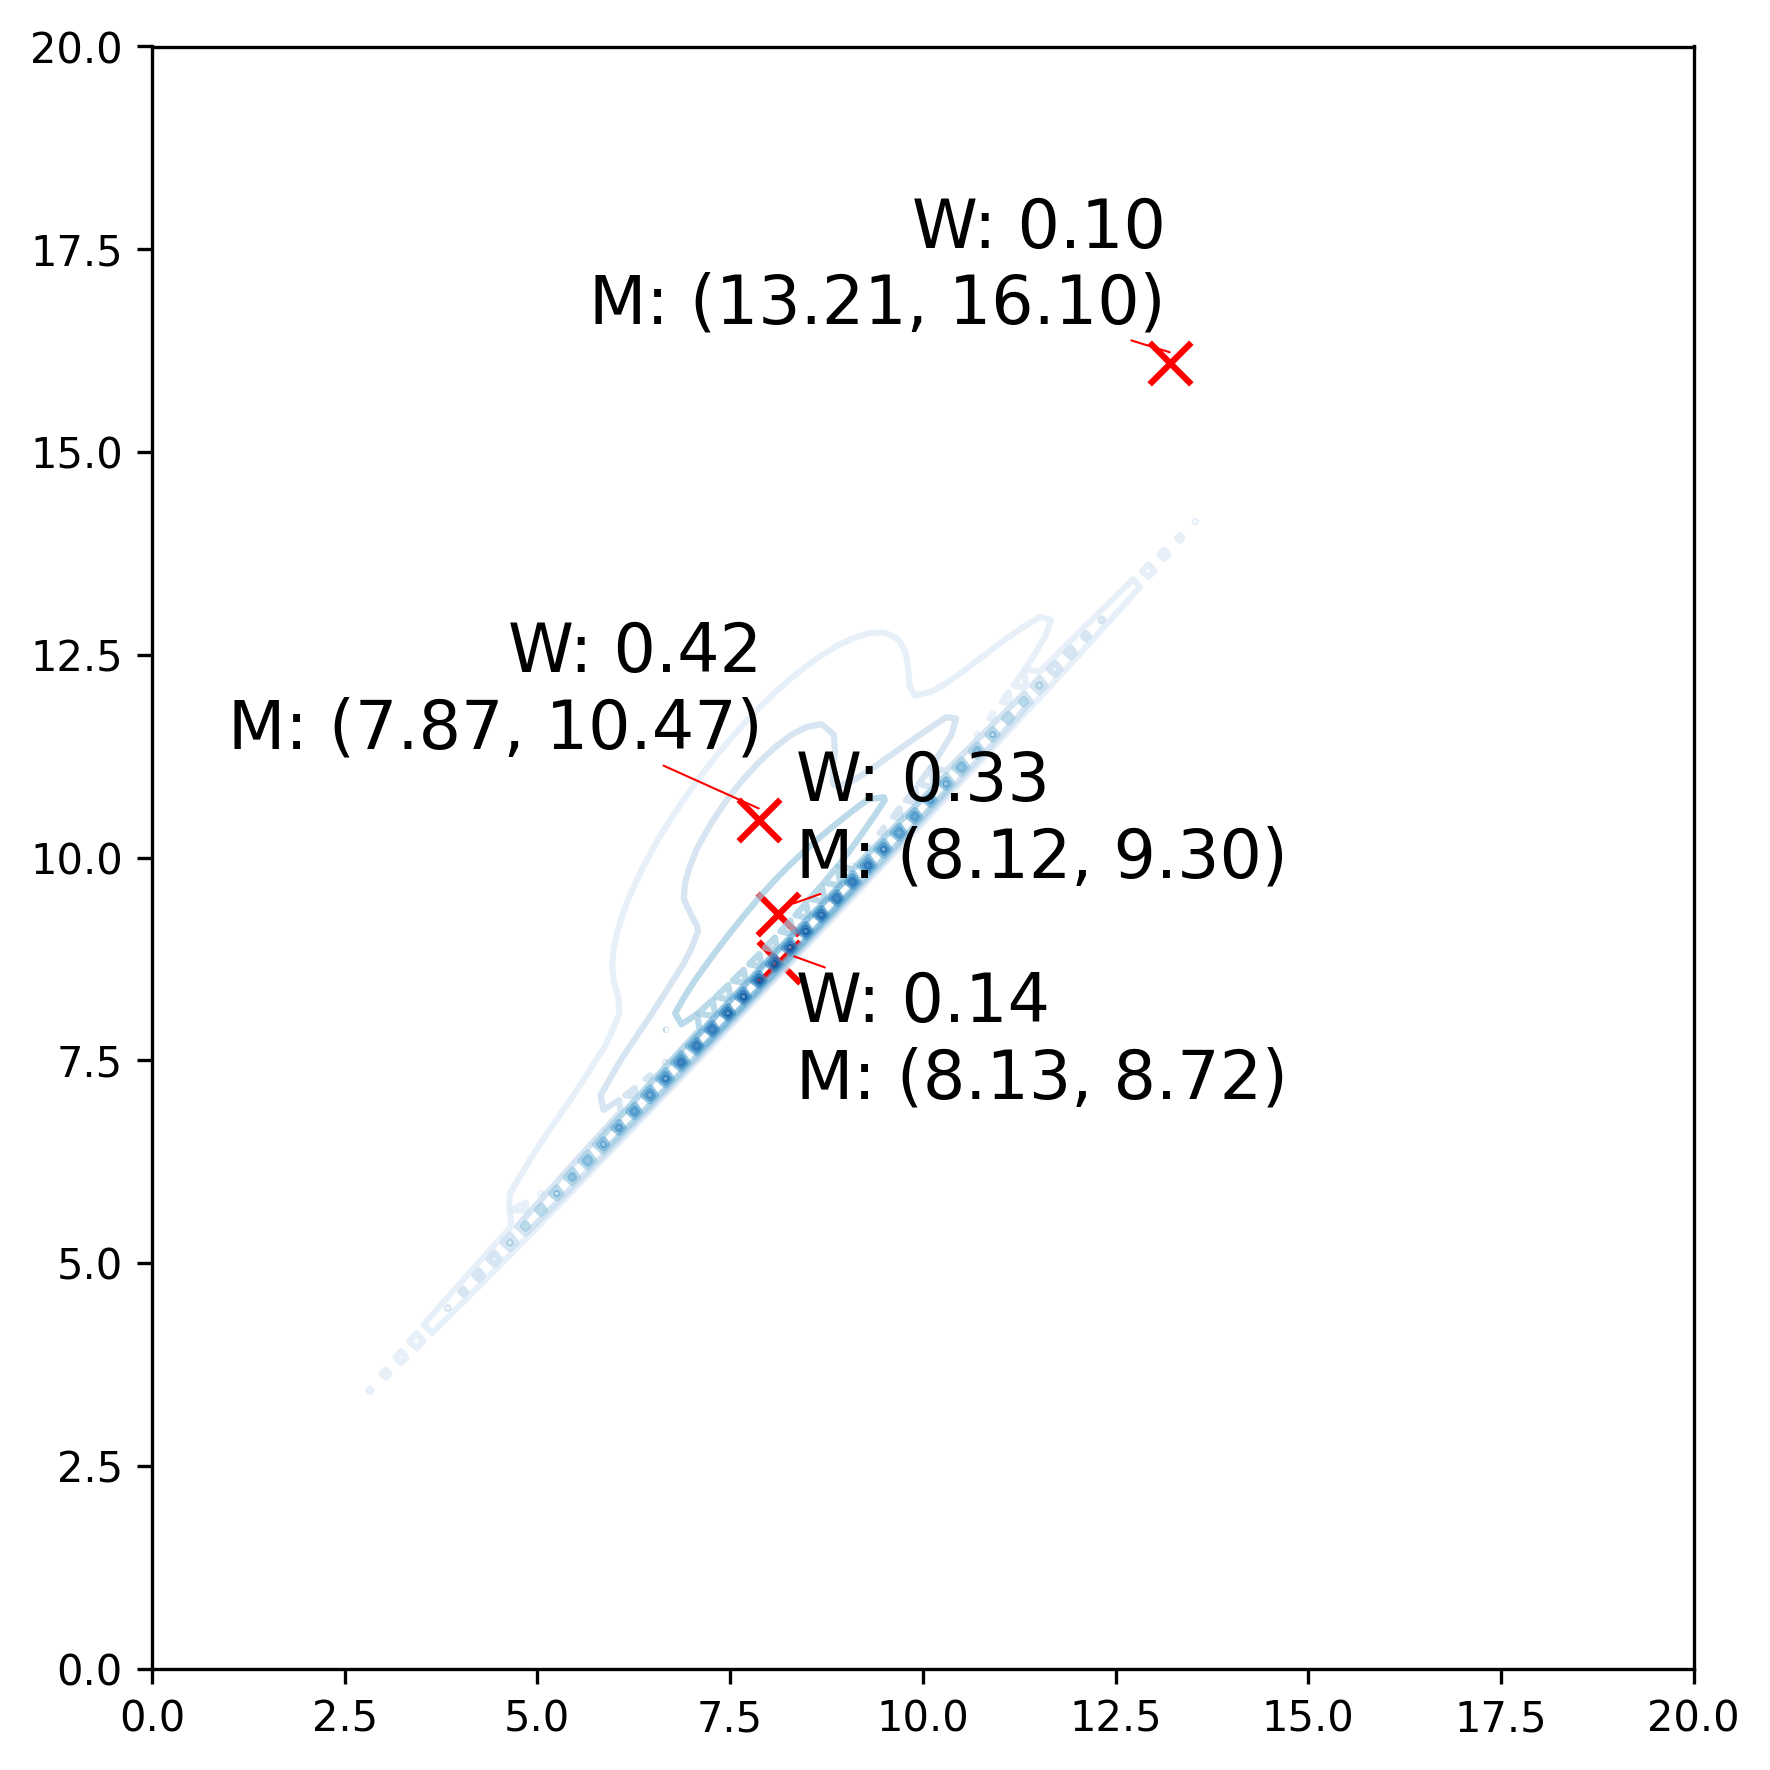

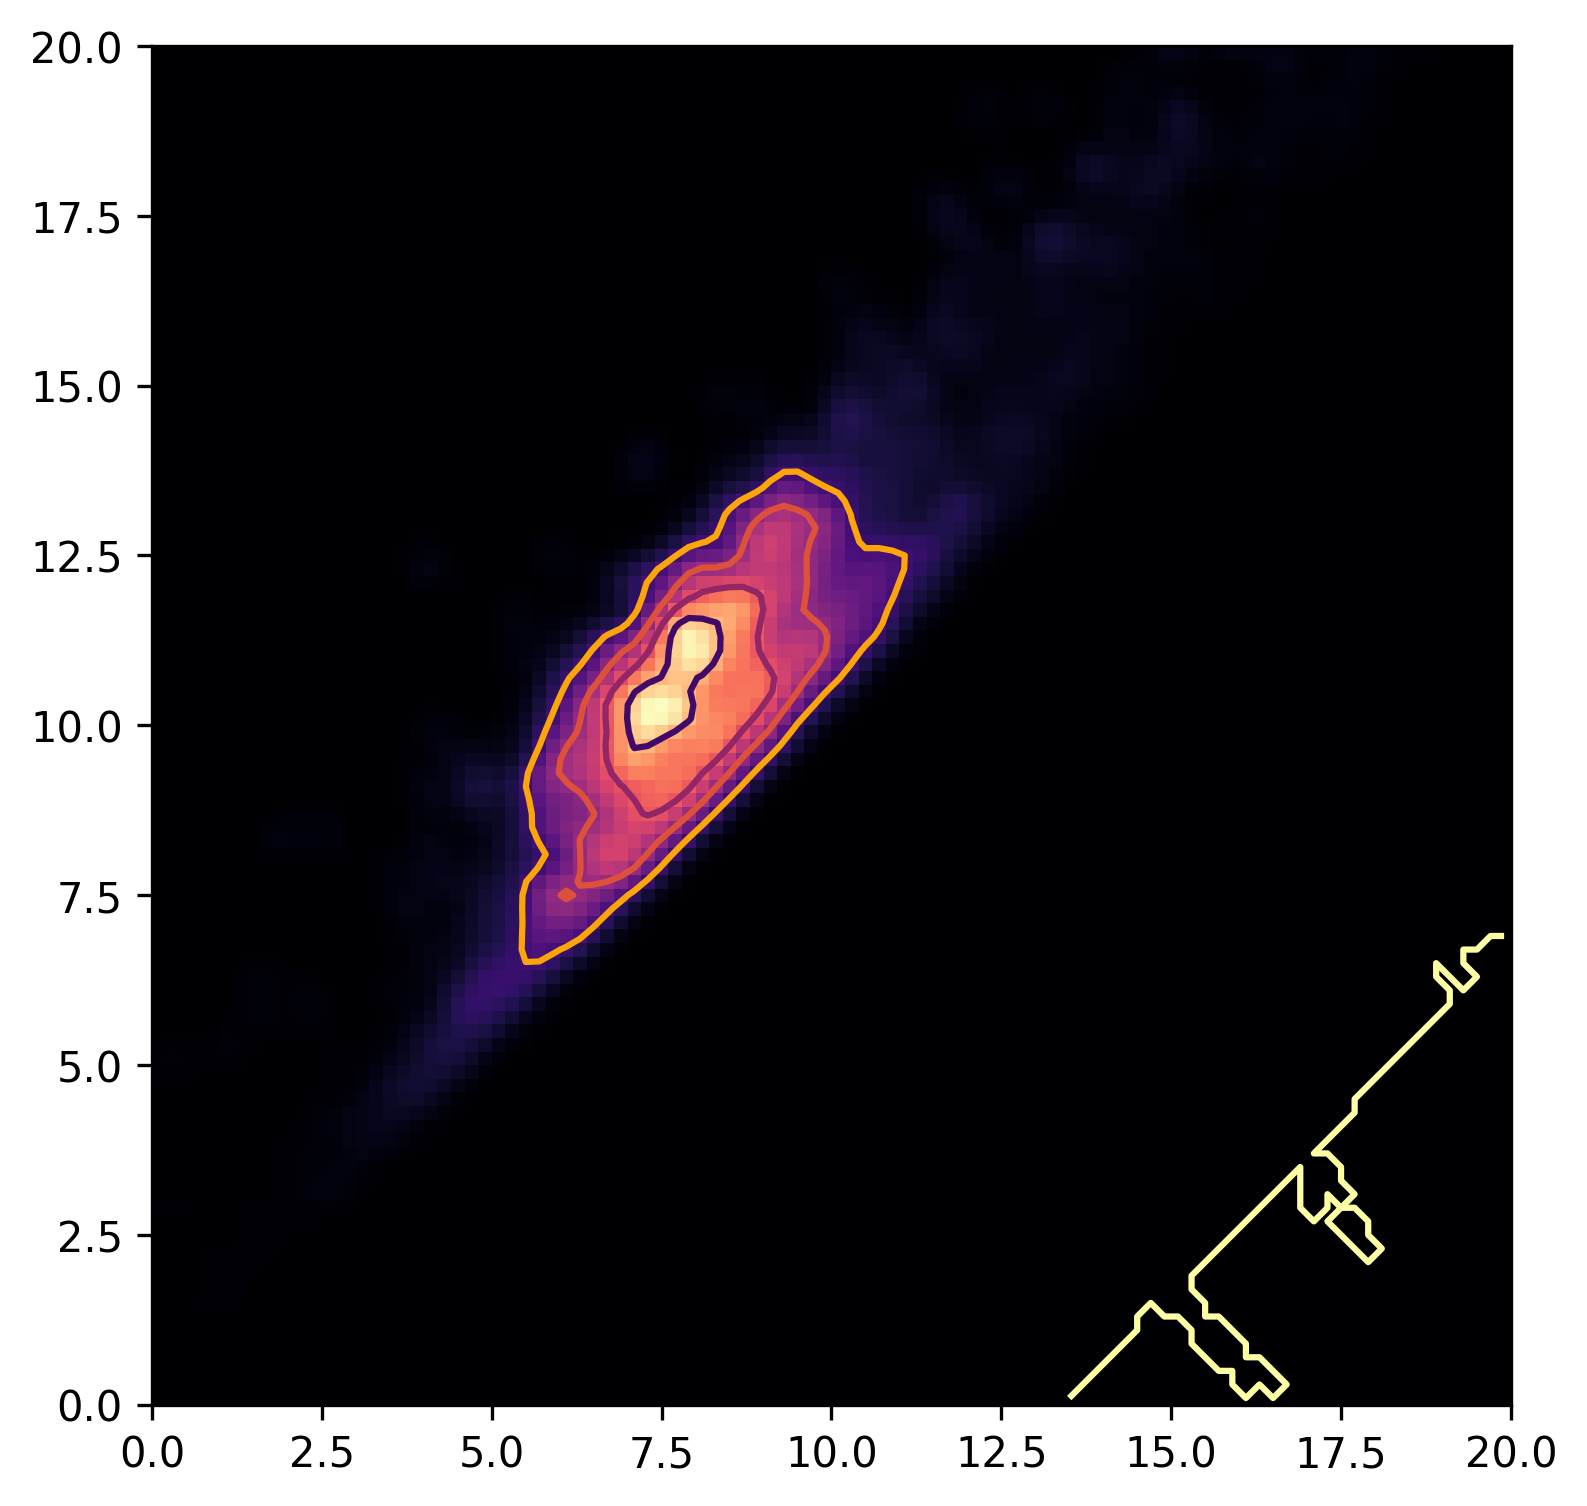

phase 1 model complete


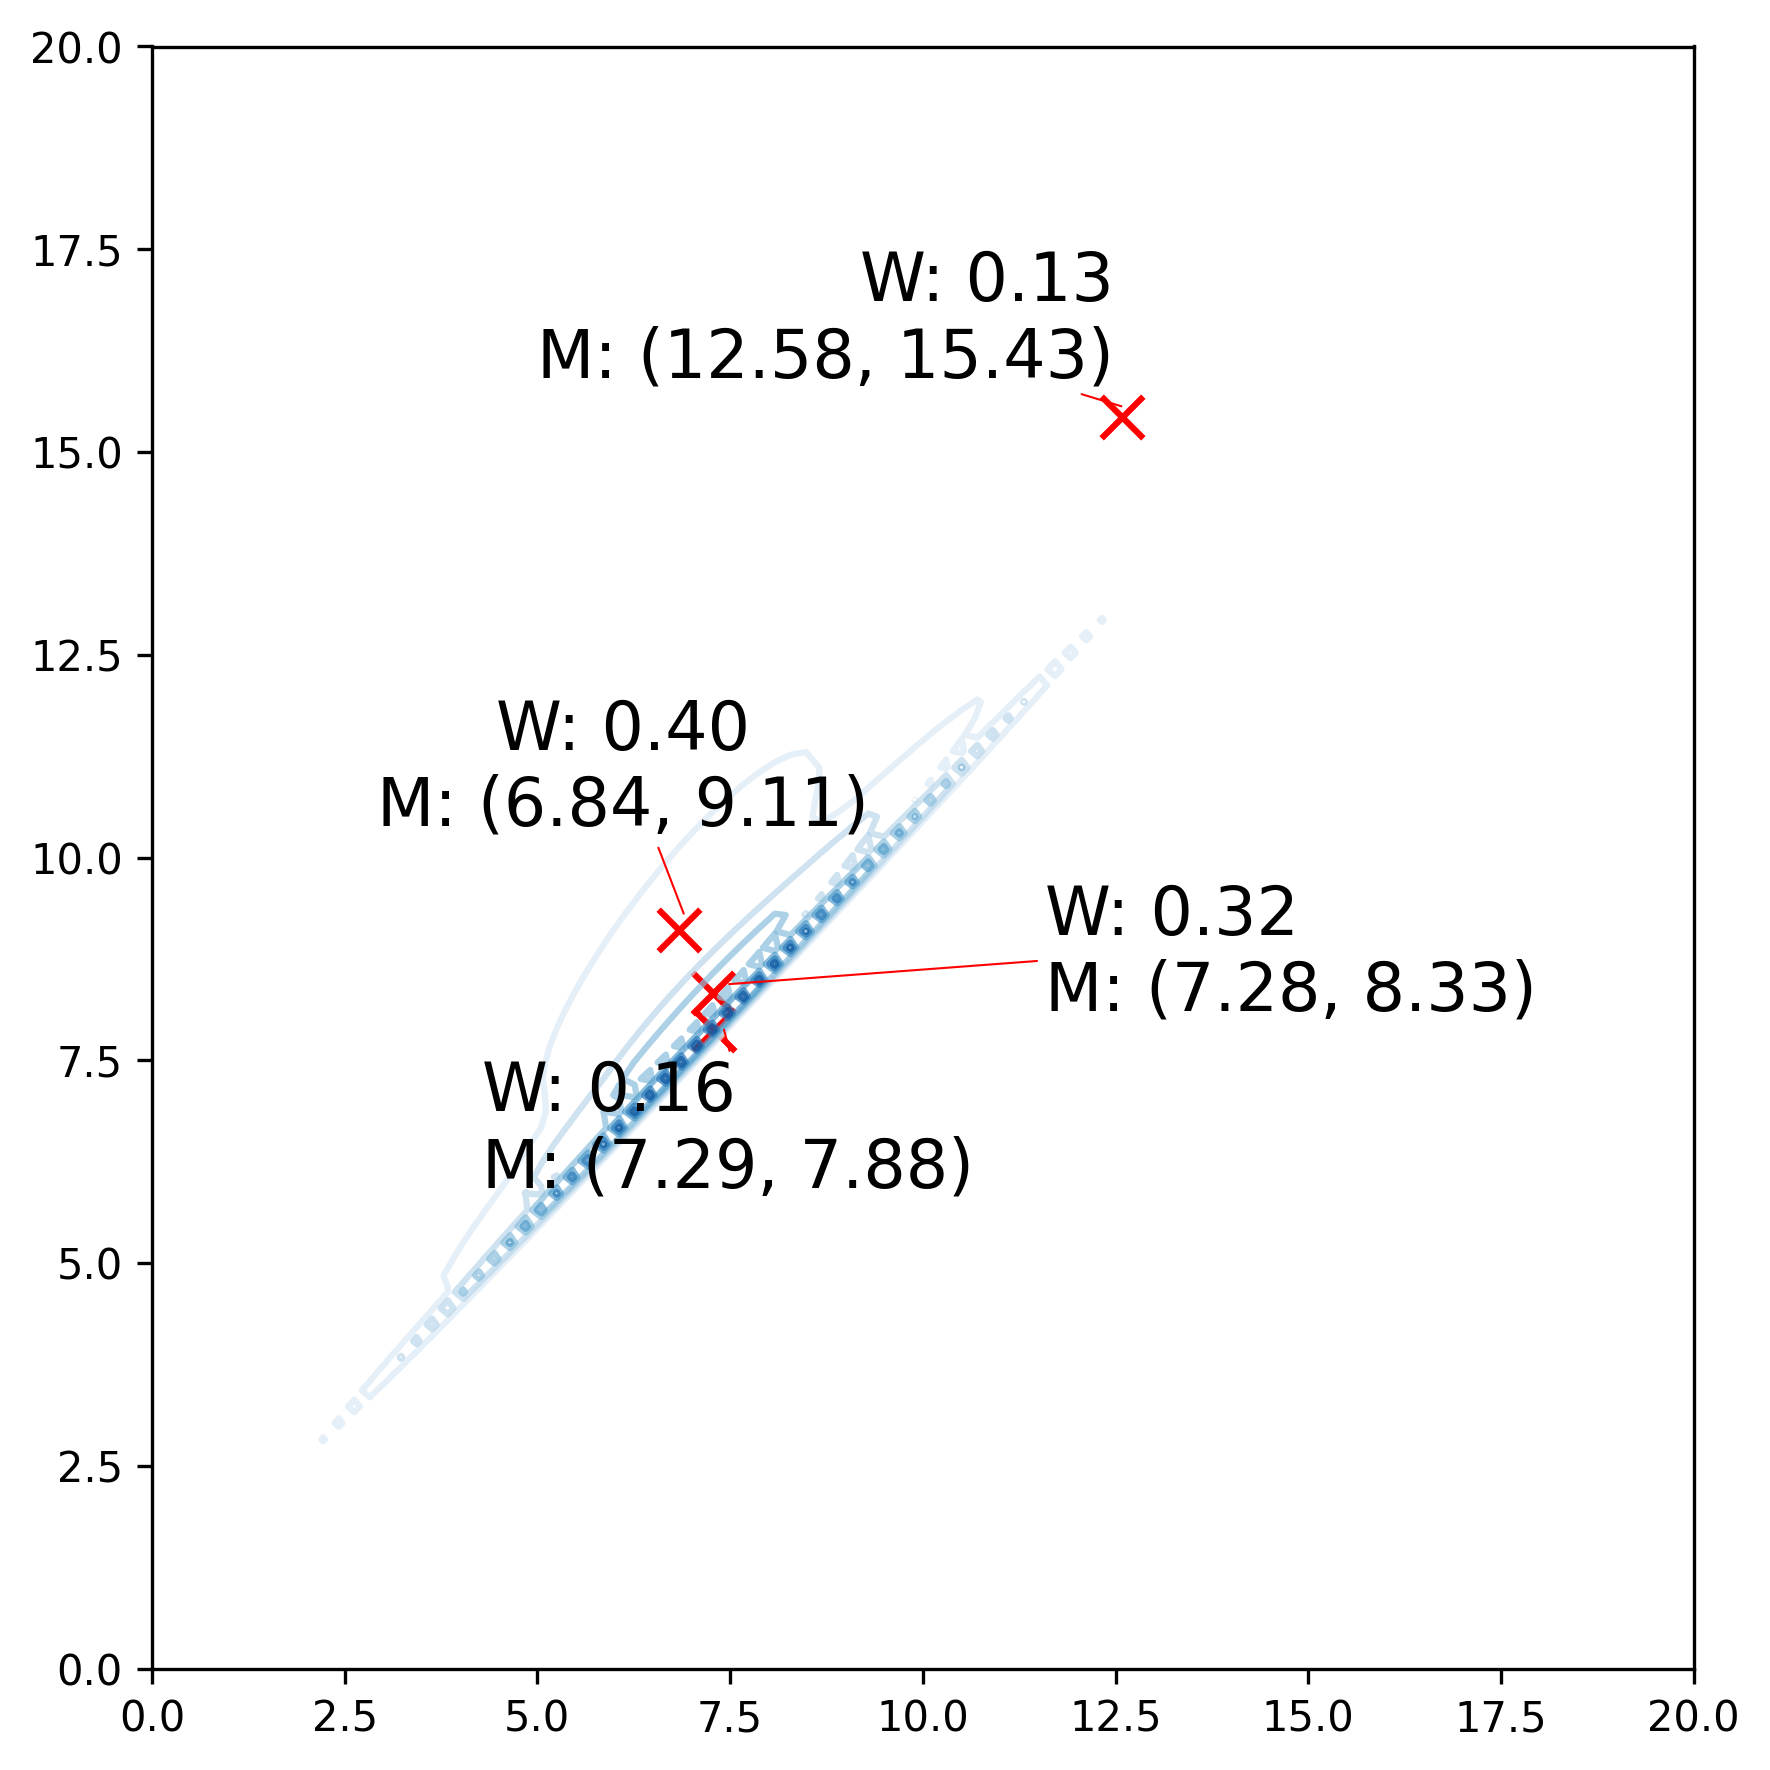

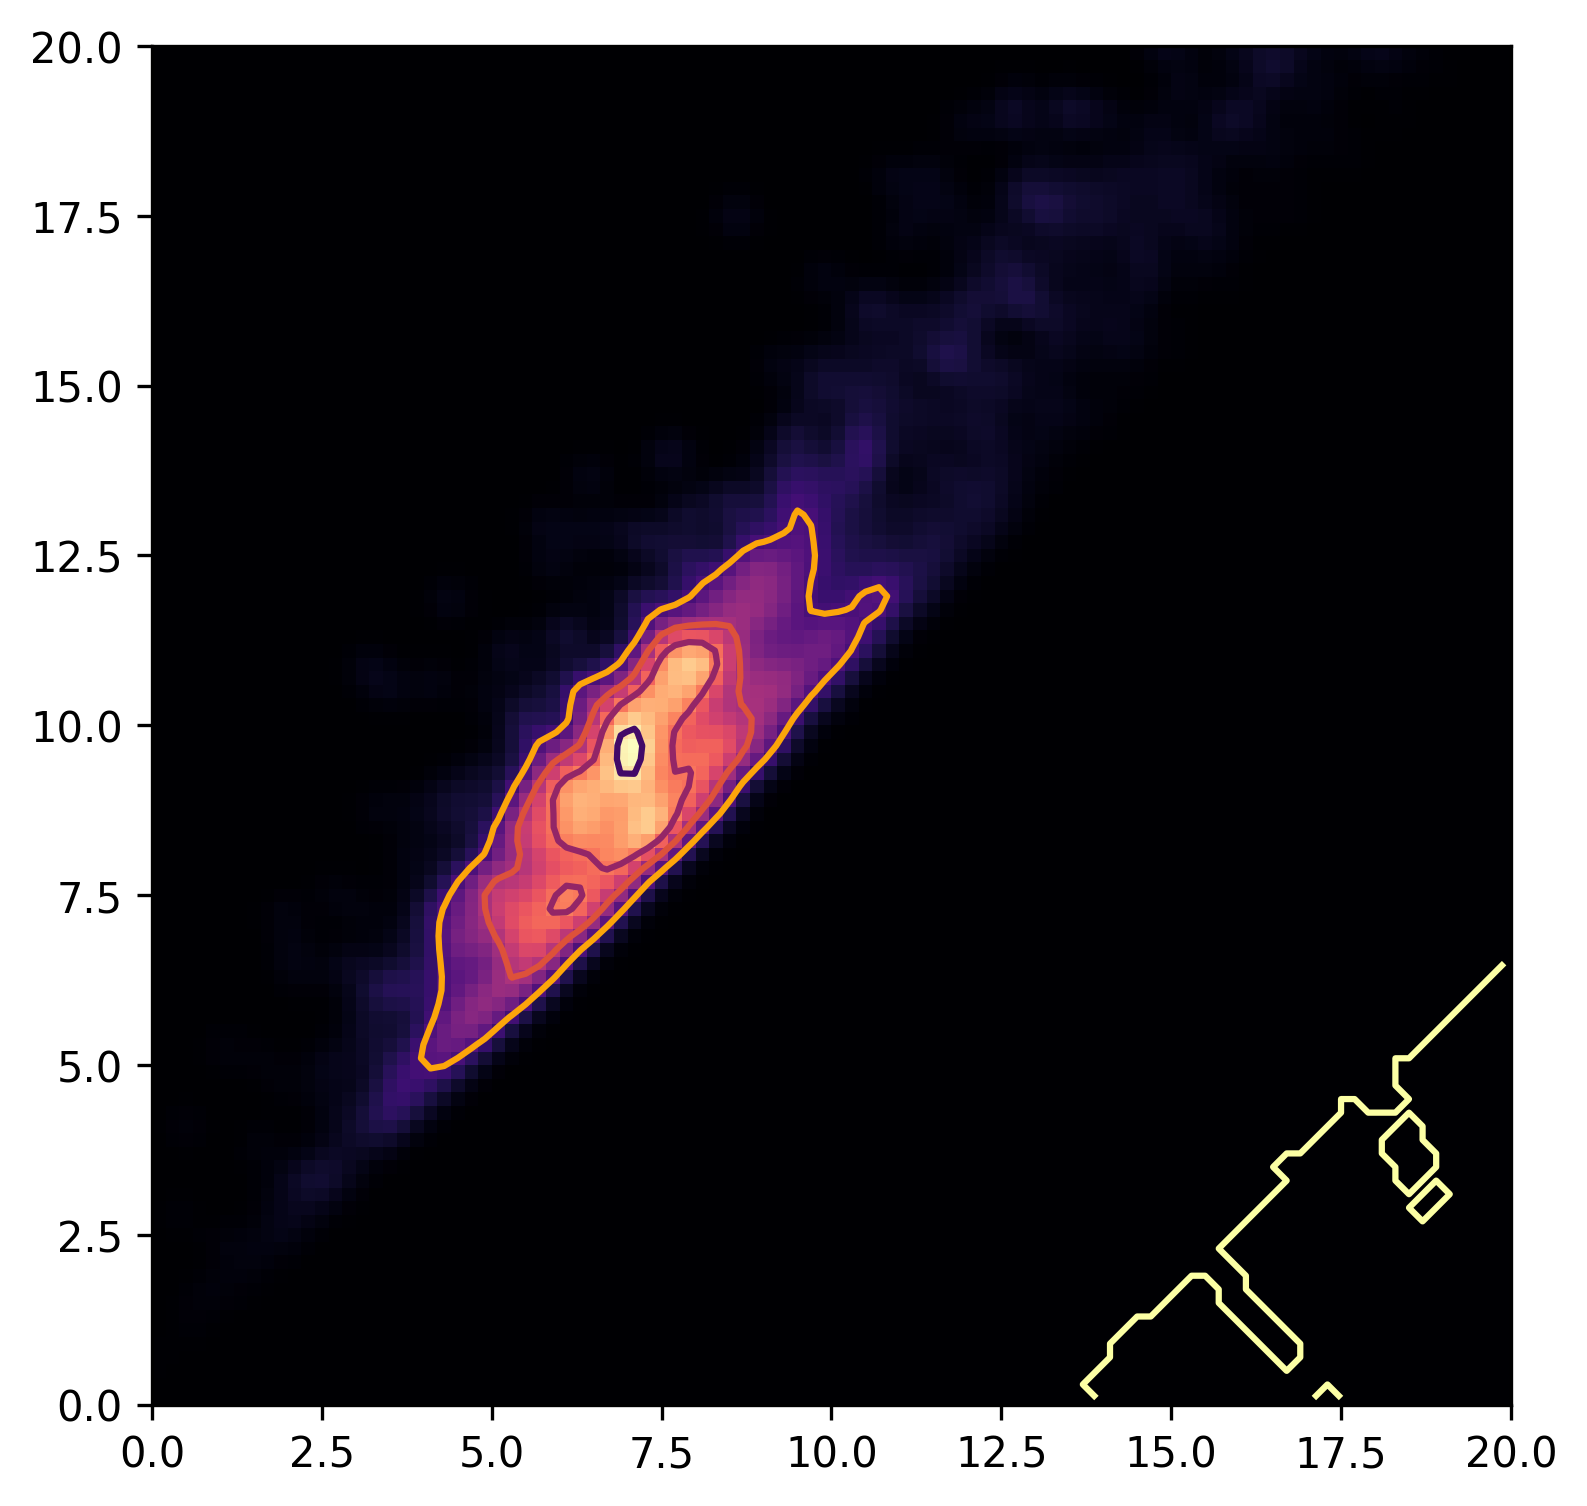

phase 2 model complete


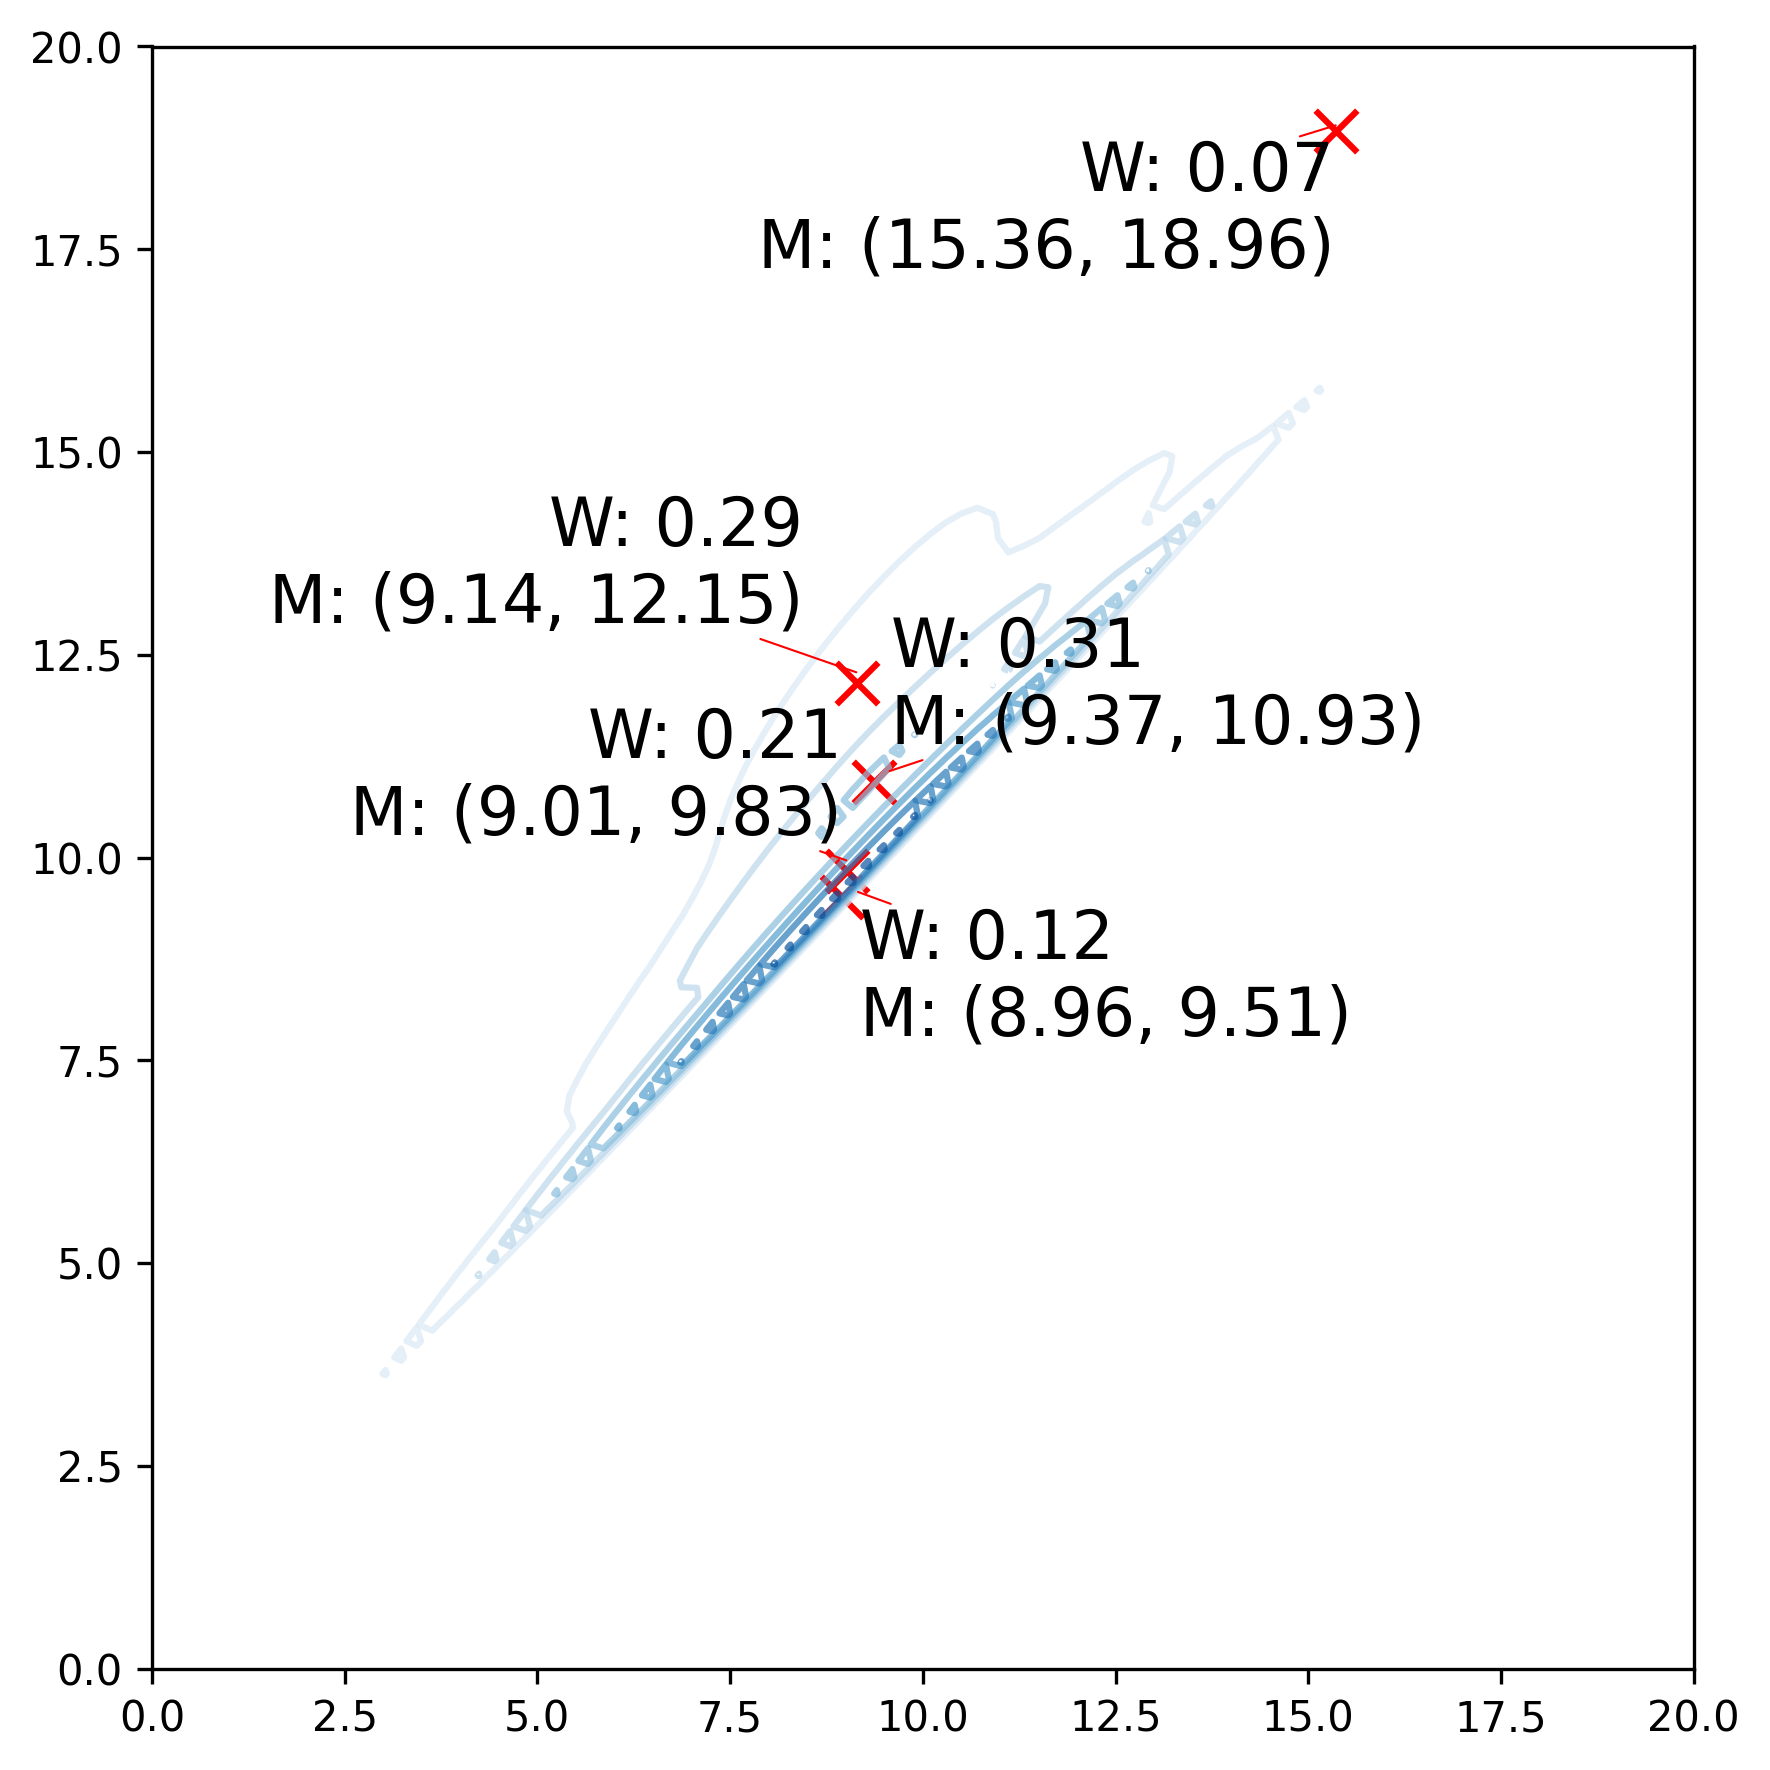

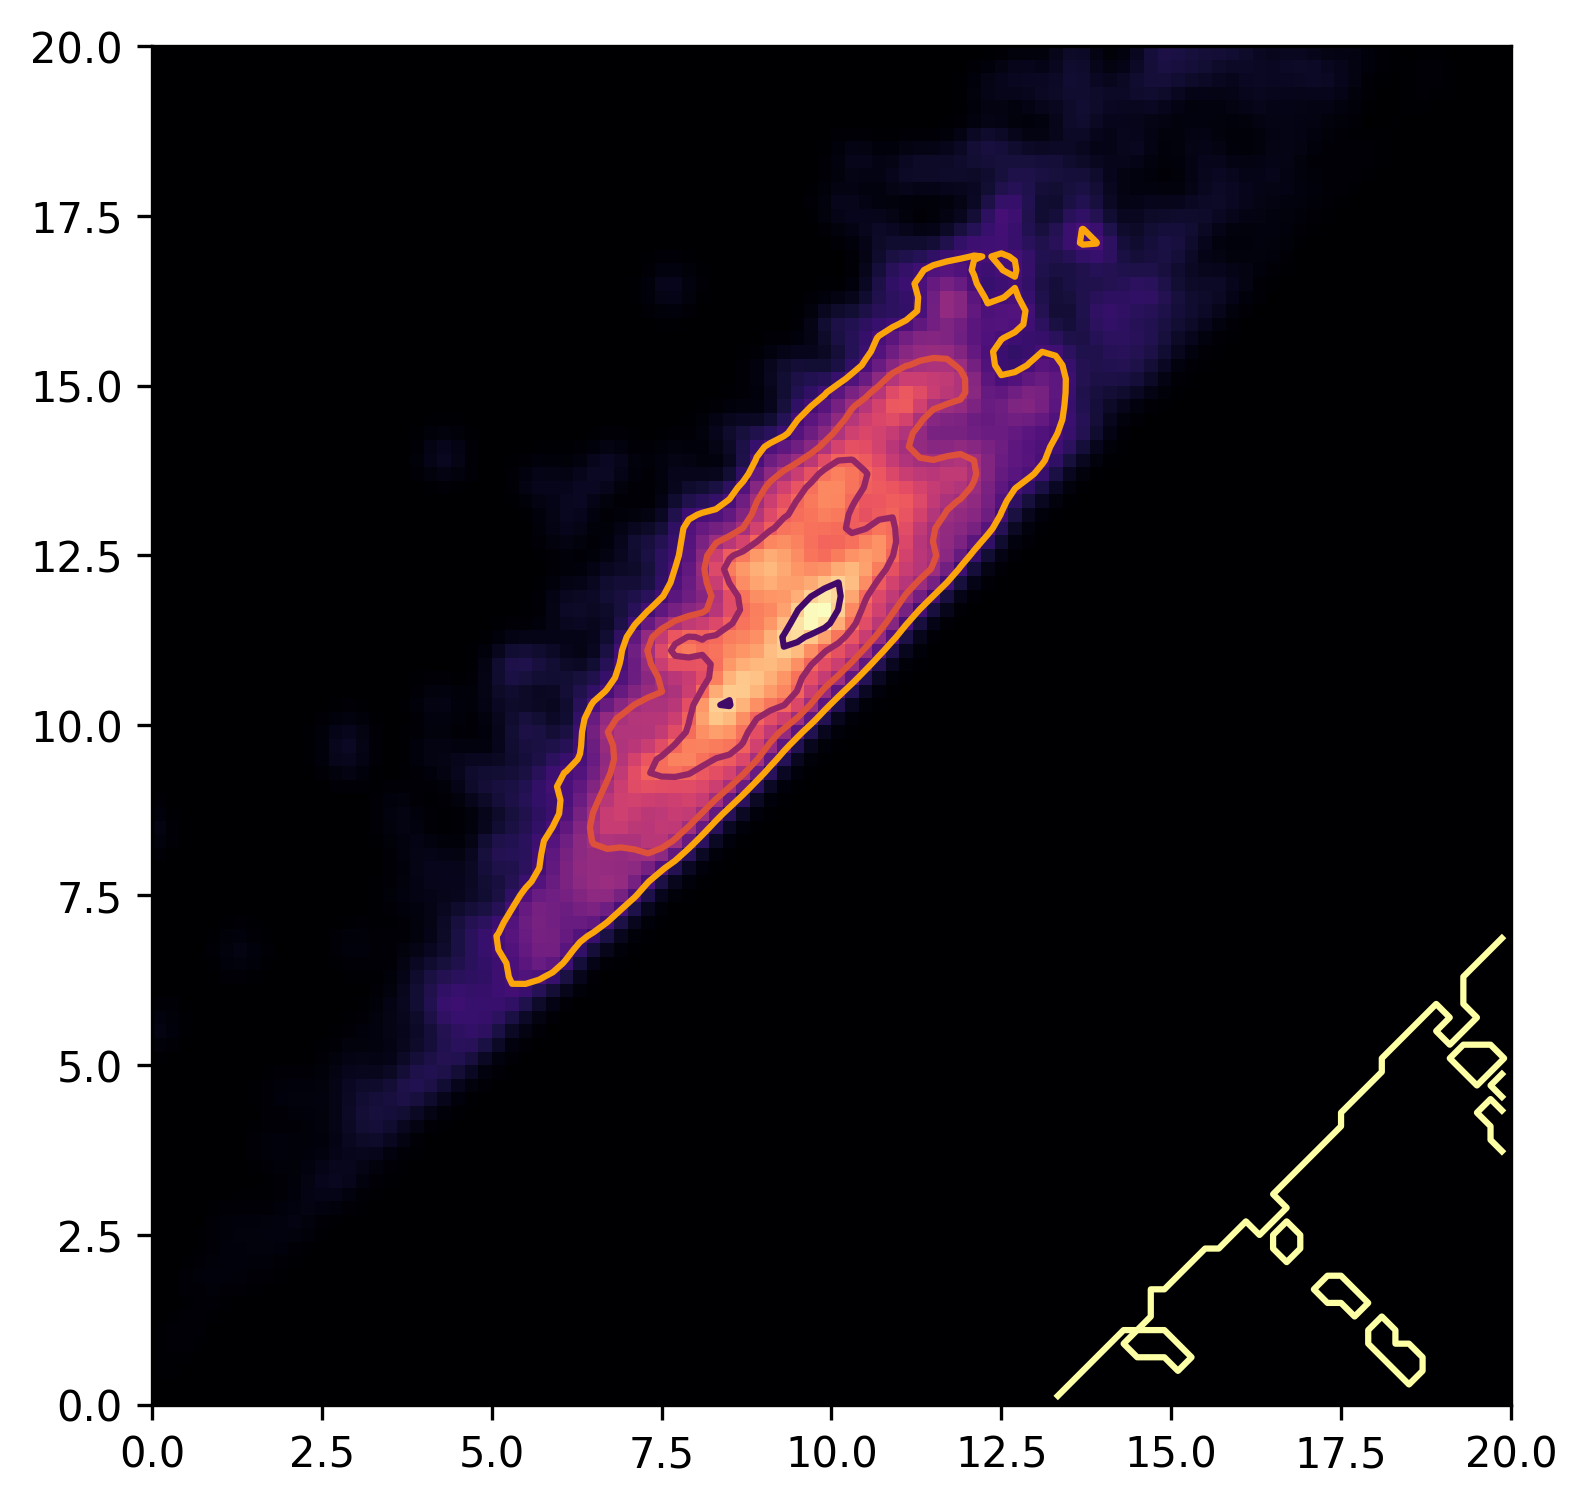

In [15]:
plot_func("ph2_ne", save=True)